# Etap A na posiedzeniach plenarnych: większa próba

**Cel.** Pomiar etapu A (czy wypowiedź zawiera **twierdzenie naukowe**) na próbie wypowiedzi z posiedzeń plenarnych,
130 wypowiedzi na rok w latach 2015–2026. Hipoteza z suplementu karty eksploracji dotyczy wypowiedzi plenarnych.

**Porównania w czasie.** Główne porównanie to okna A (17.04.2022–16.07.2023) i B (13.11.2023–17.02.2025),
krócej przed i po premierze ChatGPT (30.11.2022) oraz trzy okresy pierwotnej hipotezy H1 (przed COVID / COVID / po ChatGPT).
Porównujemy trzy grupy mówców: wszystkich, samych posłów oraz posłów PiS
i Konfederacji (grupa ze slajdu z hipotezą).

**Status wyników.** Mierzymy tylko obecność twierdzeń naukowych (etap A). Tego, czy twierdzenia są zgodne z konsensusem
(etap B), w tym notatniku nie badamy. Nie ma ręcznie oznaczonych danych odniesienia, więc błąd klasyfikatora jest nieznany,
a wszystkie liczby są **eksploracyjne**.

> Spis treści: 0. Co zostało zrobione (0.3 kompletność danych) · 1. Przegląd próby · 2. Lejek detekcji ·
> 3. Agregacja po wypowiedzi · 4. Tematy (4.5 skład tematów w czasie, 4.6 klimat) · 5. Czas (5.1 rocznie i kwartalnie,
> 5.4–5.7 okna A i B, 5.8 ChatGPT, 5.9 COVID, 5.10 kampanie) · 6. Kto mówi · 7. Słowniki a LLM · 8. Atrybucja ·
> 9. Źródła błędu · 10. Dalszy plan · 11. Podsumowanie

## 0. Co zostało zrobione

### 0.1 Pipeline (tylko wykonane kroki)

```
API Sejmu: posiedzenia plenarne (kadencje VIII–X)                                 src/fetch_sejm.py
   │
   ▼
korpus wypowiedzi: czyszczenie tekstu, rola mówcy, blok, flaga `merytoryczna`      src/build_corpus.py
   │  (bez prowadzącego obrady, ≥ 40 słów)
   ▼
filtr regex: ≥ 1 trafienie słownika tematu, `nauka` lub `sceptycyzm`              src/amc/topics.py, sampling.prefilter
   │
   ▼
próba warstwowa: 130 wypowiedzi plenarnych / rok 2015–2026, waga = N_rok / n_rok   src/classify.py --source rok --n 130 --plenarne
   │
   ▼
LLM, krok 1 (prompts/etap_a_v2.md): do 16 zdań-kandydatów na wypowiedź; dla każdego
   cytat · twierdzenie (parafraza samodzielna) · rodzaj (naukowe / statystyka / prawo / budżet / polityka / opinia / inne)
   · temat (8 słowników + inny_naukowy + brak) · atrybucja (własne / cytat z aprobatą / cytat w polemice)
   │
   ▼
LLM, krok 2 (prompts/weryfikacja_v1.md): każdy kandydat „naukowe” oceniany osobno, razem z fragmentem wypowiedzi
   (zdanie z cytatem i po jednym zdaniu przed i po) → tak / nie
   │
   ▼
twierdzenia = kandydaci potwierdzeni w kroku 2 (odrzuceni zostają w danych do analizy błędów)
   │
   ▼
ten notatnik: duplikaty cytatów usunięte, metadane z korpusu, estymacja ważona       src/amc/llm_results.py
```

**Model:** Bielik 11B v3.0 Instruct (kwantyzacja Q4_K_M), lokalnie przez Ollamę na RTX 5060 Ti 16 GB; temperatura 0, kontekst
16 384 tokeny, do 16 kandydatów na wypowiedź, wyjście wymuszone schematem JSON, wypowiedzi > 2500 słów ucinane. Cała próba przeszła
jeden przebieg z tymi ustawieniami.

**Czego jeszcze nie ma:** etapu B (werdykt względem źródeł), ręcznej anotacji, która pozwoliłaby zmierzyć błąd instrumentu
(rozważamy ją), komisji i porównania z innymi modelami.

In [1]:
import sys, warnings
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_root / "src"))

from amc import corpus, llm, paths, sampling, topics as T, viz, llm_results as R
from amc.text import quote_match
from amc.sampling import PERIOD_BREAKS, PERIODS, WINDOWS
from amc.speakers import BLOKI, INNE
from amc.viz import INK, INK2, MUTED, GRID, AXIS, SURF, ACCENT, ACCENT_LIGHT, SECOND, BLOK_KOLOR, ROLE_KOLOR, SEQ, save, subtitle

viz.setup()
pd.set_option("display.max_colwidth", 200)
PERIODS = list(PERIODS)
PERIOD_LABEL = {"przed_covid": "przed COVID", "covid": "COVID", "po_chatgpt": "po ChatGPT"}
PERIOD_TICK = {"przed_covid": "przed COVID\n(do 23.01.2020)", "covid": "COVID\n(24.01.2020–29.11.2022)",
               "po_chatgpt": "po ChatGPT\n(od 30.11.2022)"}
TOPICS = list(T.TOPICS)
TOPICS_LLM = TOPICS + ["inny_naukowy"]
PCT = plt.FuncFormatter(lambda v, _: f"{v * 100:g}%")
WINDOW_TICK = {"A": "okno A\n(17.04.2022–16.07.2023)", "B": "okno B\n(13.11.2023–17.02.2025)"}
WIN_KOLOR = {"A": "#86b6ef", "B": ACCENT}
CHATGPT = PERIOD_BREAKS[1]
CHATGPT_LABEL = {"przed": "przed ChatGPT", "po": "po ChatGPT"}
RIGHT = ["PiS", "Konfederacja"]
ELECTIONS = [("PE", "2019-05-26"), ("Sejm", "2019-10-13"), ("prezydent", "2020-06-28"),
             ("Sejm", "2023-10-15"), ("PE", "2024-06-09"), ("prezydent", "2025-05-18")]
SUBSETS = {"wszyscy mówcy": INK2, "posłowie": ACCENT, "posłowie PiS i Konfederacji": SECOND}


def fmt_ci(b, scale=100):
    return [f"{p * scale:.1f} [{lo * scale:.1f}; {hi * scale:.1f}]" for p, lo, hi in zip(b["p"], b["lo"], b["hi"])]


def fmt_diff(r):
    est, lo, hi = r
    return f"{100 * est:+.1f} [{100 * lo:+.1f}; {100 * hi:+.1f}]"


def who(d):
    """Bloc for MPs, otherwise the role (rząd / inni)."""
    return pd.Series(np.where(d["rola"] == "poseł", d["blok"], d["rola"]), index=d.index)


def subsets_of(d):
    mp = d["rola"] == "poseł"
    return {"wszyscy mówcy": d, "posłowie": d[mp], "posłowie PiS i Konfederacji": d[mp & d["blok"].isin(RIGHT)]}


def year_x(d):
    return d.year + (d.dayofyear - 1) / 365 - 0.5


def period_lines(ax, label=True):
    for d, lab in zip(PERIOD_BREAKS, ["COVID w Europie", "ChatGPT"]):
        x = year_x(d)
        ax.axvline(x, color=AXIS, ls=":", lw=1)
        if label:
            ax.text(x, 1.0, " " + lab, transform=ax.get_xaxis_transform(), fontsize=8, color=MUTED, va="top")
    for k, (a, b) in WINDOWS.items():
        ax.axvspan(year_x(a), year_x(b), color=GRID, alpha=0.7, lw=0, zorder=0)
        if label:
            ax.text((year_x(a) + year_x(b)) / 2, 0.88, k, transform=ax.get_xaxis_transform(), ha="center", va="top",
                    fontsize=9, fontweight="bold", color=MUTED)


def hbar_ci(ax, b, colors, labels=None, pct=True):
    k = 1 if pct else 100
    p, lo, hi = b["p"] * k, b["lo"] * k, b["hi"] * k
    y = np.arange(len(b))
    ax.barh(y, p, color=colors, height=0.62)
    ax.errorbar(p, y, xerr=[p - lo, hi - p], fmt="none", ecolor=INK2, elinewidth=1, capsize=0)
    for yi, (v, h) in enumerate(zip(p, hi)):
        ax.text(h, yi, f"  {v:.0%}" if pct else f"  {v:.0f}", va="center", fontsize=8, color=INK2)
    ax.set_yticks(y, labels if labels is not None else [""] * len(b))
    ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, hi.max() * 1.25)
    if pct:
        ax.xaxis.set_major_formatter(PCT)


def date_lines(ax, label=True):
    """Windows A/B and the COVID / ChatGPT breaks on a date x axis."""
    for k, (a, b) in WINDOWS.items():
        ax.axvspan(a, b, color=GRID, alpha=0.7, lw=0, zorder=0)
        if label:
            ax.text(a + pd.Timedelta(days=20), 0.97, f"okno {k}", transform=ax.get_xaxis_transform(), ha="left", va="top",
                    fontsize=9, fontweight="bold", color=MUTED)
    for d, lab in zip(PERIOD_BREAKS, ["COVID w Europie", "ChatGPT"]):
        ax.axvline(d, color=INK2, ls=":", lw=1)
        if label:
            ax.text(d - pd.Timedelta(days=15), 0.86, lab, transform=ax.get_xaxis_transform(), rotation=90, fontsize=8,
                    color=INK2, va="top", ha="right")


def wilson(k, n, z=1.96):
    p = k / n
    d = 1 + z ** 2 / n
    c, h = (p + z ** 2 / (2 * n)) / d, z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / d
    return c - h, c + h

### 0.2 Dane i zakres próby

* **Populacja:** wypowiedzi merytoryczne z posiedzeń plenarnych z co najmniej jednym trafieniem słownika tematu, markera `nauka`
  lub `sceptycyzm`. Wypowiedzi bez trafień są poza pomiarem (ograniczenie, sekcja 9).
* **Losowanie:** warstwy = rok kalendarzowy 2015–2026, po 130 wypowiedzi na rok; z 2015 r. wszystkie 43, bo dane zaczynają się
  12.11.2015. Waga wypowiedzi = N_rok / n_rok. Próba nie była losowana pod okna A i B; w oknach jest 165 (A) i 195 (B)
  wypowiedzi z próby.
* **Porównania w czasie** (granice ustalone przed analizą, nie na podstawie wyników): okno A 17.04.2022–16.07.2023 (IX kadencja)
  i okno B 13.11.2023–17.02.2025 (X kadencja), według suplementu karty eksploracji; przed i od 30.11.2022 (ChatGPT); okresy H1:
  przed COVID (do 23.01.2020), COVID (24.01.2020–29.11.2022), po ChatGPT (od 30.11.2022).
* Rok 2026 obejmuje dane do dnia pobrania korpusu.
* **Liczby dla populacji.** Liczności wypowiedzi i trafień słowników liczymy na całym korpusie plenarnym. Liczbę wypowiedzi
  z twierdzeniem i liczbę twierdzeń w populacji szacujemy jako dokładne N populacji w danym okresie razy ważony udział z próby.

In [2]:
df = R.load("etap_a_v2", "rok_plenarne", 130)

pop = corpus.load("plenarne")
pop["okres"] = sampling.period(pop["data"])
for d in (pop, df):
    d["okno"] = sampling.window(d["data"])
    d["chatgpt"] = np.where(d["data"] < CHATGPT, "przed", "po")
mer = pop[pop["merytoryczna"]]
filt = mer[sampling.prefilter(mer)]
assert set(df["zrodlo"]) == {"plenarne"} and df["wypowiedz_id"].isin(filt["wypowiedz_id"]).all()

when = ["wypowiedz_id", "okno", "chatgpt"]
cand = R.candidates(df).merge(df[when], on="wypowiedz_id", how="left")
cl = R.claims(df).merge(df[when], on="wypowiedz_id", how="left")
flags = R.topic_flags(df, cl, TOPICS_LLM)
df["n_tematow"] = flags.sum(axis=1)
for t in TOPICS_LLM:
    df[f"tw_{t}"] = flags[t]
df["kto"] = who(df)

funnel = pd.Series({
    "wszystkie wypowiedzi plenarne": len(pop),
    "merytoryczne": len(mer),
    "filtr regex (populacja)": len(filt),
    "próba LLM": len(df),
}).to_frame("wypowiedzi")
funnel["% poprzedniego kroku"] = (funnel["wypowiedzi"] / funnel["wypowiedzi"].shift() * 100).round(1)
print(f"próba: {len(df)} wypowiedzi, {df['mowca'].nunique()} mówców, {df['data'].min():%Y-%m-%d} – {df['data'].max():%Y-%m-%d}")
funnel

próba: 1473 wypowiedzi, 572 mówców, 2015-11-12 – 2026-09-18


,wypowiedzi,% poprzedniego kroku
wszystkie wypowiedzi plenarne,132118,NaN
merytoryczne,129768,98.2
filtr regex (populacja),12343,9.5
próba LLM,1473,11.9


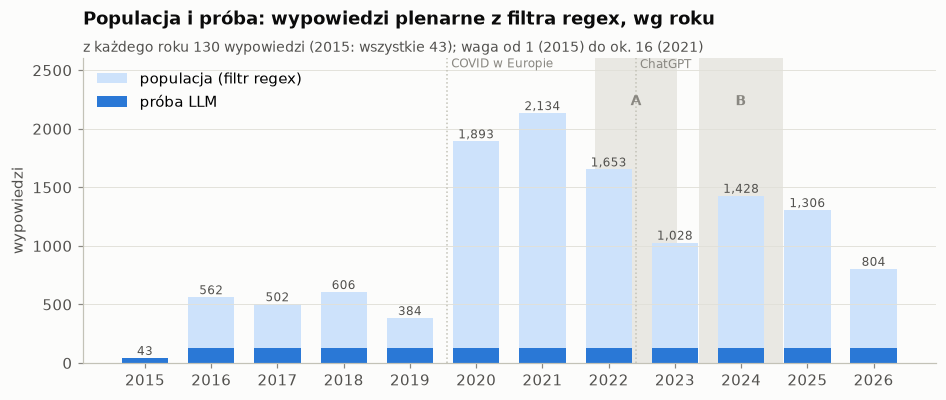

,N (populacja),n (próba),waga,% rząd: populacja,% rząd: próba,% inni: populacja,% inni: próba
rok,,,,,,,
2015,43,43,1.0,7.0,7.0,2.3,2.3
2016,562,130,4.3,11.6,10.0,2.8,3.1
2017,502,130,3.9,14.3,9.2,1.6,2.3
2018,606,130,4.7,15.0,11.5,2.8,4.6
2019,384,130,3.0,13.5,12.3,1.3,0.8
2020,1893,130,14.6,14.1,16.9,0.9,0.8
2021,2134,130,16.4,12.8,12.3,1.1,1.5
2022,1653,130,12.7,13.4,13.1,1.0,0.0
2023,1028,130,7.9,11.1,8.5,2.3,3.1


In [3]:
design = pd.DataFrame({"N (populacja)": filt.groupby("rok").size(), "n (próba)": df.groupby("rok").size()})
design["waga"] = design["N (populacja)"] / design["n (próba)"]
assert np.allclose(design["waga"], df.groupby("rok")["waga"].first())
for role in ["rząd", "inni"]:
    design[f"% {role}: populacja"] = filt["rola"].eq(role).groupby(filt["rok"]).mean() * 100
    design[f"% {role}: próba"] = df["rola"].eq(role).groupby(df["rok"]).mean() * 100

fig, ax = plt.subplots(figsize=(10, 3.6))
years = design.index
ax.bar(years, design["N (populacja)"], color=ACCENT_LIGHT, width=0.7, label="populacja (filtr regex)")
ax.bar(years, design["n (próba)"], color=ACCENT, width=0.7, label="próba LLM")
for x, tot in zip(years, design["N (populacja)"]):
    ax.text(x, tot, f"{tot:,}", ha="center", va="bottom", fontsize=8, color=INK2)
period_lines(ax)
ax.set_xticks(years); ax.grid(axis="x", visible=False)
ax.set_ylabel("wypowiedzi"); ax.set_ylim(0, design["N (populacja)"].max() * 1.22)
ax.legend(loc="upper left")
ax.set_title("Populacja i próba: wypowiedzi plenarne z filtra regex, wg roku")
subtitle(ax, "z każdego roku 130 wypowiedzi (2015: wszystkie 43); waga od 1 (2015) do ok. 16 (2021)")
save(fig, "llm_p_01_populacja"); plt.show()
design.round(1)

Populacja jest nierówna w czasie: 384–606 wypowiedzi rocznie w latach 2016–2019, 1 653–2 134 w latach 2020–2022 i 804–1 428
później. Przy stałym n = 130 wagi wynoszą od 1 (2015, cały rok w próbie) do ok. 16 (2021). Udział rządu i roli „inni” w próbie
waha się wokół wartości z populacji (różnice do ok. 5 pp w pojedynczym roku), bo losowanie nie było warstwowane po roli.

### 0.3 Kompletność danych

Czy metadane z API Sejmu (data, kadencja, mówca, rola, blok) są kompletne w próbie i w populacji filtra i czy dla każdej
wypowiedzi z próby jest wynik LLM. Blok mają tylko posłowie (członkom rządu spoza Sejmu i roli „inni” bloku się nie
przypisuje), więc braki pokazujemy osobno dla posłów oraz dla rządu i innych.

In [4]:
META_COLS = ["data", "kadencja", "mowca", "rola", "blok", "liczba_slow", "tekst"]


def missing(d):
    mp = d["rola"].eq("poseł")
    return pd.DataFrame({"wszyscy": d[META_COLS].isna().sum(), "posłowie": d.loc[mp, META_COLS].isna().sum(),
                         "rząd i inni": d.loc[~mp, META_COLS].isna().sum()})


display(Markdown("**Braki (NaN) w metadanych**"),
        pd.concat({f"próba ({len(df):,} wyp.)": missing(df), f"populacja filtra ({len(filt):,} wyp.)": missing(filt)}, axis=1))
display(Markdown("**Udział wypowiedzi bez bloku wg roli [%]**"),
        pd.DataFrame({"próba": df["blok"].isna().groupby(df["rola"]).mean() * 100,
                      "populacja filtra": filt["blok"].isna().groupby(filt["rola"]).mean() * 100}).round(1))

starts = pd.Series(paths.TERM_START)
term_from_date = starts.index[np.searchsorted(starts.values, df["data"].values, side="right") - 1]
mp_pop = filt[filt["rola"].eq("poseł")]
pd.Series({
    "duplikaty wypowiedz_id w próbie": int(df["wypowiedz_id"].duplicated().sum()),
    "wypowiedzi z próby spoza populacji filtra": int((~df["wypowiedz_id"].isin(filt["wypowiedz_id"])).sum()),
    "zakres dat w próbie": f"{df['data'].min():%Y-%m-%d} – {df['data'].max():%Y-%m-%d}",
    "kadencja niezgodna z datą": int((term_from_date != df["kadencja"].to_numpy()).sum()),
    "wypowiedzi < 40 słów / pusty tekst": f"{int((df['liczba_slow'] < 40).sum())} / {int(df['tekst'].str.strip().eq('').sum())}",
    "posłowie w populacji: brak klubu / brak member_id": f"{int(mp_pop['klub'].isna().sum())} / {int(mp_pop['member_id'].isna().sum())}",
    f"posłowie w próbie w grupie „{INNE}”": int((df["rola"].eq("poseł") & df["blok"].eq(INNE)).sum()),
    "LLM: błąd zgłoszony przez skrypt": int(df["blad"].notna().sum()),
    "LLM: brak pola zawiera_twierdzenie": int(df["zawiera_twierdzenie"].isna().sum()),
    "LLM: brak czasu lub liczby tokenów": int(df[["sekundy", "tokeny_we", "tokeny_wy"]].isna().any(axis=1).sum()),
}).to_frame("wartość")

**Braki (NaN) w metadanych**

próba (1,473 wyp.)                       \
                       wszyscy posłowie rząd i inni   
data                         0        0           0   
kadencja                     0        0           0   
mowca                        0        0           0   
rola                         0        0           0   
blok                       111        0         111   
liczba_slow                  0        0           0   
tekst                        0        0           0   

            populacja filtra (12,343 wyp.)                       
                                   wszyscy posłowie rząd i inni  
data                                     0        0           0  
kadencja                                 0        0           0  
mowca                                    0        0           0  
rola                                     0        0           0  
blok                                   949        0         949  
liczba_slow                              0        0           0  
tekst                                    0        0           0

**Udział wypowiedzi bez bloku wg roli [%]**

,próba,populacja filtra
rola,,
inni,92.0,93.1
poseł,0.0,0.0
rząd,51.8,51.1


,wartość
duplikaty wypowiedz_id w próbie,0
wypowiedzi z próby spoza populacji filtra,0
zakres dat w próbie,2015-11-12 – 2026-09-18
kadencja niezgodna z datą,0
wypowiedzi < 40 słów / pusty tekst,0 / 0
posłowie w populacji: brak klubu / brak member_id,0 / 0
posłowie w próbie w grupie „Inne / niez.”,45
LLM: błąd zgłoszony przez skrypt,0
LLM: brak pola zawiera_twierdzenie,0
LLM: brak czasu lub liczby tokenów,0


* Metadane są kompletne: brak NaN w dacie, kadencji, mówcy, roli, długości i tekście, zarówno w próbie, jak i w całej populacji
  filtra (12 343 wypowiedzi). Nie ma duplikatów, każda wypowiedź z próby należy do populacji, kadencja zgadza się z datą,
  a u wszystkich posłów jest klub i identyfikator posła.
* Jedyne braki dotyczą bloku (111 wypowiedzi w próbie, 949 w populacji) i wszystkie występują poza rolą „poseł”: bloku nie ma
  52% wypowiedzi rządu (członkowie rządu spoza Sejmu) i 92% roli „inni”. To wynika z definicji bloku, a nie z braków w API.
  Dlatego porównania bloków (6.2) obejmują tylko posłów, a rząd jest osobną grupą.
* 45 wypowiedzi posłów (3% próby) należy do grupy „Inne / niez.”: posłowie niezrzeszeni i małe koła (np. WiS, Republikanie).
* Wynik LLM jest kompletny dla wszystkich 1 473 wypowiedzi: brak błędów, brak pustych odpowiedzi, czas i tokeny zapisane.

## 1. Przegląd próby

Kto jest w próbie (rola mówcy i kadencja) w porównywanych okresach. Rola: **poseł**, **rząd** (ministrowie, wiceministrowie),
**inni** (np. Rzecznik Praw Obywatelskich, prezes NIK, przedstawiciele instytucji).

In [5]:
def by_groups(d, row):
    out = pd.concat({
        "okna": pd.crosstab(d[row], d["okno"]).reindex(columns=list(WINDOWS), fill_value=0),
        "okresy H1": pd.crosstab(d[row], d["okres"]).reindex(columns=PERIODS, fill_value=0).rename(columns=PERIOD_LABEL),
    }, axis=1)
    out[("cała próba", "")] = d[row].value_counts()
    return out


pd.concat({"rola": by_groups(df, "rola"), "kadencja": by_groups(df, "kadencja")})

okna          okresy H1                  cała próba
                    A      B przed COVID COVID po ChatGPT           
rola     inni     4.0    2.0          15     3          7         25
         poseł  142.0  174.0         493   320        465       1278
         rząd    19.0   19.0          60    52         58        170
kadencja 9      165.0    0.0          33   375         89        497
         10       0.0  195.0           0     0        441        441
         8        NaN    NaN         535     0          0        535

Posłowie to 87% próby, rząd 12%, a rola „inni” tylko 2%. Okno A leży w całości w IX kadencji, okno B w X kadencji, więc
porównanie okien jest jednocześnie porównaniem kadencji i składu Sejmu.

In [6]:
pd.Series({
    "model": df["model"].iloc[0],
    "prompt kroku 1": df["prompt"].iloc[0],
    "prompt kroku 2": ", ".join(sorted(df["prompt_weryfikacji"].unique())),
    "kontekst [tokeny]": ", ".join(map(str, sorted(df["num_ctx"].unique()))),
    "limit kandydatów": ", ".join(map(str, sorted(df["max_kandydatow"].unique()))),
    "czas przebiegu [h]": round(df["sekundy"].sum() / 3600, 2),
    "średnio [s / wypowiedź]": round(df["sekundy"].mean(), 1),
    "mediana [s / wypowiedź]": round(df["sekundy"].median(), 1),
    "błędy zgłoszone przez skrypt": int(df["blad"].notna().sum()),
    "ucięte do 2500 słów": int(df["obciete"].sum()),
    "obcięte wejście": int(df["przepelnienie"].sum()),
    "przesunięcie kontekstu": int(df["przesuniecie"].sum()),
    "pełny limit kandydatów": int((df["n_kandydatow"] >= df["max_kandydatow"]).sum()),
    "kandydaci": int(df["n_kandydatow"].sum()),
    "wypowiedzi z twierdzeniem": int(df["y"].sum()),
    "twierdzenia": int(df["n_twierdzen"].sum()),
}).to_frame("wartość")

,wartość
model,SpeakLeash/bielik-11b-v3.0-instruct:Q4_K_M
prompt kroku 1,etap_a_v2
prompt kroku 2,weryfikacja_v1
kontekst [tokeny],16384
limit kandydatów,16
czas przebiegu [h],5.49
średnio [s / wypowiedź],13.4
mediana [s / wypowiedź],4.5
błędy zgłoszone przez skrypt,0
ucięte do 2500 słów,26


Przebieg trwał 5,5 h (średnio 13,4 s na wypowiedź, mediana 4,5 s) i nie zgłosił błędów. Nie było przepełnienia kontekstu,
26 wypowiedzi uciętych do 2500 słów, 9 z pełnym limitem 16 kandydatów.

### Długość wypowiedzi

Rozkład długości w próbie i odsetek wypowiedzi z twierdzeniem w przedziałach długości (bez wag); w ostatniej kolumnie tabeli
średni czas modelu.

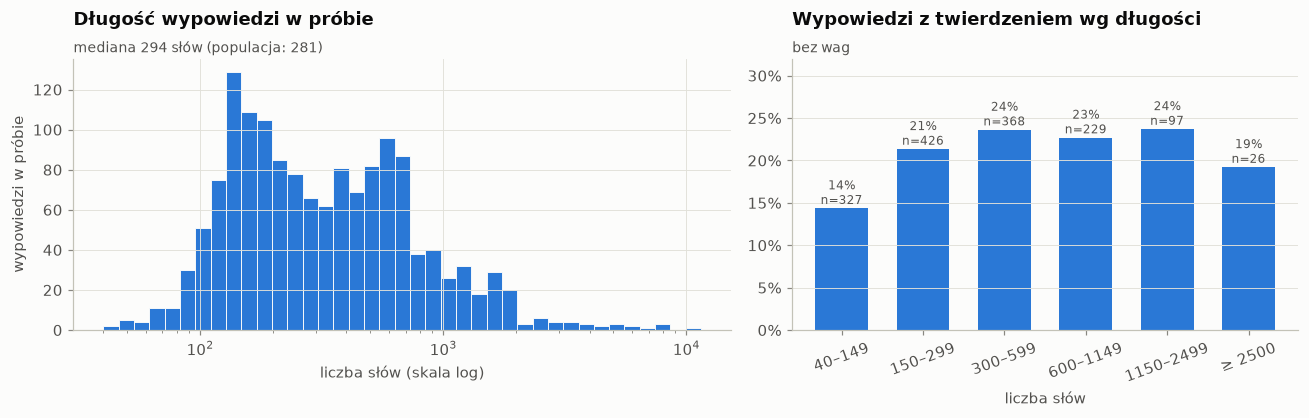

,wypowiedzi,z_twierdzeniem,twierdzenia_na_wyp,kandydaci_na_wyp,pelny_limit,sekundy
dlugosc,,,,,,
40–149,327,0.14,0.21,1.31,0.00,7.45
150–299,426,0.21,0.38,2.02,0.00,10.96
300–599,368,0.24,0.53,2.45,0.00,14.17
600–1149,229,0.23,0.59,2.90,0.01,17.15
1150–2499,97,0.24,0.42,5.26,0.06,28.65
≥ 2500,26,0.19,0.62,4.23,0.00,28.45


In [7]:
LEN_BINS = [40, 150, 300, 600, 1150, 2500, np.inf]
LEN_LABELS = ["40–149", "150–299", "300–599", "600–1149", "1150–2499", "≥ 2500"]
df["dlugosc"] = pd.cut(df["liczba_slow"], LEN_BINS, labels=LEN_LABELS, right=False)
df["pelny_limit"] = df["n_kandydatow"] >= df["max_kandydatow"]
by_len = df.groupby("dlugosc", observed=True).agg(
    wypowiedzi=("y", "size"), z_twierdzeniem=("y", "mean"), twierdzenia_na_wyp=("n_twierdzen", "mean"),
    kandydaci_na_wyp=("n_kandydatow", "mean"), pelny_limit=("pelny_limit", "mean"), sekundy=("sekundy", "mean"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.3, 1]})
bins = np.logspace(np.log10(40), np.log10(df["liczba_slow"].max() + 1), 40)
a1.hist(df["liczba_slow"], bins=bins, color=ACCENT, edgecolor=SURF, linewidth=0.6)
a1.set_xscale("log")
a1.set_xlabel("liczba słów (skala log)"); a1.set_ylabel("wypowiedzi w próbie")
a1.set_title("Długość wypowiedzi w próbie")
subtitle(a1, f"mediana {df['liczba_slow'].median():.0f} słów (populacja: {filt['liczba_slow'].median():.0f})")
x = np.arange(len(by_len))
a2.bar(x, by_len["z_twierdzeniem"], color=ACCENT, width=0.65)
for xi, (p, n) in enumerate(zip(by_len["z_twierdzeniem"], by_len["wypowiedzi"])):
    a2.text(xi, p, f"{p:.0%}\nn={n}", ha="center", va="bottom", fontsize=8, color=INK2)
a2.set_xticks(x, by_len.index, rotation=20); a2.yaxis.set_major_formatter(PCT); a2.grid(axis="x", visible=False)
a2.set_ylim(0, by_len["z_twierdzeniem"].max() * 1.35); a2.set_xlabel("liczba słów")
a2.set_title("Wypowiedzi z twierdzeniem wg długości")
subtitle(a2, "bez wag")
fig.tight_layout()
save(fig, "llm_p_02_dlugosc"); plt.show()
by_len.round(2)

Mediana długości w próbie (294 słowa) jest bliska populacji (281). Odsetek wypowiedzi z twierdzeniem rośnie od 14% (poniżej
150 słów) do ok. 24% (od 300 słów) i dalej się nie zmienia. Czas modelu rośnie z długością: od ok. 7 s dla krótkich wypowiedzi do
ok. 29 s dla najdłuższych.

## 2. Lejek detekcji: od kandydatów do twierdzeń

Krok 1 zwraca do 16 zdań-kandydatów z rodzajem zdania. Tylko kandydaci „naukowe” trafiają do kroku 2, który ocenia parafrazę
razem z fragmentem wypowiedzi.

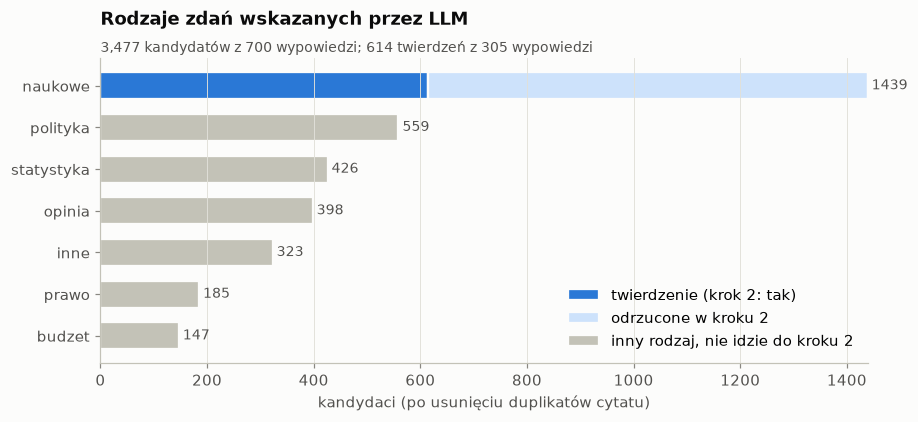

col_0,potwierdzone,odrzucone,niesprawdzane,razem
rodzaj,,,,
naukowe,614,825,0,1439
polityka,0,0,559,559
statystyka,0,0,426,426
opinia,0,0,398,398
inne,0,0,323,323
prawo,0,0,185,185
budzet,0,0,147,147


In [8]:
status = np.select([cand["weryfikacja"].eq(True), cand["weryfikacja"].eq(False)], ["potwierdzone", "odrzucone"], "niesprawdzane")
kinds = pd.crosstab(cand["rodzaj"], status).reindex(columns=["potwierdzone", "odrzucone", "niesprawdzane"], fill_value=0)
kinds = kinds.loc[kinds.sum(axis=1).sort_values().index]
STATUS = {"potwierdzone": (ACCENT, "twierdzenie (krok 2: tak)"), "odrzucone": (ACCENT_LIGHT, "odrzucone w kroku 2"),
          "niesprawdzane": (AXIS, "inny rodzaj, nie idzie do kroku 2")}

fig, ax = plt.subplots(figsize=(9, 3.6))
left = np.zeros(len(kinds))
for s in kinds.columns:
    ax.barh(range(len(kinds)), kinds[s], left=left, color=STATUS[s][0], height=0.65, edgecolor=SURF, linewidth=1.5, label=STATUS[s][1])
    left += kinds[s].values
for i, tot in enumerate(left):
    ax.text(tot, i, f" {int(tot)}", va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(kinds)), kinds.index); ax.grid(axis="y", visible=False)
ax.set_xlabel("kandydaci (po usunięciu duplikatów cytatu)")
ax.legend(loc="lower right")
ax.set_title("Rodzaje zdań wskazanych przez LLM")
subtitle(ax, f"{len(cand):,} kandydatów z {int(df['n_kandydatow'].gt(0).sum())} wypowiedzi; "
             f"{kinds['potwierdzone'].sum()} twierdzeń z {int(df['y'].sum())} wypowiedzi")
save(fig, "llm_p_03_rodzaje"); plt.show()
kinds.loc[::-1].assign(razem=kinds.sum(axis=1))

Ponad połowa wypowiedzi (53%) nie dała żadnego kandydata. Z 3 477 kandydatów 41% to zdania „naukowe”, a krok 2 potwierdza 43%
z nich (614 twierdzeń w 305 wypowiedziach). Najczęstsze inne rodzaje to polityka (559), statystyka (426) i opinia (398).

## 3. Agregacja po wypowiedzi

Dwie miary na poziomie wypowiedzi:

* **wypowiedź z twierdzeniem**: wypowiedź z co najmniej jednym potwierdzonym twierdzeniem (0/1);
* **twierdzenia na 100 wypowiedzi**: średnia liczba twierdzeń na wypowiedź × 100;
* **szacunki dla populacji**: N populacji filtra w grupie razy ważony udział z próby.

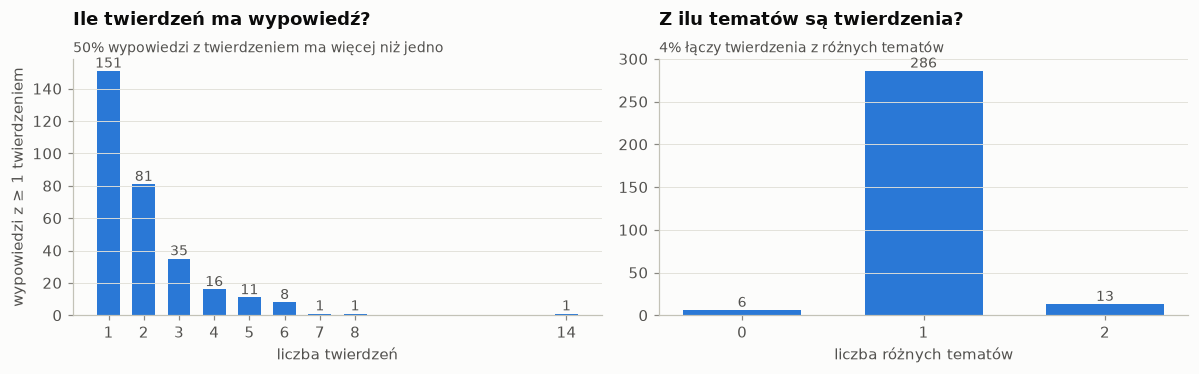

wypowiedzi z twierdzeniem: 305; z > 1 twierdzeniem: 50%; z twierdzeniami z > 1 tematu: 4%


In [9]:
z = df[df["y"] == 1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, title, xl in [(a1, "n_twierdzen", "Ile twierdzeń ma wypowiedź?", "liczba twierdzeń"),
                           (a2, "n_tematow", "Z ilu tematów są twierdzenia?", "liczba różnych tematów")]:
    vc = z[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=ACCENT, width=0.65)
    for k, v in vc.items():
        ax.text(k, v, f"{v}", ha="center", va="bottom", fontsize=9, color=INK2)
    ax.set_xticks(vc.index); ax.grid(axis="x", visible=False); ax.set_xlabel(xl)
    ax.set_title(title)
a1.set_ylabel("wypowiedzi z ≥ 1 twierdzeniem")
subtitle(a1, f"{(z['n_twierdzen'] > 1).mean():.0%} wypowiedzi z twierdzeniem ma więcej niż jedno")
subtitle(a2, f"{(z['n_tematow'] > 1).mean():.0%} łączy twierdzenia z różnych tematów")
fig.tight_layout()
save(fig, "llm_p_04_jednostka"); plt.show()
print(f"wypowiedzi z twierdzeniem: {len(z)}; z > 1 twierdzeniem: {(z['n_twierdzen'] > 1).mean():.0%}; "
      f"z twierdzeniami z > 1 tematu: {(z['n_tematow'] > 1).mean():.0%}")

In [10]:
ones = df.assign(one=1)


def totals(d, by, y="y"):
    """Population total per group: exact size of the filter population x weighted mean from the sample."""
    return (filt.groupby(by).size() * R.weighted_share(d, by, y=y)).dropna()


def unit_table(by, order, labels=None):
    d = df[df[by].notna()]
    b_y = R.bootstrap(d, by).loc[order]
    b_n = R.bootstrap(d, by, y="n_twierdzen").loc[order]
    return pd.DataFrame({
        "n (próba)": b_y["n"],
        "wypowiedzi z twierdzeniem [%]": fmt_ci(b_y),
        "twierdzenia na 100 wypowiedzi": fmt_ci(b_n),
        "twierdzenia na wypowiedź z twierdzeniem": R.weighted_share(d[d["y"] == 1], by, y="n_twierdzen").loc[order].round(2),
        "N populacji (filtr regex)": filt.groupby(by).size().loc[order],
        "szac. wypowiedzi z twierdzeniem": totals(d, by).loc[order].round().astype(int),
        "szac. twierdzenia": totals(d, by, "n_twierdzen").loc[order].round().astype(int),
    }).rename(index=labels or {})


units = pd.concat({
    "okna": unit_table("okno", list(WINDOWS), {k: f"okno {k}" for k in WINDOWS}),
    "ChatGPT": unit_table("chatgpt", ["przed", "po"], CHATGPT_LABEL),
    "okresy H1": unit_table("okres", PERIODS, PERIOD_LABEL),
    "kadencje": unit_table("kadencja", [8, 9, 10], {8: "VIII", 9: "IX", 10: "X"}),
})
units

n (próba) wypowiedzi z twierdzeniem [%]  \
okna      okno A               165             16.4 [11.0; 22.7]   
          okno B               195             15.2 [10.3; 20.6]   
ChatGPT   przed ChatGPT        943             18.9 [16.2; 21.7]   
          po ChatGPT           530             15.2 [12.1; 18.5]   
okresy H1 przed COVID          568             30.3 [26.3; 34.4]   
          COVID                375             14.4 [10.9; 18.1]   
          po ChatGPT           530             15.2 [12.1; 18.5]   
kadencje  VIII                 535             30.8 [26.8; 34.9]   
          IX                   497             14.9 [11.7; 18.1]   
          X                    441             15.1 [11.8; 18.6]   

                        twierdzenia na 100 wypowiedzi  \
okna      okno A                    33.9 [18.9; 53.6]   
          okno B                    31.1 [18.7; 45.7]   
ChatGPT   przed ChatGPT             34.6 [28.9; 40.4]   
          po ChatGPT                33.8 [25.0; 43.0]   
okresy H1 przed COVID               62.6 [52.1; 74.1]   
          COVID                     23.5 [17.0; 30.4]   
          po ChatGPT                33.8 [25.0; 43.0]   
kadencje  VIII                      62.0 [51.6; 73.0]   
          IX                        27.3 [20.2; 35.0]   
          X                         31.4 [23.2; 40.3]   

                         twierdzenia na wypowiedź z twierdzeniem  \
okna      okno A                                            2.07   
          okno B                                            2.04   
ChatGPT   przed ChatGPT                                     1.83   
          po ChatGPT                                        2.22   
okresy H1 przed COVID                                       2.06   
          COVID                                             1.63   
          po ChatGPT                                        2.22   
kadencje  VIII                                              2.01   
          IX                                                1.84   
          X                                                 2.09   

                         N populacji (filtr regex)  \
okna      okno A                              1710   
          okno B                              1966   
ChatGPT   przed ChatGPT                       7630   
          po ChatGPT                          4713   
okresy H1 przed COVID                         2183   
          COVID                               5447   
          po ChatGPT                          4713   
kadencje  VIII                                2029   
          IX                                  6405   
          X                                   3909   

                         szac. wypowiedzi z twierdzeniem  szac. twierdzenia  
okna      okno A                                     281                581  
          okno B                                     299                612  
ChatGPT   przed ChatGPT                             1445               2638  
          po ChatGPT                                 717               1593  
okresy H1 przed COVID                                663               1368  
          COVID                                      785               1278  
          po ChatGPT                                 717               1593  
kadencje  VIII                                       625               1257  
          IX                                         951               1750  
          X                                          588               1228

Przykład wypowiedzi z twierdzeniami z kilku tematów (najwięcej tematów w próbie):

In [11]:
ex_id = df.sort_values(["n_tematow", "n_twierdzen"], ascending=False)["wypowiedz_id"].iloc[0]
r = df.set_index("wypowiedz_id").loc[ex_id]
print(f"{ex_id}: {r['data']:%Y-%m-%d}, {r['kto']}, {r['liczba_slow']} słów")
cl.loc[cl["wypowiedz_id"] == ex_id, ["temat", "atrybucja", "twierdzenie"]]

8_77_2019-02-21_349: 2019-02-21, KO, 519 słów


,temat,atrybucja,twierdzenie
367,covid,wlasne,Odra jest wysoce zakaźną chorobą przenoszoną drogą kropelkową i przez brudne ręce.
368,szczepienia,wlasne,Dzieci między 6. a 13. miesiącem życia są szczególnie podatne na infekcje.
369,szczepienia,wlasne,Odra stanowi poważne zagrożenie dla życia i zdrowia małych dzieci.
370,szczepienia,wlasne,"Podawanie immunoglobulin może uratować życie dzieci chorych na odrę, co wcześniej nie było możliwe."
371,szczepienia,wlasne,"Immunoglobuliny są najskuteczniejsze, gdy podaje się je bezpośrednio po narażeniu na wirusa odry."
372,szczepienia,wlasne,"Szczepienie przeciw odrze można przesunąć na wcześniejszy wiek, co jest praktykowane w innych krajach."
373,szczepienia,wlasne,"Odra często powoduje poważne powikłania, takie jak zapalenie płuc, opon mózgowo-rdzeniowych i mózgu."


**Wnioski z agregacji.**

* Połowa wypowiedzi z twierdzeniem ma ich więcej niż jedno (średnio ok. 2 twierdzenia), ale tylko 4% łączy różne tematy.
  Przykład powyżej (posłanka KO, 2019) to siedem twierdzeń o odrze w jednej wypowiedzi. Jedno z nich LLM oznaczył jako `covid`,
  czyli etykieta tematu bywa błędna nawet w spójnej wypowiedzi (4.4, 9.8).
* **Okna:** twierdzenie ma 16,4% wypowiedzi z filtra w A i 15,2% w B (34 i 31 twierdzeń na 100 wypowiedzi). W populacji filtra to
  szacunkowo ok. 280 i 300 wypowiedzi z twierdzeniem oraz ok. 580 i 610 twierdzeń. Okna praktycznie się nie różnią (5.5).
* **Okresy H1 i kadencje:** przed COVID twierdzenie ma 30% wypowiedzi (63 twierdzenia na 100), w okresie COVID i po ChatGPT
  14–15% (24 i 34 na 100). Tak samo wygląda podział na kadencje: VIII 31%, IX i X po 15%.
* W liczbach bezwzględnych spadku nie ma: szacunkowo ok. 660 wypowiedzi z twierdzeniem przed COVID, 790 w okresie COVID
  i 720 po ChatGPT, bo populacja filtra rośnie (sekcja 5.2).

## 4. Tematy

### 4.1 Ile materiału daje każdy temat: słownik a LLM

Dla każdego tematu w próbie: ile wypowiedzi ma trafienie słownika, a ile zawiera twierdzenie naukowe z tego tematu wg LLM.

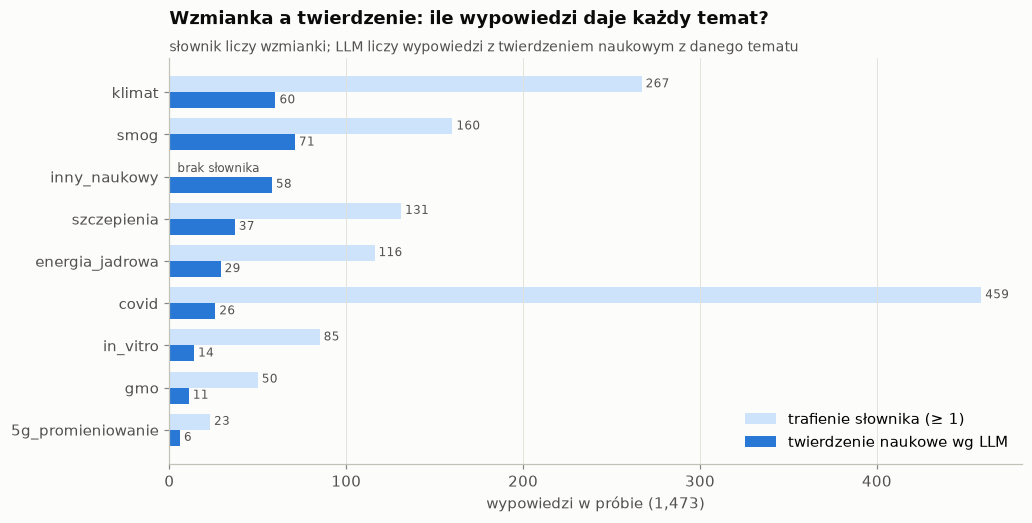

,twierdzenia,wypowiedzi: LLM,wypowiedzi: regex ≥ 1,wypowiedzi: regex ≥ 3,LLM wśród regex ≥ 1 [%],regex ≥ 1 wśród LLM [%]
klimat,139,60,267.0,41.0,15.7,70.0
smog,123,71,160.0,43.0,40.0,90.1
inny_naukowy,101,58,NaN,NaN,NaN,NaN
szczepienia,93,37,131.0,58.0,24.4,86.5
energia_jadrowa,50,29,116.0,21.0,11.2,44.8
covid,41,26,459.0,99.0,5.0,88.5
in_vitro,26,14,85.0,23.0,16.5,100.0
gmo,21,11,50.0,20.0,20.0,90.9
5g_promieniowanie,12,6,23.0,7.0,26.1,100.0


In [12]:
rows = []
for t in TOPICS_LLM:
    llm_t = df[f"tw_{t}"].eq(1)
    row = {"twierdzenia": int(cl["temat"].eq(t).sum()), "wypowiedzi: LLM": int(llm_t.sum())}
    if t in TOPICS:
        rx = df[t].gt(0)
        row |= {"wypowiedzi: regex ≥ 1": int(rx.sum()), "wypowiedzi: regex ≥ 3": int(df[t].ge(T.PROG).sum()),
                "LLM wśród regex ≥ 1 [%]": 100 * llm_t[rx].mean(),
                "regex ≥ 1 wśród LLM [%]": 100 * rx[llm_t].mean() if llm_t.any() else np.nan}
    rows.append(row)
topics_tab = pd.DataFrame(rows, index=TOPICS_LLM).sort_values("twierdzenia", ascending=False)

order = topics_tab.index[::-1]
yy = np.arange(len(order)); h = 0.38
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(yy + h / 2, topics_tab.loc[order, "wypowiedzi: regex ≥ 1"].fillna(0), height=h, color=ACCENT_LIGHT, label="trafienie słownika (≥ 1)")
ax.barh(yy - h / 2, topics_tab.loc[order, "wypowiedzi: LLM"], height=h, color=ACCENT, label="twierdzenie naukowe wg LLM")
for yi, t in enumerate(order):
    a, b = topics_tab.at[t, "wypowiedzi: regex ≥ 1"], topics_tab.at[t, "wypowiedzi: LLM"]
    ax.text(0 if np.isnan(a) else a, yi + h / 2, "  brak słownika" if np.isnan(a) else f" {a:.0f}", va="center", fontsize=8, color=INK2)
    ax.text(b, yi - h / 2, f" {b}", va="center", fontsize=8, color=INK2)
ax.set_yticks(yy, order); ax.grid(axis="y", visible=False)
ax.set_xlabel(f"wypowiedzi w próbie ({len(df):,})")
ax.legend(loc="lower right")
ax.set_title("Wzmianka a twierdzenie: ile wypowiedzi daje każdy temat?")
subtitle(ax, "słownik liczy wzmianki; LLM liczy wypowiedzi z twierdzeniem naukowym z danego tematu")
save(fig, "llm_p_05_tematy_skala"); plt.show()
topics_tab.round(1)

* Na posiedzeniach plenarnych najwięcej twierdzeń dotyczy klimatu (139) i smogu (123); `inny_naukowy` to 101 twierdzeń (16%).
* **Wzmianka rzadko oznacza twierdzenie.** Tylko 5% wypowiedzi ze słowem ze słownika COVID zawiera twierdzenie o COVID, 16% dla
  klimatu, 24% dla szczepień, 40% dla smogu. Skala tematów ze słowników przecenia materiał dla etapu B, najbardziej
  dla COVID.
* W drugą stronę słowniki zwykle działają: 86–100% wypowiedzi z twierdzeniem z danego tematu ma trafienie słownika tego tematu.
  Wyjątki to klimat (70%) i `energia_jadrowa` (45%), bo LLM używa tych etykiet szerzej (4.3, 4.4).

### 4.2 Tematy w czasie: okna A i B, przed i po ChatGPT

Wypowiedzi z twierdzeniem z danego tematu **na 1000 wypowiedzi populacji** (estymator ważony). Pod wykresem liczby twierdzeń w próbie.

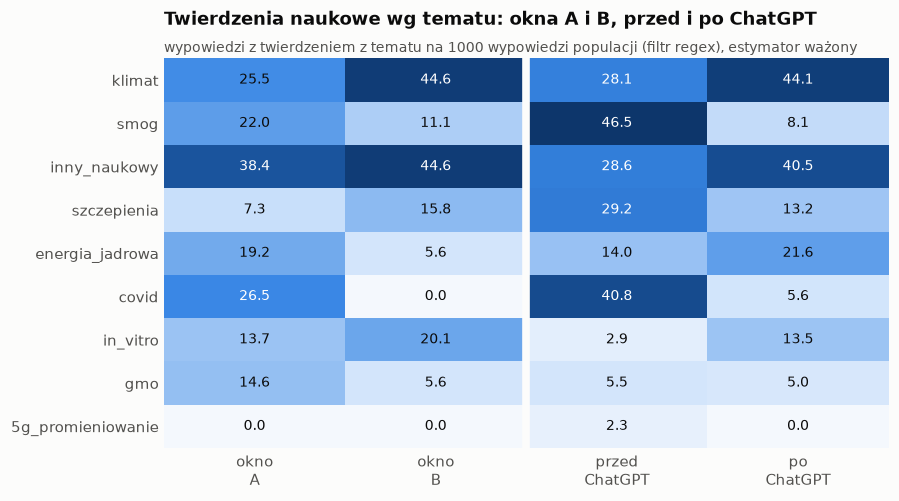

,okno A,okno B,przed ChatGPT,po ChatGPT
klimat,27,14,74,65
smog,3,2,115,8
inny_naukowy,7,20,61,40
szczepienia,4,7,75,18
energia_jadrowa,3,2,31,19
covid,6,0,33,8
in_vitro,5,9,12,14
gmo,4,2,16,5
5g_promieniowanie,0,0,12,0
wypowiedzi w próbie,165,195,943,530


In [13]:
COLS = [("okno", "A", "okno A"), ("okno", "B", "okno B"), ("chatgpt", "przed", "przed ChatGPT"), ("chatgpt", "po", "po ChatGPT")]


def wshare(d, y):
    return (d[y] * d["waga"]).sum() / d["waga"].sum()


heat = pd.DataFrame({lab: [1000 * wshare(df[df[by] == v], f"tw_{t}") for t in topics_tab.index] for by, v, lab in COLS},
                    index=topics_tab.index)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.imshow(heat.values, cmap=SEQ, aspect="auto", vmin=0)
ax.set_xticks(range(len(COLS)), [lab.replace(" ", "\n", 1) for _, _, lab in COLS]); ax.set_yticks(range(len(heat)), heat.index)
ax.axvline(1.5, color=SURF, lw=5)
ax.grid(False); ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
thr = heat.values.max() * 0.55
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9, color="white" if v > thr else INK)
ax.set_title("Twierdzenia naukowe wg tematu: okna A i B, przed i po ChatGPT")
subtitle(ax, "wypowiedzi z twierdzeniem z tematu na 1000 wypowiedzi populacji (filtr regex), estymator ważony")
save(fig, "llm_p_06_tematy_okresy"); plt.show()
counts = pd.DataFrame({lab: cl.loc[cl[by] == v, "temat"].value_counts() for by, v, lab in COLS}).reindex(heat.index).fillna(0).astype(int)
counts.loc["wypowiedzi w próbie"] = [int((df[by] == v).sum()) for by, v, _ in COLS]
counts

* Przed i po ChatGPT (na 1000 wypowiedzi populacji): klimat rośnie (28 → 44), smog prawie znika (47 → 8), maleją COVID (41 → 6)
  i szczepienia (29 → 13), rośnie in vitro (3 → 14).
* W oknach klimat to 26 (A) i 45 (B) na 1000, ale twierdzeń o klimacie w próbie jest w A więcej (27 wobec 14), bo 14 z nich
  pochodzi z jednej wypowiedzi o kryzysie wodnym (5.5). Liczby dla okien opierają się na kilku wypowiedziach na temat.

### 4.3 Przykładowe twierdzenia (kontrola jakości)

Losowo po dwa twierdzenia z każdego tematu: cytat z wypowiedzi i parafraza LLM.

In [14]:
lines = []
for t in topics_tab.index:
    s = cl[cl["temat"] == t]
    lines.append(f"**{t}**")
    for _, r in s.sample(min(2, len(s)), random_state=3).iterrows():
        kto = r["blok"] if r["rola"] == "poseł" and isinstance(r["blok"], str) else r["rola"]
        lines.append(f"- *{r['data']:%Y-%m-%d}, {kto}:* „{r['cytat']}” → {r['twierdzenie']}")
display(Markdown("\n".join(lines)))

**klimat**
- *2017-12-13, PiS:* „Projekt ustawy o zmianie niektórych ustaw w celu ułatwienia zwalczania chorób zakaźnych zwierząt, który jest projektem rządowym, rozszerza uprawnienia administracji w celu skutecznego pokonania występującego już od prawie 4 lat w Polsce wirusa afrykańskiego pomoru świń.” → Afrykański pomór świń (ASF) jest chorobą zakaźną zwierząt, która występuje w Polsce od prawie 4 lat.
- *2024-10-10, rząd:* „w Polsce mamy monokulturę świerka, mamy w Polsce monokulturę sosny” → W Polsce dominują monokultury świerka i sosny.
**smog**
- *2019-01-31, KO:* „Elektrownia Bełchatów jest największa trucicielką w Europie.” → Elektrownia Bełchatów jest największym emitentem zanieczyszczeń w Europie.
- *2018-04-13, KO:* „wyeliminowanie wszystkich paliw złej jakości to bardzo potrzebna regulacja, postulowana od dawna przez ekspertów i stronę społeczną, w efekcie której nastąpiłaby szybka i odczuwalna poprawa jakości powietrza” → Eliminacja niskiej jakości paliw znacząco poprawi jakość powietrza
**inny_naukowy**
- *2017-12-14, PiS:* „Przeprowadzone wcześniej badania wykazały, że afrykański pomór świń pojawił się na terenie Polski właśnie za sprawą dzików, które przywędrowały do naszego kraju z Białorusi czy może z Ukrainy.” → ASF w Polsce został przeniesiony przez dziki z Białorusi lub Ukrainy.
- *2019-12-19, PSL:* „to jest kwestia walki z chorobą, na którą na razie nie ma szczepionek, nie ma leków.” → Nie istnieją obecnie szczepionki ani leki na tę chorobę.
**szczepienia**
- *2019-06-14, KO:* „Istnieje szczepionka, szkoda, że ona nie jest dostępna jako refundowana dla wszystkich dzieci, tylko dla tych grup ryzyka, o których mówiłam.” → Szczepionka przeciw ospie wietrznej jest dostępna, ale w Polsce jest refundowana tylko dla określonych grup ryzyka.
- *2018-10-03, inni:* „75% polskiego społeczeństwa się nie szczepi. Czy to nie jest zastanawiające?” → Większość społeczeństwa nie poddaje się szczepieniom ochronnym, co może wpływać na odporność zbiorowiskową.
**energia_jadrowa**
- *2026-07-01, KO:* „gdybyśmy byli - tak jak mówił wczoraj pan poseł Mulawa - skazani tylko na elektrownie węglowe, to niestety zabrakłoby wody do chłodzenia tych elektrowni i dopiero byśmy mieli stopień zasilania - może dwudziesty.” → Elektrownie węglowe wymagają dużych ilości wody do chłodzenia, co może prowadzić do problemów z zasilaniem w przypadku niedoboru wody.
- *2025-02-20, rząd:* „Żeby móc zrealizować inwestycje, te badania trzeba wykonać, i my te badania będziemy brać pod uwagę.” → Badania sejsmiczne, geologiczne i hydrologiczne są niezbędne do wyboru lokalizacji elektrowni jądrowej.
**covid**
- *2026-05-13, PiS:* „Generalnie jeśli chodzi o HIV, mamy niestety w ostatnim czasie pandemię, jeśli chodzi o ten element zakaźny.” → W ostatnim czasie obserwuje się wzrost zachorowań na HIV, co można określić jako pandemię.
- *2020-11-18, Konfederacja:* „Oto ludzie niezdiagnozowani w porę, tacy, którzy nie doczekali się właściwej terapii, w ogóle nie dotarli do lekarza wiosną, latem i jesienią, teraz umierają.” → Opóźnienia w diagnozie i leczeniu prowadzą do wzrostu śmiertelności.
**in_vitro**
- *2016-05-19, PiS:* „wadę serca 2,5 raza częściej stwierdza się u dzieci poczętych z in vitro, rozszczepienie wargi...” → Dzieci poczęte metodą in vitro mają 2,5 razy większe ryzyko wady serca i innych wad wrodzonych.
- *2023-11-22, KO:* „Na szczęście jest in vitro, na szczęście jest metoda, dzięki której w Polsce urodziło się 100 tys. dzieci, i to nie dzięki państwu, tylko dzięki samorządom.” → Metoda in vitro przyczyniła się do urodzenia 100 tys. dzieci w Polsce, głównie dzięki finansowaniu samorządów.
**gmo**
- *2018-11-21, PiS:* „Polska nie jest wolna od GMO” → Polska nie jest wolna od GMO
- *2019-06-12, PiS:* „Pan minister powiedział, że istota modyfikacji genetycznych w większości przypadków polega na tym, że roślinom jest wszczepiany gen odporności na składnik czynny Roundupu, czyli glifosat, i dzięki temu rośliny użytkowe, np. soja, opryskane Roundupem przetrwają, natomiast chwasty będą zniszczone.” → Modyfikacje genetyczne roślin często polegają na wszczepieniu genu odporności na glifosat, co pozwala na selektywne niszczenie chwastów.
**5g_promieniowanie**
- *2019-07-04, Konfederacja:* „Nie mogę z zadowoleniem powitać takiej technologii - chodzi o technologię 5G - jeśli standardy promieniowania, które muszą chronić obywatela, nie są przestrzegane.” → Technologia 5G wymaga przestrzegania standardów promieniowania dla ochrony obywateli.
- *2019-07-04, Konfederacja:* „Polacy muszą być w 100% pewni, że ta technologia nie szkodzi życiu i zdrowiu zarówno matek, jak i kobiet w ciąży.” → Brak pewności co do bezpieczeństwa technologii 5G dla życia i zdrowia.

### 4.4 Temat `energia_jadrowa`

Czy twierdzenia oznaczone jako energia jądrowa dotyczą atomu (słowa kluczowe w cytacie lub parafrazie)?

In [15]:
NUC = r"jądr|atom|reaktor|uran|SMR"
RAD = r"promieniotw|jonizuj|radioakty|radon|izotop"
ej = cl[cl["temat"] == "energia_jadrowa"]
txt = ej["twierdzenie"] + " " + ej["cytat"]
about = txt.str.contains(NUC, case=False)
rad = txt.str.contains(RAD, case=False) & ~about
print(f"energia_jadrowa: {len(ej)} twierdzeń; o atomie: {about.sum()} ({about.mean():.0%}); "
      f"o promieniowaniu jonizującym: {rad.sum()} ({rad.mean():.0%}); pozostałe: {(~about & ~rad).sum()}")
ej.loc[~about & ~rad, ["rok", "twierdzenie"]]

energia_jadrowa: 50 twierdzeń; o atomie: 6 (12%); o promieniowaniu jonizującym: 11 (22%); pozostałe: 33


,rok,twierdzenie
18,2021,Uwalnianie pasma 700 MHz pod usługi 5G wymaga refarmingu częstotliwości i przestrojenia multipleksów telewizji naziemnej.
19,2021,Wprowadzenie nowszego systemu kompresji (DVB-T2) poprawi jakość telewizji naziemnej.
20,2025,"Około 40% światowej energii elektrycznej pochodzi z węgla, a jego udział rośnie pomimo presji klimatycznej."
22,2018,"Efektywność jednoczesnej produkcji ciepła i prądu jest o ok. 50% wyższa niż w przypadku ich oddzielnego wytwarzania, co prowadzi do ograniczenia emisji zanieczyszczeń."
47,2022,"Energetyka odnawialna nie jest wystarczająco wydolna, aby zaspokoić potrzeby energetyczne kraju samodzielnie."
70,2016,W marcu i kwietniu pojawiły się wątpliwości dotyczące stosowania protonoterapii w leczeniu glejaków wielopostaciowych i nowotworów okołordzeniowych u dzieci.
128,2026,"Elektrownie węglowe wymagają dużych ilości wody do chłodzenia, co może prowadzić do problemów z zasilaniem w przypadku niedoboru wody."
129,2026,"Fotowoltaika jest uzupełnieniem dla energii wiatrowej, gdy nie wieje."
130,2026,"Istnieje korelacja między produkcją energii wiatrowej a fotowoltaicznej, co widać na wykresach systemu energetycznego."
135,2016,Energia z węgla i OZE uzupełniają się wzajemnie ze względu na stabilność produkcji węgla i zmienność OZE.


Tylko 6 z 50 twierdzeń `energia_jadrowa` dotyczy atomu, a 11 promieniowania jonizującego (głównie jedna wypowiedź z 2019 r.
o ochronie radiologicznej). Pozostałe 33 to energetyka w ogóle (OZE, węgiel, blackout, kogeneracja, pompy ciepła), ale też
częstotliwości 5G i telewizja naziemna oraz protonoterapia. Model czyta etykietę jako „energetyka i promieniowanie”. Podobnie
z klimatem: w przykładach w 4.3 jako klimat oznaczone są ASF i monokultury leśne, a w oknach (5.5) choroby układu krążenia.

### 4.5 Skład tematów w czasie

Szacowana liczba twierdzeń wg tematu w każdym roku (twierdzenie dostaje wagę swojej wypowiedzi) i udział tematów
w twierdzeniach danego roku. Rzadkie tematy (in vitro, GMO, 5G, `brak`) są połączone w „pozostałe”. Klimat leży na dole
każdego słupka, żeby jego udział dało się odczytać wprost.

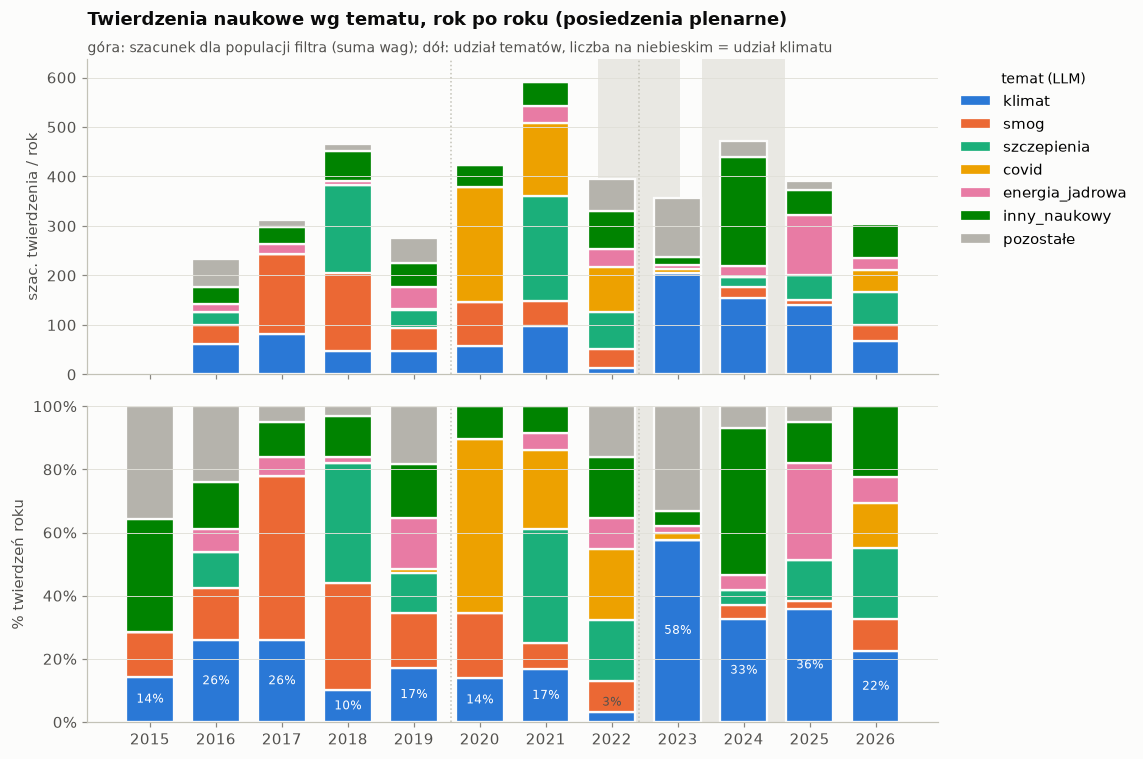

**Twierdzenia w próbie wg roku i tematu**

rok,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
grupa,,,,,,,,,,,,
klimat,2.0,14.0,21.0,10.0,16.0,4.0,6.0,1.0,26.0,14.0,14.0,11.0
smog,2.0,9.0,42.0,34.0,16.0,6.0,3.0,3.0,0.0,2.0,1.0,5.0
szczepienia,0.0,6.0,0.0,38.0,12.0,0.0,13.0,6.0,0.0,2.0,5.0,11.0
covid,0.0,0.0,0.0,0.0,1.0,16.0,9.0,7.0,1.0,0.0,0.0,7.0
energia_jadrowa,0.0,4.0,5.0,2.0,15.0,0.0,2.0,3.0,1.0,2.0,12.0,4.0
inny_naukowy,5.0,8.0,9.0,13.0,16.0,3.0,3.0,6.0,2.0,20.0,5.0,11.0
pozostałe,5.0,13.0,4.0,3.0,17.0,0.0,0.0,5.0,15.0,3.0,2.0,0.0
razem,14.0,54.0,81.0,100.0,93.0,29.0,36.0,31.0,45.0,43.0,39.0,49.0
klimat: % twierdzeń (ważony),14.3,25.9,25.9,10.0,17.2,13.8,16.7,3.2,57.8,32.6,35.9,22.4


,twierdzenia (próba),o klimacie (próba),klimat: % twierdzeń (ważony)
okno A,60.0,27.0,37.0
okno B,59.0,14.0,25.1
przed COVID,346.0,66.0,20.7
COVID,87.0,8.0,9.8
po ChatGPT,181.0,65.0,35.8
cała próba,614.0,139.0,23.0


In [16]:
TOPIC_GROUPS = ["klimat", "smog", "szczepienia", "covid", "energia_jadrowa", "inny_naukowy", "pozostałe"]
TOPIC_KOLOR = dict(zip(TOPIC_GROUPS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#b5b3ac"]))
YEARS = sorted(df["rok"].unique())
cl["grupa"] = cl["temat"].where(cl["temat"].isin(TOPIC_GROUPS), "pozostałe")
est_g = (cl.pivot_table(index="rok", columns="grupa", values="waga", aggfunc="sum", fill_value=0)
         .reindex(index=YEARS, columns=TOPIC_GROUPS, fill_value=0))
share_g = est_g.div(est_g.sum(axis=1), axis=0).fillna(0)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)
for ax, data in [(a1, est_g), (a2, share_g)]:
    bottom = np.zeros(len(data))
    for g in TOPIC_GROUPS:
        ax.bar(data.index, data[g], bottom=bottom, color=TOPIC_KOLOR[g], width=0.72, edgecolor=SURF, linewidth=1.5, label=g)
        bottom += data[g].to_numpy()
    ax.grid(axis="x", visible=False)
    period_lines(ax, label=False)
for x, v in share_g["klimat"].items():
    ax_y, col = (v / 2, "white") if v >= 0.08 else (v + 0.01, INK2)
    a2.text(x, ax_y, f"{v:.0%}", ha="center", va="center" if v >= 0.08 else "bottom", fontsize=8, color=col)
a1.set_ylabel("szac. twierdzenia / rok"); a1.set_ylim(0, est_g.sum(axis=1).max() * 1.08)
a2.set_ylabel("% twierdzeń roku"); a2.yaxis.set_major_formatter(PCT); a2.set_ylim(0, 1)
a2.set_xticks(YEARS)
a1.legend(loc="upper left", bbox_to_anchor=(1.01, 1), title="temat (LLM)", title_fontsize=9)
a1.set_title("Twierdzenia naukowe wg tematu, rok po roku (posiedzenia plenarne)")
subtitle(a1, "góra: szacunek dla populacji filtra (suma wag); dół: udział tematów, liczba na niebieskim = udział klimatu")
fig.tight_layout()
save(fig, "llm_p_21_tematy_sklad"); plt.show()

tab = pd.crosstab(cl["rok"], cl["grupa"]).reindex(index=YEARS, columns=TOPIC_GROUPS, fill_value=0)
tab["razem"] = tab.sum(axis=1)
tab["klimat: % twierdzeń (ważony)"] = (100 * share_g["klimat"]).round(1)
display(Markdown("**Twierdzenia w próbie wg roku i tematu**"), tab.T)


def klimat_share(d):
    return 100 * (d["waga"] * d["temat"].eq("klimat")).sum() / d["waga"].sum()


groups_k = {"okno A": cl["okno"].eq("A"), "okno B": cl["okno"].eq("B"),
            **{PERIOD_LABEL[p]: cl["okres"].eq(p) for p in PERIODS}, "cała próba": cl["rok"].notna()}
pd.DataFrame({k: {"twierdzenia (próba)": int(m.sum()), "o klimacie (próba)": int(cl.loc[m, "temat"].eq("klimat").sum()),
                  "klimat: % twierdzeń (ważony)": round(klimat_share(cl[m]), 1)} for k, m in groups_k.items()}).T

* Skład tematów zmienia się falami, zgodnie z debatami w Sejmie: smog dominuje w latach 2017–2018 (52% i 34% twierdzeń),
  szczepienia w 2018 r. (38%) i 2021 r., COVID w latach 2020–2022 (55% twierdzeń w 2020 r.), energia jądrowa i energetyka
  w 2025 r. (31%).
* **Klimat** to przed 2020 r. 10–26% twierdzeń rocznie, w okresie COVID 3–17%, a od 2023 r. największy temat: 58% w 2023 r.,
  33% w 2024 r., 36% w 2025 r. i 22% w 2026 r. Po ChatGPT klimat to 36% twierdzeń, przed COVID 21%, w okresie COVID 10%.
  W liczbach bezwzględnych to ok. 45–100 twierdzeń o klimacie rocznie do 2021 r. i ok. 140–200 w latach 2023–2025.
* Rok 2023 trzeba czytać ostrożnie: 26 twierdzeń o klimacie w próbie pochodzi z czterech wypowiedzi, z czego 14 z jednej
  (kryzys wodny, KO, 25.05.2023), a 5 z wypowiedzi o lasach. Podobnie w oknach: klimat to 37% twierdzeń w A (27 z 60) i 25%
  w B (14 z 59), ale wynik w A daje głównie ta jedna wypowiedź.
* Etykieta `klimat` obejmuje też tematy przyrodnicze, które nie dotyczą klimatu (4.6), więc udział klimatu jest tu zawyżony.

### 4.6 Klimat: ile jest materiału

Hipoteza ze slajdu dotyczy klimatu, więc tu osobno wypowiedzi z twierdzeniem o klimacie (temat nadany przez LLM w kroku 1).
Najpierw rok po roku: szacunek dla populacji filtra (N roku × ważony udział) z 95% przedziałem z bootstrapu. Potem okna A i B:
wzmianki ze słownika w korpusie, wypowiedzi z twierdzeniem w próbie i szacunek dla populacji. Na koniec, jak w 4.4, sprawdzenie,
czy twierdzenia z etykietą `klimat` dotyczą klimatu.

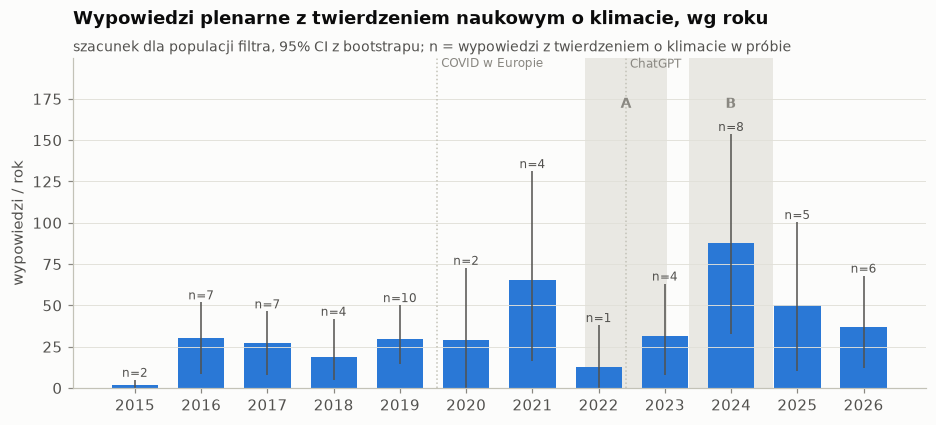

rok,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
n (próba),43,130,130,130,130,130,130,130,130,130,130,130
z twierdzeniem o klimacie (próba),2,7,7,4,10,2,4,1,4,8,5,6
twierdzenia o klimacie (próba),2,14,21,10,16,4,6,1,26,14,14,11
szac. wypowiedzi w populacji [95% CI],2 [0; 5],30 [9; 52],27 [8; 46],19 [5; 42],30 [15; 50],29 [0; 73],66 [16; 131],13 [0; 38],32 [8; 63],88 [33; 154],50 [10; 100],37 [12; 68]


In [17]:
N_rok = filt.groupby("rok").size()
kl_y = R.bootstrap(df, "rok", y="tw_klimat")
kl_tot = kl_y[["p", "lo", "hi"]].mul(N_rok, axis=0)
n_kl = df.groupby("rok")["tw_klimat"].sum()
fig, ax = plt.subplots(figsize=(10, 3.9))
ax.bar(kl_tot.index, kl_tot["p"], color=ACCENT, width=0.7)
ax.errorbar(kl_tot.index, kl_tot["p"], yerr=[kl_tot["p"] - kl_tot["lo"], kl_tot["hi"] - kl_tot["p"]],
            fmt="none", ecolor=INK2, elinewidth=1, capsize=0)
for x, h, n in zip(kl_tot.index, kl_tot["hi"], n_kl):
    ax.text(x, h, f"n={n}", ha="center", va="bottom", fontsize=8, color=INK2)
period_lines(ax)
ax.set_xticks(kl_tot.index); ax.grid(axis="x", visible=False); ax.set_ylim(0, kl_tot["hi"].max() * 1.3)
ax.set_ylabel("wypowiedzi / rok")
ax.set_title("Wypowiedzi plenarne z twierdzeniem naukowym o klimacie, wg roku")
subtitle(ax, "szacunek dla populacji filtra, 95% CI z bootstrapu; n = wypowiedzi z twierdzeniem o klimacie w próbie")
save(fig, "llm_p_22_klimat_rok"); plt.show()
pd.DataFrame({"n (próba)": df.groupby("rok").size(), "z twierdzeniem o klimacie (próba)": n_kl,
              "twierdzenia o klimacie (próba)": cl[cl["temat"] == "klimat"].groupby("rok").size().reindex(YEARS, fill_value=0),
              "szac. wypowiedzi w populacji [95% CI]": [f"{p:.0f} [{lo:.0f}; {hi:.0f}]" for p, lo, hi in kl_tot.to_numpy()]}).T

In [18]:
dwin = df[df["okno"].notna()]
mer_w = mer[mer["okno"].notna()]
N_win = filt[filt["okno"].notna()].groupby("okno").size()
kl_w = R.bootstrap(dwin, "okno", y="tw_klimat").loc[list(WINDOWS)]
right_mp = dwin["rola"].eq("poseł") & dwin["blok"].isin(RIGHT)
clk = cl[cl["temat"].eq("klimat") & cl["okno"].notna()].assign(kto=lambda x: who(x))
rows = {}
for k in WINDOWS:
    m, mm = dwin["okno"] == k, mer_w["okno"] == k
    rows[f"okno {k}"] = {
        "korpus: wypowiedzi merytoryczne ze wzmianką o klimacie (≥ 1)": int(mer_w.loc[mm, "klimat"].ge(1).sum()),
        "korpus: wypowiedzi tematyczne o klimacie (≥ 3)": int(mer_w.loc[mm, "klimat"].ge(T.PROG).sum()),
        "próba: wypowiedzi": int(m.sum()),
        "próba: wzmianka o klimacie (regex ≥ 1)": int(dwin.loc[m, "klimat"].ge(1).sum()),
        "próba: wypowiedzi z twierdzeniem o klimacie (LLM)": int(dwin.loc[m, "tw_klimat"].sum()),
        "  w tym posłowie PiS i Konfederacji": int(dwin.loc[m & right_mp, "tw_klimat"].sum()),
        "  w tym bez wzmianki o klimacie (regex = 0)": int(dwin.loc[m & dwin["klimat"].eq(0), "tw_klimat"].sum()),
        "próba: twierdzenia o klimacie": int(clk["okno"].eq(k).sum()),
        "próba: mówcy z twierdzeniem o klimacie": int(clk.loc[clk["okno"].eq(k), "mowca"].nunique()),
        "szac. wypowiedzi z twierdzeniem o klimacie w populacji [95% CI]":
            f"{N_win[k] * kl_w.at[k, 'p']:.0f} [{N_win[k] * kl_w.at[k, 'lo']:.0f}; {N_win[k] * kl_w.at[k, 'hi']:.0f}]",
    }
display(pd.DataFrame(rows))
clk.sort_values(["okno", "data"])[["okno", "data", "kto", "atrybucja", "twierdzenie"]].assign(
    data=lambda x: x["data"].dt.strftime("%Y-%m-%d")).reset_index(drop=True)

,okno A,okno B
korpus: wypowiedzi merytoryczne ze wzmianką o klimacie (≥ 1),244,617
korpus: wypowiedzi tematyczne o klimacie (≥ 3),32,145
próba: wypowiedzi,165,195
próba: wzmianka o klimacie (regex ≥ 1),31,51
próba: wypowiedzi z twierdzeniem o klimacie (LLM),5,8
w tym posłowie PiS i Konfederacji,1,4
w tym bez wzmianki o klimacie (regex = 0),2,2
próba: twierdzenia o klimacie,27,14
próba: mówcy z twierdzeniem o klimacie,5,8
szac. wypowiedzi z twierdzeniem o klimacie w populacji [95% CI],44 [8; 84],88 [33; 155]


,okno,data,kto,atrybucja,twierdzenie
0,A,2022-09-29,PiS,wlasne,Choroby sercowo-naczyniowe są główną przyczyną zgonów globalnie.
1,A,2023-05-24,Lewica,wlasne,"Zakaz połowu dorsza w Morzu Bałtyckim jest słuszny, ponieważ istnieje groźba wymarcia dorsza, co potwierdzają naukowcy."
2,A,2023-05-25,KO,wlasne,Około 4 miliardy ludzi doświadcza niedoborów wody przez co najmniej jeden miesiąc w roku.
3,A,2023-05-25,KO,wlasne,ONZ uznała kryzys wodny za jeden z kluczowych problemów nadchodzącej dekady.
4,A,2023-05-25,KO,wlasne,"W latach 2010-2020 1,9 miliarda ludzi nie miało dostępu do wody pitnej, a sytuacja ma się pogorszyć."
5,A,2023-05-25,KO,wlasne,"Do połowy wieku około 3,2 miliarda ludzi (50% obecnej populacji) może być zagrożonych stresem wodnym."
6,A,2023-05-25,KO,wlasne,"Według Światowej Organizacji Meteorologicznej, liczba i czas trwania susz wzrosły o 29% w ciągu ostatnich 20 lat w porównaniu z poprzednimi dwiema dekadami."
7,A,2023-05-25,KO,wlasne,"GUS szacuje, że odnawialne zasoby wody słodkiej na mieszkańca Polski wynoszą 1600 m³, co daje 24. miejsce w UE."
8,A,2023-05-25,KO,wlasne,W okresach suszy zasoby wody słodkiej na mieszkańca Polski mogą spaść do 1100 m³.
9,A,2023-05-25,KO,wlasne,"GUS podaje, że w ciągu ostatniej dekady zasoby słodkiej wody na mieszkańca Polski zmniejszyły się o 700 m³."


In [19]:
CLIM = r"klimat|CO2|CO₂|dwutlen|emisj|ociepl|temperatur|cieplarn|susz|pogod|lodow|metan|węgl|paliw|atmosfer|wod"
kk = cl[cl["temat"] == "klimat"]
on_topic = (kk["twierdzenie"] + " " + kk["cytat"]).str.contains(CLIM, case=False)
print(f"klimat: {len(kk)} twierdzeń; ze słowem kluczowym klimatu: {on_topic.sum()} ({on_topic.mean():.0%})")
kk.loc[~on_topic, ["rok", "twierdzenie"]]

klimat: 139 twierdzeń; ze słowem kluczowym klimatu: 89 (64%)


,rok,twierdzenie
5,2023,"Zakaz połowu dorsza w Morzu Bałtyckim jest słuszny, ponieważ istnieje groźba wymarcia dorsza, co potwierdzają naukowcy."
25,2017,Zanieczyszczenie wód Bałtyku systematycznie rośnie.
26,2017,Spadek populacji ryb na polskim wybrzeżu jest zauważalny i postępujący.
27,2017,Zanieczyszczenie olejem w Bałtyku ma różnorodne źródła i formy.
28,2017,Ptaki morskie i dno morskie Bałtyku są szczególnie narażone na skutki zanieczyszczeń.
30,2019,"Eksterminacja dzików w Hiszpanii tymczasowo zatrzymała ognisko chorób, ale później choroba powróciła."
31,2019,"Raporty naukowe mogą się zmieniać w krótkim czasie, co utrudnia przewidywanie przyszłych wyników."
59,2019,"Integralność obszaru Puszczy Białowieskiej w sieci Natura 2000 została drastycznie naruszona poprzez zanik siedlisk i gatunków na znacznym obszarze, co potwierdzono badaniami w 2016 roku."
60,2019,"Polska posiada rzetelne dane naukowe dotyczące Puszczy Białowieskiej, które powinny być wykorzystane w dialogu."
82,2017,"Afrykański pomór świń (ASF) jest chorobą zakaźną zwierząt, która występuje w Polsce od prawie 4 lat."


* **Rok po roku** wypowiedzi z twierdzeniem o klimacie jest w populacji filtra od kilkunastu do ok. 90 rocznie (najwięcej
  w 2024 r.: 88 [33; 154]). W próbie to 1–10 wypowiedzi na rok, więc przedziały są szerokie, a wyraźnego trendu nie widać.
  Dla 2020 i 2022 r. dolna granica wynosi 0.
* **Okna A i B.** W korpusie wzmianek o klimacie jest w B 2,5 raza więcej niż w A (617 wobec 244 wypowiedzi), a wypowiedzi
  tematycznych 4,5 raza więcej (145 wobec 32). Twierdzeń jest dużo mniej niż wzmianek: z 31 (A) i 51 (B) wypowiedzi z próby,
  które wspominają klimat, twierdzenie o klimacie zawiera tylko 5 i 8. W populacji filtra to szacunkowo ok. 44 [8; 84]
  wypowiedzi w A i 88 [33; 155] w B.
* **Posłowie PiS i Konfederacji** dają w próbie 1 wypowiedź z twierdzeniem o klimacie w A i 4 w B.
* **Co jest na liście.** W A z pięciu wypowiedzi o klimacie są naprawdę dwie (kryzys wodny i susze, KO 25.05.2023; zjawiska
  ekstremalne, Lewica 16.06.2023). Pozostałe to dorsz bałtycki, lasy i Puszcza Białowieska oraz choroby krążenia (PiS,
  błędna etykieta). W B o klimacie jest siedem z ośmiu (wyjątek to znów choroby krążenia, PiS): powódź 2024 (rząd i KO), lasy
  a susza i zmiany klimatu (rząd), neutralność klimatyczna (rząd) oraz trzy wypowiedzi podważające konsensus: „zmiany klimatu
  występowały od zawsze” i „naukowcy dyskutują o wpływie człowieka” (PiS, 7.03.2024), „ponad 200 badań wykazuje, że zmiana
  klimatu jest oszustwem” (Konfederacja, 20.11.2024) i druga wypowiedź Konfederacji z tego dnia, w której przytoczona
  i odrzucona teza „emisja CO2 powoduje ocieplenie” jest zapisana jako twierdzenie własne mówcy (problem atrybucji, 8).
* **Etykieta tematu.** Tylko 89 ze 139 twierdzeń `klimat` (64%) zawiera słowo związane z klimatem, a lista słów jest szeroka
  (np. „wod”, „węgl”), więc to raczej górna granica. Pozostałe to ekologia i ochrona przyrody (Bałtyk, Puszcza Białowieska,
  Dolina Dolnej Odry, łosie), ASF i zdrowie. Model czyta „klimat” jako „środowisko”.
* **Wniosek dla pomiaru.** Materiału o klimacie jest mało: rząd kilkudziesięciu (A) i ok. 90 (B) wypowiedzi w populacji
  filtra, a po odjęciu błędnych etykiet mniej. Próg 30 wypowiedzi sprzecznych z konsensusem w oknie (suplement karty) jest
  w A nieosiągalny, a w B wymagałby, żeby sprzeczna była co trzecia wypowiedź o klimacie. Pomiar dla klimatu wymaga
  przejścia całej populacji okien (ok. 14 h, 10.2) zamiast próby, a etykietę tematu trzeba sprawdzić ręcznie lub doprecyzować
  w prompcie.

## 5. Czas

### 5.1 Udział wypowiedzi z twierdzeniem i liczba twierdzeń, wg roku

Obie miary z estymatora ważonego; 95% przedział z bootstrapu (losowanie ze zwracaniem w obrębie roku, 2000 powtórzeń).
Szare pasy to okna A i B, linie kropkowane to początek COVID w Europie i premiera ChatGPT.

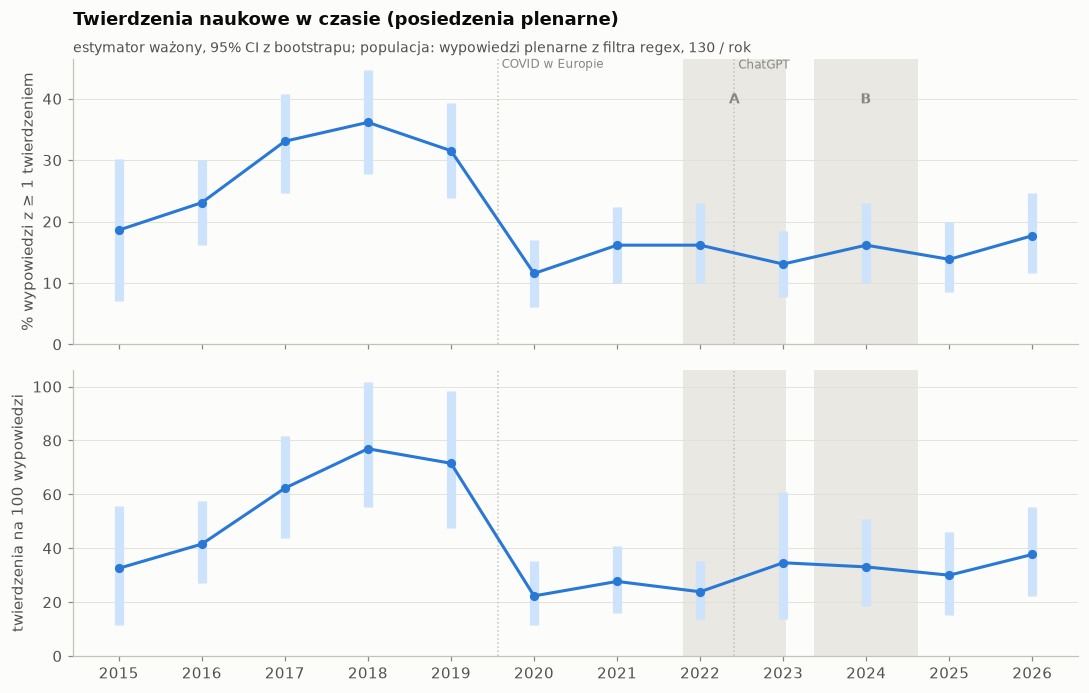

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
rok,,,
2015,43,18.6 [7.0; 30.2],32.6 [11.6; 55.8]
2016,130,23.1 [16.2; 30.0],41.5 [26.9; 57.7]
2017,130,33.1 [24.6; 40.8],62.3 [43.8; 81.5]
2018,130,36.2 [27.7; 44.6],76.9 [55.4; 101.5]
2019,130,31.5 [23.8; 39.2],71.5 [47.7; 98.5]
2020,130,11.5 [6.2; 16.9],22.3 [11.5; 35.4]
2021,130,16.2 [10.0; 22.3],27.7 [16.2; 40.8]
2022,130,16.2 [10.0; 23.1],23.8 [13.8; 35.4]
2023,130,13.1 [7.7; 18.5],34.6 [13.8; 60.8]


In [20]:
yr_y = R.bootstrap(df, "rok")
yr_n = R.bootstrap(df, "rok", y="n_twierdzen")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)
for ax, b, lab in [(a1, yr_y, "% wypowiedzi z ≥ 1 twierdzeniem"), (a2, yr_n, "twierdzenia na 100 wypowiedzi")]:
    ax.errorbar(b.index, b["p"] * 100, yerr=[(b["p"] - b["lo"]) * 100, (b["hi"] - b["p"]) * 100],
                fmt="o-", color=ACCENT, ecolor=ACCENT_LIGHT, elinewidth=6, capsize=0, ms=5)
    ax.set_ylim(0, None); ax.set_ylabel(lab); ax.grid(axis="x", visible=False)
    period_lines(ax, label=ax is a1)
a2.set_xticks(yr_y.index)
a1.set_title("Twierdzenia naukowe w czasie (posiedzenia plenarne)")
subtitle(a1, "estymator ważony, 95% CI z bootstrapu; populacja: wypowiedzi plenarne z filtra regex, 130 / rok")
fig.tight_layout()
save(fig, "llm_p_07_udzial_rok"); plt.show()
pd.DataFrame({"n": yr_y["n"], "z twierdzeniem [%]": fmt_ci(yr_y), "twierdzenia / 100 wyp.": fmt_ci(yr_n)}, index=yr_y.index)

Udział wypowiedzi z twierdzeniem jest najwyższy w latach 2017–2019 (32–36%), w 2020 r. spada do 12% i od tej pory waha się
między 13% a 18%. Przedział dla roku ma szerokość ok. ±7 pp, więc próg między 2019 a 2020 r. jest wyraźny,
a różnice między latami po 2020 r. mieszczą się w szumie. Rok 2015 to tylko półtora miesiąca (43 wypowiedzi).

#### Przebieg kwartalny 2015–2026

Ten sam wskaźnik kwartalnie, żeby zobaczyć przebieg w całym okresie i położenie okien A i B na tle trendu. Wagi są stałe
w obrębie roku, więc udział w kwartale to zwykły odsetek w próbie (95% przedział Wilsona). W kwartale jest średnio ok. 33
wypowiedzi z próby, więc pojedyncze punkty są niepewne; linia to średnia z trzech sąsiednich kwartałów ważona wielkością
populacji. Górny panel: liczba wypowiedzi w populacji filtra (dokładna, z korpusu), dolny: szacowana liczba twierdzeń.

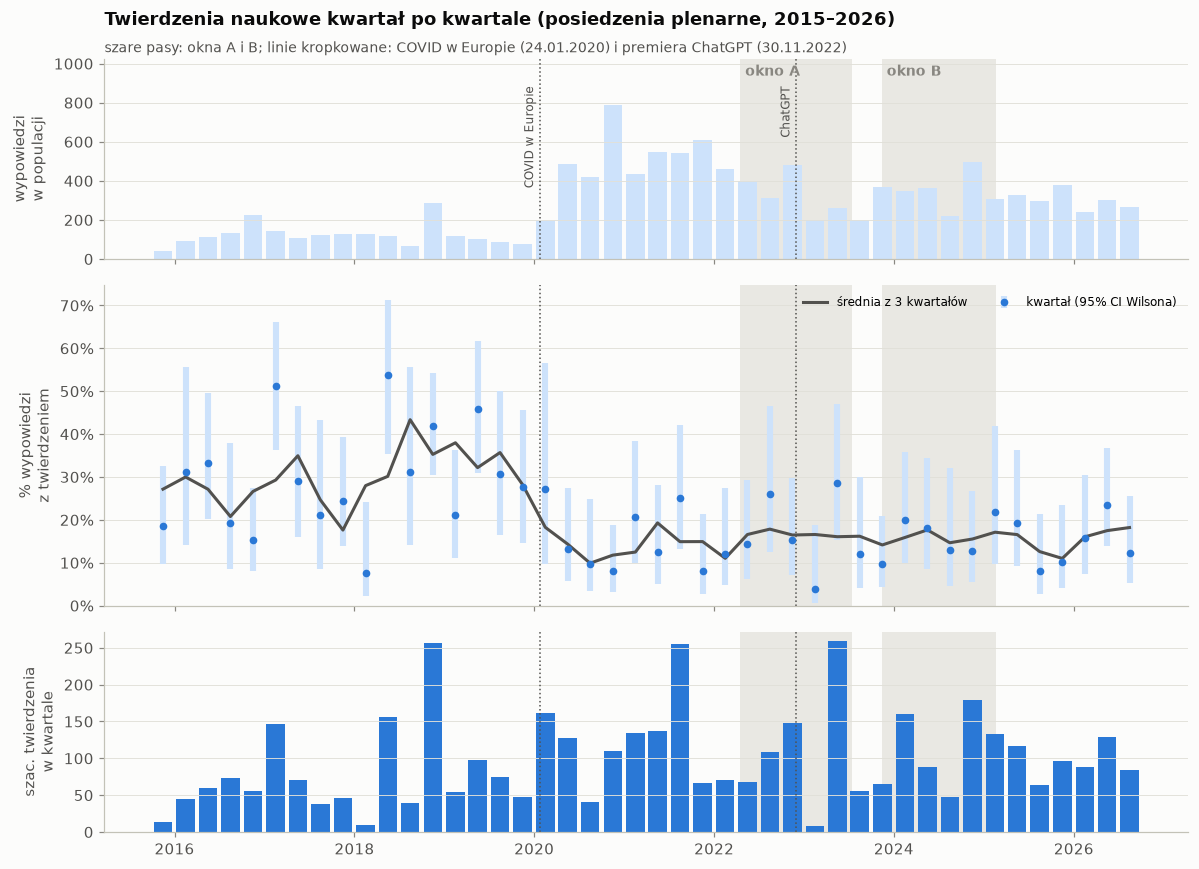

wypowiedzi z próby w kwartale: mediana 33, min 11 (2020Q1), max 62
najwyższe kwartały: 2018Q2 54% (n=26), 2017Q1 51% (n=39), 2019Q2 46% (n=37), 2018Q4 42% (n=62)
najniższe kwartały: 2023Q1 4% (n=26), 2018Q1 8% (n=26), 2020Q4 8% (n=50), 2021Q4 8% (n=37)


In [21]:
pd.plotting.register_matplotlib_converters()
df["kwartal"] = df["data"].dt.to_period("Q")
q = df.groupby("kwartal").agg(n=("y", "size"), k=("y", "sum"), tw=("n_twierdzen", "mean"))
q["N"] = filt.groupby(filt["data"].dt.to_period("Q")).size()
q["p"] = q["k"] / q["n"]
q["lo"], q["hi"] = wilson(q["k"], q["n"])
q["krocząca"] = (q["p"] * q["N"]).rolling(3, center=True, min_periods=2).sum() / q["N"].rolling(3, center=True, min_periods=2).sum()
q["szac. twierdzenia"] = q["N"] * q["tw"]
xq = q.index.to_timestamp() + pd.Timedelta(days=45)

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [1, 1.6, 1]})
a1.bar(xq, q["N"], width=75, color=ACCENT_LIGHT)
a1.set_ylabel("wypowiedzi\nw populacji"); a1.set_ylim(0, q["N"].max() * 1.3)
a2.errorbar(xq, q["p"], yerr=[q["p"] - q["lo"], q["hi"] - q["p"]], fmt="o", color=ACCENT, ecolor=ACCENT_LIGHT,
            elinewidth=4, capsize=0, ms=4, label="kwartał (95% CI Wilsona)")
a2.plot(xq, q["krocząca"], color=INK2, lw=2, label="średnia z 3 kwartałów")
a2.yaxis.set_major_formatter(PCT); a2.set_ylim(0, None); a2.set_ylabel("% wypowiedzi\nz twierdzeniem")
a2.legend(loc="upper right", ncol=2, fontsize=8)
a3.bar(xq, q["szac. twierdzenia"], width=75, color=ACCENT)
a3.set_ylabel("szac. twierdzenia\nw kwartale")
for ax in (a1, a2, a3):
    date_lines(ax, label=ax is a1)
    ax.grid(axis="x", visible=False)
a1.set_title("Twierdzenia naukowe kwartał po kwartale (posiedzenia plenarne, 2015–2026)")
subtitle(a1, "szare pasy: okna A i B; linie kropkowane: COVID w Europie (24.01.2020) i premiera ChatGPT (30.11.2022)")
fig.tight_layout()
save(fig, "llm_p_23_kwartalnie"); plt.show()
print(f"wypowiedzi z próby w kwartale: mediana {q['n'].median():.0f}, min {q['n'].min()} ({q['n'].idxmin()}), max {q['n'].max()}")
print("najwyższe kwartały: " + ", ".join(f"{i} {v:.0%} (n={n})" for i, v, n in q.nlargest(4, "p")[["p", "n"]].itertuples()))
print("najniższe kwartały: " + ", ".join(f"{i} {v:.0%} (n={n})" for i, v, n in q.nsmallest(4, "p")[["p", "n"]].itertuples()))

#### Okna A i B na osi czasu

Przybliżenie lat 2021–2025: kwartały jak wyżej, a dla każdego okna poziomy pas z oszacowaniem dla całego okna (ważony udział
i 95% przedział z bootstrapu, jak w 5.5). Pionowe linie oznaczają premierę ChatGPT i wybory w tym czasie.

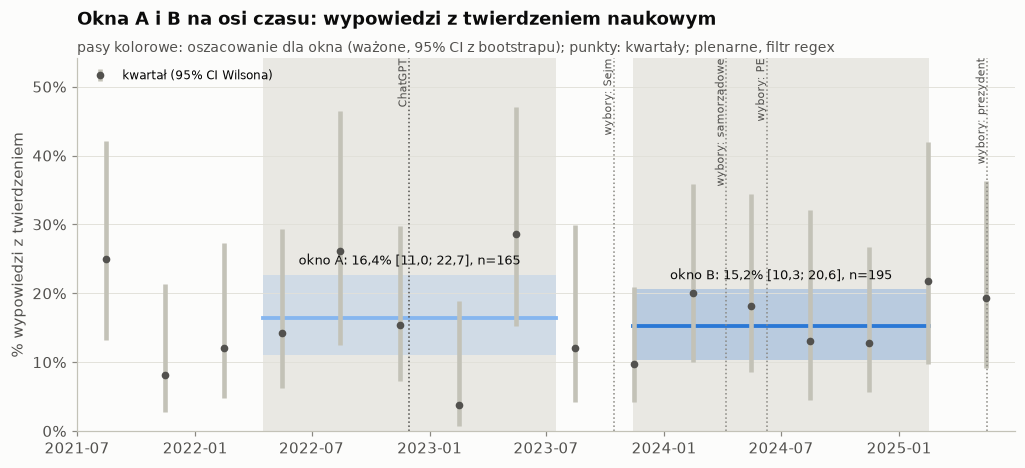

kwartal,2021Q3,2021Q4,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2
okno,–,–,–,A,A,A,A,A,–,B,B,B,B,B,B,–
N populacji,544,611,463,397,314,479,198,259,200,371,350,362,218,498,306,328
n próby,32,37,33,35,23,39,26,28,25,51,35,33,23,39,23,31
z twierdzeniem,8,3,4,5,6,6,1,8,3,5,7,6,3,5,5,6
z twierdzeniem [%],25.0,8.1,12.1,14.3,26.1,15.4,3.8,28.6,12.0,9.8,20.0,18.2,13.0,12.8,21.7,19.4


In [22]:
lo_d, hi_d = pd.Timestamp("2021-07-01"), pd.Timestamp("2025-06-30")
zoom = q[(xq >= lo_d) & (xq <= hi_d)]
xz = zoom.index.to_timestamp() + pd.Timedelta(days=45)
bw = R.bootstrap(df[df["okno"].notna()], "okno")
fig, ax = plt.subplots(figsize=(11, 4.4))
for k, (a, b) in WINDOWS.items():
    ax.axvspan(a, b, color=GRID, alpha=0.7, lw=0, zorder=0)
    ax.fill_between([a, b], bw.at[k, "lo"], bw.at[k, "hi"], color=WIN_KOLOR[k], alpha=0.25, lw=0)
    ax.plot([a, b], [bw.at[k, "p"]] * 2, color=WIN_KOLOR[k], lw=2.5)
    ax.text(a + (b - a) / 2, bw.at[k, "hi"] + 0.01,
            f"okno {k}: {100 * bw.at[k, 'p']:.1f}% [{100 * bw.at[k, 'lo']:.1f}; {100 * bw.at[k, 'hi']:.1f}], n={bw.at[k, 'n']}".replace(".", ","),
            ha="center", va="bottom", fontsize=8.5, color=INK)
ax.errorbar(xz, zoom["p"], yerr=[zoom["p"] - zoom["lo"], zoom["hi"] - zoom["p"]], fmt="o", color=INK2, ecolor=AXIS,
            elinewidth=3, capsize=0, ms=4, label="kwartał (95% CI Wilsona)")
events = [(CHATGPT, "ChatGPT")] + [(pd.Timestamp(d), f"wybory: {n}") for n, d in ELECTIONS if lo_d <= pd.Timestamp(d) <= hi_d] \
         + [(pd.Timestamp("2024-04-07"), "wybory: samorządowe")]
for d, lab in events:
    ax.axvline(d, color=INK2 if lab == "ChatGPT" else MUTED, ls=":", lw=1)
    ax.text(d, 1.0, " " + lab, transform=ax.get_xaxis_transform(), rotation=90, fontsize=7.5, color=INK2, va="top", ha="right")
ax.set_xlim(lo_d, hi_d); ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, max(zoom["hi"].max(), bw["hi"].max()) * 1.15)
ax.grid(axis="x", visible=False); ax.legend(loc="upper left", fontsize=8)
ax.set_ylabel("% wypowiedzi z twierdzeniem")
ax.set_title("Okna A i B na osi czasu: wypowiedzi z twierdzeniem naukowym")
subtitle(ax, "pasy kolorowe: oszacowanie dla okna (ważone, 95% CI z bootstrapu); punkty: kwartały; plenarne, filtr regex")
save(fig, "llm_p_24_okna_os_czasu"); plt.show()
win_of_q = pd.Series(sampling.window(pd.Series(xz)).to_numpy(), index=zoom.index).fillna("–")
zoom.assign(okno=win_of_q, **{"z twierdzeniem [%]": lambda x: (100 * x["p"]).round(1)})[
    ["okno", "N", "n", "k", "z twierdzeniem [%]"]].rename(columns={"N": "N populacji", "n": "n próby", "k": "z twierdzeniem"}).T

* **Przebieg.** W latach 2016–2019 średnia z trzech kwartałów waha się między ok. 18% a 43%. Na początku 2020 r. spada do
  ok. 10–20% i od tej pory, do 2026 r., zostaje na tym poziomie bez wyraźnego trendu. Załamanie przypada na kwartały,
  w których populacja filtra rośnie z ok. 100–200 do 400–800 wypowiedzi (słownik COVID, 5.2).
* **Pojedyncze kwartały** są bardzo niepewne (mediana 33 wypowiedzi z próby, przedziały ±15–20 pp): od 4% (2023Q1, n = 26)
  do 54% (2018Q2, n = 26). Skrajne wartości mieszczą się w szumie losowania i nie wskazują na zdarzenia.
* **Liczba twierdzeń** w kwartale skacze od kilku do ok. 260. Szczyty (2018Q4, 2021Q3, 2023Q2) to pojedyncze debaty
  z rozbudowanymi wypowiedziami, np. w 2023Q2 wypowiedź o kryzysie wodnym (4.5).
* **Okna na osi czasu.** Oba okna leżą w płaskiej części szeregu po 2020 r., a ich oszacowania prawie się pokrywają
  (16,4% i 15,2%). Wewnątrz okna A, które dzieli premiera ChatGPT, kwartały wahają się od 4% do 29% bez skoku po
  30.11.2022. Między oknami są wybory do Sejmu (15.10.2023) i początek X kadencji (13.11.2023, pierwszy dzień okna B).
  W B mieszczą się kampanie przed wyborami samorządowymi i do PE (5.10).
* Szereg kwartalny nie pokazuje zmiany poza 2020 r. Jeśli okna będą się różnić odsetkiem twierdzeń sprzecznych
  z konsensusem, nie będzie to wynikać z tego, że w jednym oknie pada więcej twierdzeń naukowych.

### 5.2 Wolumen i mianownik

W latach 2020–2022 populacja filtra jest 3–4 razy większa niż w 2016–2019. Najpierw szacowane liczby bezwzględne, potem
sprawdzenie, czy spadek udziału po 2020 r. wynika z samego mianownika: udział liczymy też w populacji bez wypowiedzi, które
przeszły filtr wyłącznie dzięki słownikowi COVID.

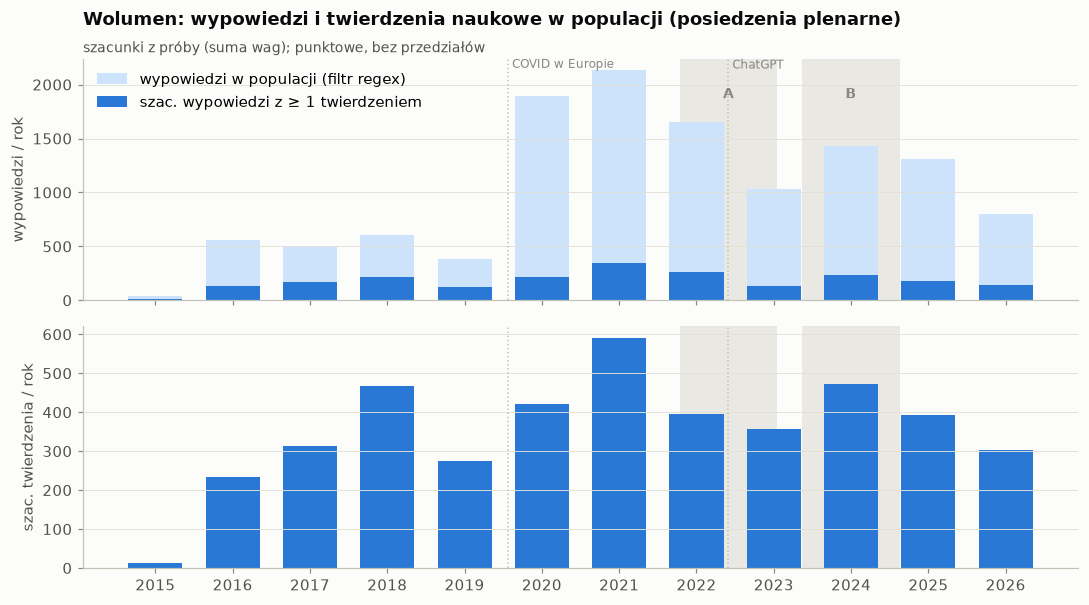

rok,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
N populacji,43,562,502,606,384,1893,2134,1653,1028,1428,1306,804
szac. wyp. z twierdzeniem,8,130,166,219,121,218,345,267,134,231,181,142
szac. twierdzenia,14,233,313,466,275,422,591,394,356,472,392,303


In [23]:
N_year = R.weighted_total(ones, "rok", y="one")
est_y = R.weighted_total(df, "rok")
est_n = R.weighted_total(df, "rok", y="n_twierdzen")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
a1.bar(N_year.index, N_year, color=ACCENT_LIGHT, width=0.7, label="wypowiedzi w populacji (filtr regex)")
a1.bar(est_y.index, est_y, color=ACCENT, width=0.7, label="szac. wypowiedzi z ≥ 1 twierdzeniem")
a1.legend(loc="upper left"); a1.set_ylabel("wypowiedzi / rok"); a1.grid(axis="x", visible=False)
period_lines(a1)
a2.bar(est_n.index, est_n, color=ACCENT, width=0.7)
a2.set_ylabel("szac. twierdzenia / rok"); a2.grid(axis="x", visible=False)
period_lines(a2, label=False)
a2.set_xticks(N_year.index)
a1.set_title("Wolumen: wypowiedzi i twierdzenia naukowe w populacji (posiedzenia plenarne)")
subtitle(a1, "szacunki z próby (suma wag); punktowe, bez przedziałów")
fig.tight_layout()
save(fig, "llm_p_08_wolumen"); plt.show()
pd.DataFrame({"N populacji": N_year.round().astype(int), "szac. wyp. z twierdzeniem": est_y.round().astype(int),
              "szac. twierdzenia": est_n.round().astype(int)}).T

Szacowana liczba wypowiedzi z twierdzeniem nie spada po 2020 r.: 120–220 rocznie w latach 2016–2019, 220–350 w latach
2020–2022, 130–230 później. Spadek udziału bierze się więc ze wzrostu mianownika, a nie z mniejszej liczby twierdzeń.

In [24]:
no_covid = [c for c in sampling.HIT_COLS if c != "covid"]
df["filtr_bez_covid"] = df[no_covid].gt(0).any(axis=1)
filt["filtr_bez_covid"] = filt[no_covid].gt(0).any(axis=1)
dnc = df[df["filtr_bez_covid"]]


def domain_table(by, order, labels):
    b_all, b_nc = R.bootstrap(df[df[by].notna()], by).loc[order], R.bootstrap(dnc[dnc[by].notna()], by).loc[order]
    return pd.DataFrame({
        "N populacji filtra": filt.groupby(by).size().loc[order],
        "% populacji tylko przez słownik COVID": 100 * (1 - filt.groupby(by)["filtr_bez_covid"].mean()).loc[order],
        "z twierdzeniem [%]: cały filtr": fmt_ci(b_all),
        "n: filtr bez COVID": b_nc["n"],
        "z twierdzeniem [%]: filtr bez COVID": fmt_ci(b_nc),
    }, index=order).rename(index=labels)


display(pd.concat({"okresy H1": domain_table("okres", PERIODS, PERIOD_LABEL),
                   "okna": domain_table("okno", list(WINDOWS), {k: f"okno {k}" for k in WINDOWS})}).round(1))
pd.DataFrame([{"porównanie": f"{lab_b} − {lab_a}", "cały filtr": fmt_diff(R.bootstrap_diff(d_all, by, a, b)),
               "filtr bez COVID": fmt_diff(R.bootstrap_diff(d_nc, by, a, b))}
              for by, a, b, lab_a, lab_b, d_all, d_nc in [
                  ("okres", "przed_covid", "covid", "przed COVID", "COVID", df, dnc),
                  ("okres", "przed_covid", "po_chatgpt", "przed COVID", "po ChatGPT", df, dnc),
                  ("okres", "covid", "po_chatgpt", "COVID", "po ChatGPT", df, dnc),
                  ("okno", "A", "B", "okno A", "okno B", df[df["okno"].notna()], dnc[dnc["okno"].notna()])]]).set_index("porównanie")

N populacji filtra  \
okresy H1 przed COVID                2183   
          COVID                      5447   
          po ChatGPT                 4713   
okna      okno A                     1710   
          okno B                     1966   

                       % populacji tylko przez słownik COVID  \
okresy H1 przed COVID                                    0.3   
          COVID                                         60.9   
          po ChatGPT                                    26.9   
okna      okno A                                        47.5   
          okno B                                        25.1   

                      z twierdzeniem [%]: cały filtr  n: filtr bez COVID  \
okresy H1 przed COVID              30.3 [26.3; 34.4]                 565   
          COVID                    14.4 [10.9; 18.1]                 144   
          po ChatGPT               15.2 [12.1; 18.5]                 385   
okna      okno A                   16.4 [11.0; 22.7]                  92   
          okno B                   15.2 [10.3; 20.6]                 135   

                      z twierdzeniem [%]: filtr bez COVID  
okresy H1 przed COVID                   30.3 [26.4; 34.4]  
          COVID                         27.7 [20.4; 35.4]  
          po ChatGPT                    19.1 [15.1; 23.2]  
okna      okno A                        21.7 [13.7; 30.7]  
          okno B                        18.9 [12.8; 25.7]

,cały filtr,filtr bez COVID
porównanie,,
COVID − przed COVID,-15.9 [-21.4; -10.5],-2.7 [-11.1; +6.0]
po ChatGPT − przed COVID,-15.1 [-19.9; -10.1],-11.3 [-17.1; -5.7]
po ChatGPT − COVID,+0.8 [-4.2; +5.7],-8.6 [-17.1; +0.1]
okno B − okno A,-1.2 [-9.3; +6.4],-2.8 [-13.5; +7.5]


* W okresie COVID 61% populacji filtra trafia do niej wyłącznie dzięki słownikowi COVID, w oknie A 48%, w oknie B 25%,
  po ChatGPT 27%. Słownik COVID łapie też wzmianki o pandemii długo po jej końcu.
* Bez tych wypowiedzi spadek w okresie COVID prawie znika: 30,3% przed COVID i 27,7% w okresie COVID (−2,7 pp [−11,1; +6,0]).
  Spadek „COVID − przed COVID” z całego filtra (−15,9 pp) to więc głównie efekt mianownika: w 2020–2022 filtr wpuszcza tysiące
  wypowiedzi o pandemii, które rzadko zawierają twierdzenie o COVID (5% wzmianek, sekcja 4.1).
* Spadek po ChatGPT zostaje: 19,1% wobec 30,3% (−11,3 pp [−17,1; −5,7]). Ten wynik nie wynika z wypowiedzi o COVID.
* Okna A i B nie różnią się w żadnym wariancie (−1,2 i −2,8 pp, przedziały obejmują zero).
* Definicja populacji (mianownika) zmienia wnioski o czasie bardziej niż sam instrument. To trzeba ustalić przed pomiarem
  sprzeczności z konsensusem.

### 5.3 Tematy w czasie

Szacowana liczba wypowiedzi z twierdzeniem z danego tematu, wg roku; w tabeli liczba wypowiedzi w próbie, na której opiera się szacunek.

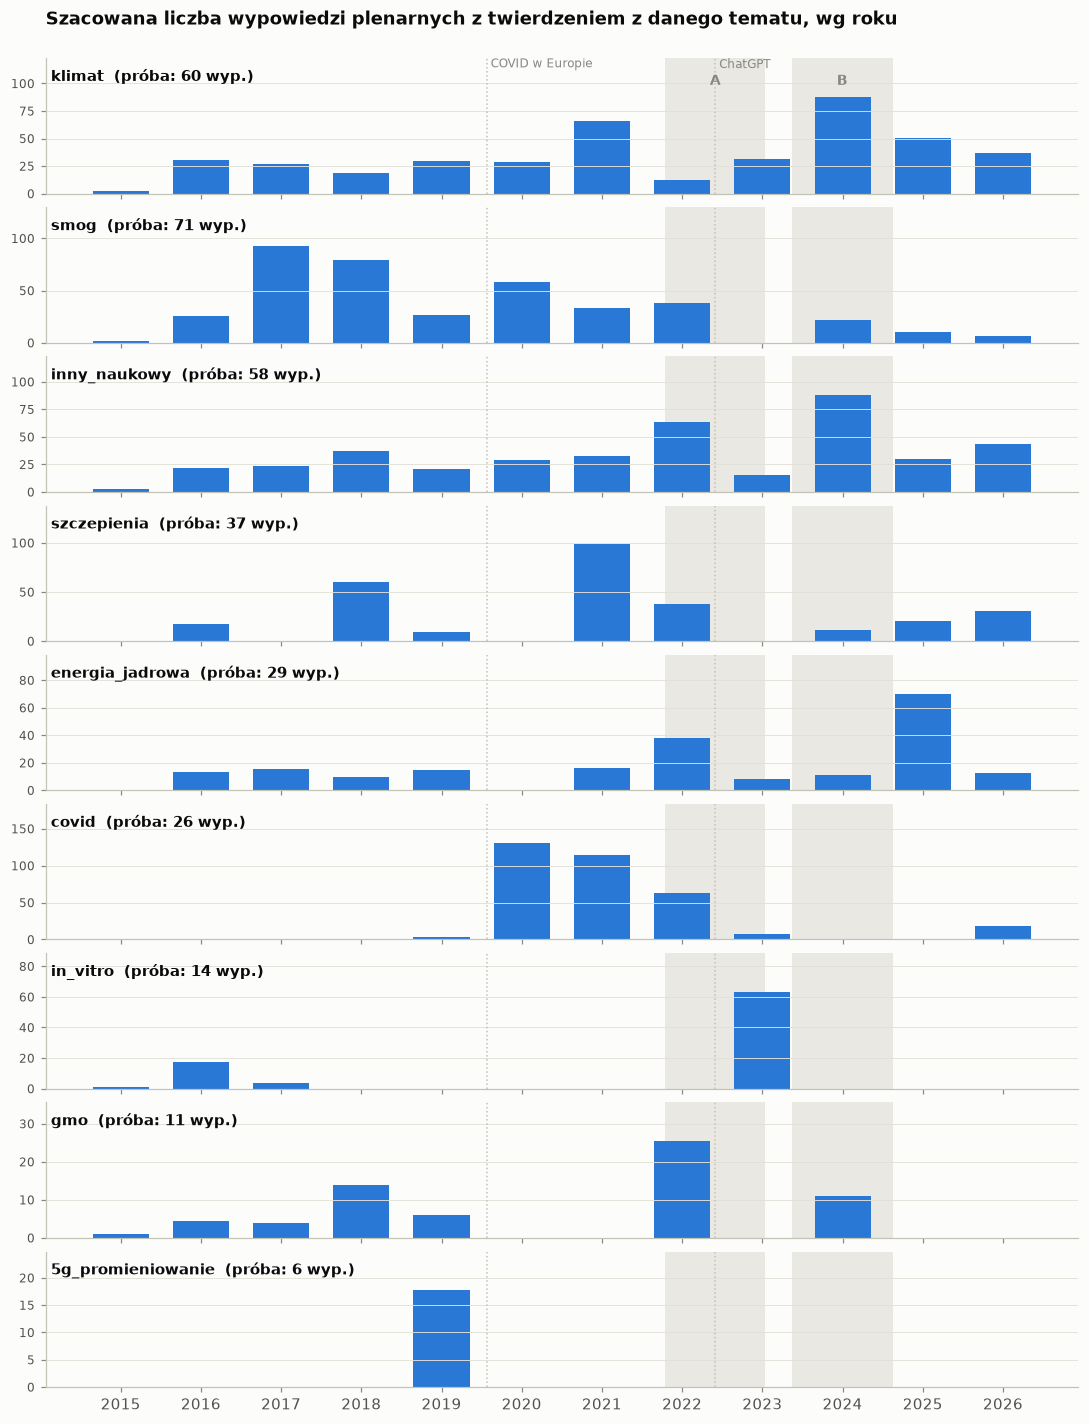

rok,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
klimat,2,7,7,4,10,2,4,1,4,8,5,6
smog,2,6,24,17,9,4,2,3,0,2,1,1
inny_naukowy,3,5,6,8,7,2,2,5,2,8,3,7
szczepienia,0,4,0,13,3,0,6,3,0,1,2,5
energia_jadrowa,0,3,4,2,5,0,1,3,1,1,7,2
covid,0,0,0,0,1,9,7,5,1,0,0,3
in_vitro,1,4,1,0,0,0,0,0,8,0,0,0
gmo,1,1,1,3,2,0,0,2,0,1,0,0
5g_promieniowanie,0,0,0,0,6,0,0,0,0,0,0,0


In [25]:
est_topic = pd.DataFrame({t: R.weighted_total(df, "rok", y=f"tw_{t}") for t in TOPICS_LLM})
fig, axes = plt.subplots(len(topics_tab), 1, figsize=(10, 1.45 * len(topics_tab)), sharex=True)
for ax, t in zip(axes, topics_tab.index):
    s = est_topic[t]
    ax.bar(s.index, s.values, color=ACCENT, width=0.7)
    period_lines(ax, label=ax is axes[0])
    ax.set_ylim(0, max(s.max() * 1.4, 1))
    ax.text(0.005, 0.92, f"{t}  (próba: {int(df[f'tw_{t}'].sum())} wyp.)", transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=INK, va="top")
    ax.tick_params(axis="y", labelsize=8); ax.grid(axis="x", visible=False)
axes[-1].set_xticks(est_topic.index)
axes[0].set_title("Szacowana liczba wypowiedzi plenarnych z twierdzeniem z danego tematu, wg roku")
fig.tight_layout(h_pad=0.4)
save(fig, "llm_p_09_tematy_w_czasie"); plt.show()
pd.DataFrame({t: df.groupby("rok")[f"tw_{t}"].sum() for t in topics_tab.index}).T

Smog występuje głównie w latach 2017–2018, szczepienia w 2018 r. (debata nad obywatelskim projektem dotyczącym obowiązku
szczepień), 5G tylko w 2019 r., COVID w latach 2020–2022, in vitro w 2016 i 2023 r. Klimat jest rozłożony w czasie (1–10
wypowiedzi rocznie w próbie). Tematy pojawiają się więc falami, przy konkretnych ustawach i debatach.

### 5.4 Okna A i B: populacja (cały korpus plenarny)

Liczby z całego korpusu: ile wypowiedzi jest w każdym oknie, ile przechodzi filtr regex, jaką część populacji filtra pokrywa próba
i jak zmienia się skład mówców. Poniżej wzmianki o tematach (≥ 1 i ≥ 3 trafienia słownika).

In [26]:
wm = mer[mer["okno"].notna()]
wf = filt[filt["okno"].notna()]
g_m, g_f = wm.groupby("okno"), wf.groupby("okno")
win_pop = pd.DataFrame({
    "dni posiedzeń": g_m["data"].nunique(),
    "wypowiedzi merytoryczne": g_m.size(),
    "filtr regex": g_f.size(),
    "% w filtrze": 100 * g_f.size() / g_m.size(),
    "próba LLM": df[df["okno"].notna()].groupby("okno").size(),
    "% populacji filtra w próbie": 100 * df[df["okno"].notna()].groupby("okno").size() / g_f.size(),
    "mówcy (filtr)": g_f["mowca"].nunique(),
    "mediana słów (filtr)": g_f["liczba_slow"].median(),
    "% rząd (filtr)": 100 * g_f["rola"].apply(lambda s: s.eq("rząd").mean()),
    "% inni (filtr)": 100 * g_f["rola"].apply(lambda s: s.eq("inni").mean()),
    "% PiS i Konfederacja, posłowie (filtr)": 100 * wf["rola"].eq("poseł").mul(wf["blok"].isin(RIGHT)).groupby(wf["okno"]).mean(),
})
win_pop.round(1).T

okno,A,B
dni posiedzeń,64.0,86.0
wypowiedzi merytoryczne,16392.0,16404.0
filtr regex,1710.0,1966.0
% w filtrze,10.4,12.0
próba LLM,165.0,195.0
% populacji filtra w próbie,9.6,9.9
mówcy (filtr),388.0,414.0
mediana słów (filtr),317.0,250.0
% rząd (filtr),13.9,9.5
% inni (filtr),1.9,1.3


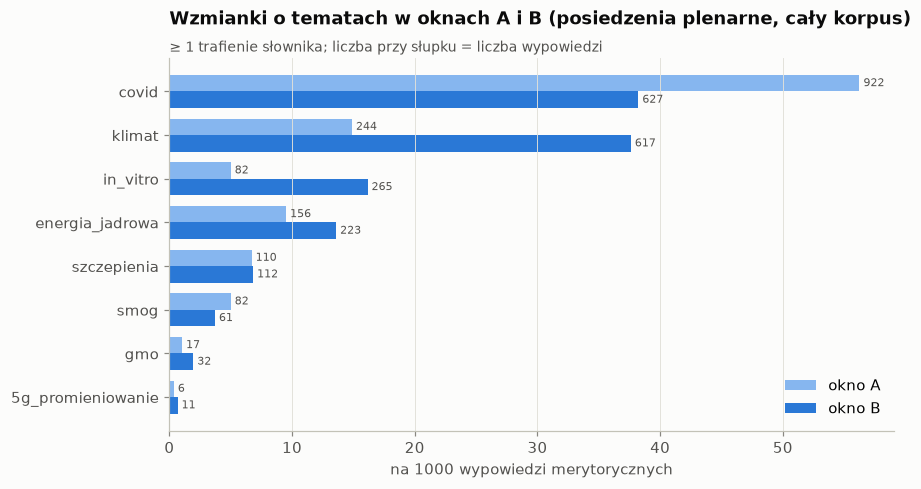

≥ 1        ≥ 3     
                      A     B    A    B
szczepienia         110   112   33   43
covid               922   627  150  114
klimat              244   617   32  145
energia_jadrowa     156   223   39   44
gmo                  17    32    4    9
5g_promieniowanie     6    11    0    4
smog                 82    61   17   12
in_vitro             82   265   16   90
dowolny temat      1503  1756  282  447

In [27]:
tab = {}
for thr in (1, T.PROG):
    for k in WINDOWS:
        hit = wm[wm["okno"] == k][TOPICS].ge(thr)
        tab[(f"≥ {thr}", k)] = pd.concat([hit.sum(), pd.Series({"dowolny temat": hit.any(axis=1).sum()})])
win_topics = pd.DataFrame(tab)
rate = {k: wm[wm["okno"] == k][TOPICS].ge(1).mean() * 1000 for k in WINDOWS}

order = win_topics[("≥ 1", "B")].drop("dowolny temat").sort_values().index
yy, h = np.arange(len(order)), 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for j, k in enumerate(WINDOWS):
    v = rate[k].loc[order]
    ax.barh(yy + (0.5 - j) * h, v, height=h, color=WIN_KOLOR[k], label=f"okno {k}")
    for yi, (val, n) in enumerate(zip(v, win_topics.loc[order, ("≥ 1", k)])):
        ax.text(val, yi + (0.5 - j) * h, f" {n}", va="center", fontsize=7.5, color=INK2)
ax.set_yticks(yy, order); ax.grid(axis="y", visible=False)
ax.set_xlabel("na 1000 wypowiedzi merytorycznych")
ax.legend(loc="lower right")
ax.set_title("Wzmianki o tematach w oknach A i B (posiedzenia plenarne, cały korpus)")
subtitle(ax, "≥ 1 trafienie słownika; liczba przy słupku = liczba wypowiedzi")
save(fig, "llm_p_10_okna_tematy"); plt.show()
win_topics

* Okna mają prawie tyle samo wypowiedzi merytorycznych (16 392 i 16 404), choć w B jest więcej dni posiedzeń (86 wobec 64).
  Filtr regex przepuszcza 1 710 (A) i 1 966 (B) wypowiedzi; próba obejmuje ok. 10% z nich (165 i 195).
* Wypowiedzi z filtra są w B krótsze (mediana 250 słów wobec 317), rząd mówi mniej (9,5% wobec 13,9%), a posłowie PiS
  i Konfederacji więcej (44% wobec 37%). Okna różnią się więc składem, nie tylko czasem.
* Klimat rośnie najbardziej: 244 → 617 wzmianek, 32 → 145 wypowiedzi tematycznych. COVID słabnie (922 → 627), in vitro rośnie
  (82 → 265), ale w 59% z dwóch dni posiedzeń (22 i 29.11.2023).

### 5.5 Okna A i B: twierdzenia naukowe (próba LLM)

Udział wypowiedzi z twierdzeniem naukowym i liczba twierdzeń na 100 wypowiedzi w oknach, osobno dla wszystkich mówców, posłów
i posłów PiS i Konfederacji. Różnica = B − A, 95% przedział z bootstrapu w warstwach roku.

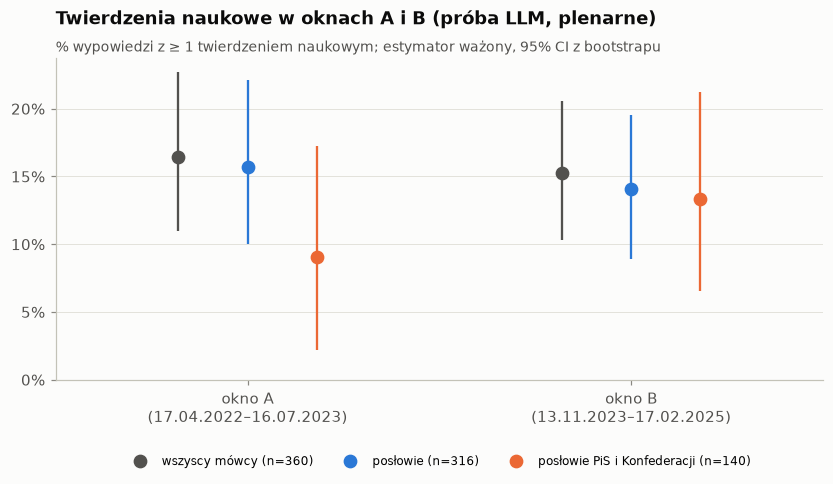

mówcy,wszyscy mówcy,posłowie,posłowie PiS i Konfederacji
n: A,165,142,57
n: B,195,174,83
z twierdzeniem [%]: A,16.4 [11.0; 22.7],15.7 [10.1; 22.1],9.1 [2.2; 17.3]
z twierdzeniem [%]: B,15.2 [10.3; 20.6],14.1 [8.9; 19.6],13.4 [6.5; 21.2]
różnica [pp],-1.2 [-9.3; +6.4],-1.6 [-10.0; +5.9],+4.3 [-6.2; +15.0]
twierdzenia / 100: A,33.9 [18.9; 53.6],32.1 [16.6; 53.4],10.4 [2.3; 19.5]
twierdzenia / 100: B,31.1 [18.7; 45.7],24.0 [14.0; 34.8],22.6 [10.3; 36.6]
różnica (twierdzenia / 100),-2.8 [-25.6; +17.6],-8.1 [-30.3; +10.8],+12.2 [-3.1; +28.2]


In [28]:
dw = df[df["okno"].notna()]


def compare(d, by, a, b, labels):
    rows, pts = [], {}
    for name, s in subsets_of(d).items():
        p = R.bootstrap(s, by).loc[[a, b]]
        q = R.bootstrap(s, by, y="n_twierdzen").loc[[a, b]]
        pts[name] = p
        rows.append({"mówcy": name, f"n: {labels[a]}": p.at[a, "n"], f"n: {labels[b]}": p.at[b, "n"],
                     f"z twierdzeniem [%]: {labels[a]}": fmt_ci(p.loc[[a]])[0],
                     f"z twierdzeniem [%]: {labels[b]}": fmt_ci(p.loc[[b]])[0],
                     "różnica [pp]": fmt_diff(R.bootstrap_diff(s, by, a, b)),
                     f"twierdzenia / 100: {labels[a]}": fmt_ci(q.loc[[a]])[0],
                     f"twierdzenia / 100: {labels[b]}": fmt_ci(q.loc[[b]])[0],
                     "różnica (twierdzenia / 100)": fmt_diff(R.bootstrap_diff(s, by, a, b, y="n_twierdzen"))})
    return pd.DataFrame(rows).set_index("mówcy").T, pts


def compare_plot(pts, order, ticks, title, name):
    fig, ax = plt.subplots(figsize=(9, 3.8))
    for k, (nm, b) in enumerate(pts.items()):
        b = b.loc[order]
        x = np.arange(len(order)) + (k - 1) * 0.18
        ax.errorbar(x, b["p"], yerr=[b["p"] - b["lo"], b["hi"] - b["p"]], fmt="o", color=SUBSETS[nm], ecolor=SUBSETS[nm],
                    elinewidth=1.5, capsize=0, ms=8, label=f"{nm} (n={int(b['n'].sum())})")
    ax.set_xticks(range(len(order)), ticks); ax.set_xlim(-0.5, len(order) - 0.5)
    ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=8)
    ax.set_title(title)
    subtitle(ax, "% wypowiedzi z ≥ 1 twierdzeniem naukowym; estymator ważony, 95% CI z bootstrapu")
    save(fig, name); plt.show()


tab_w, pts_w = compare(dw, "okno", "A", "B", {"A": "A", "B": "B"})
compare_plot(pts_w, ["A", "B"], [WINDOW_TICK[k] for k in WINDOWS], "Twierdzenia naukowe w oknach A i B (próba LLM, plenarne)",
             "llm_p_11_okna_udzial")
tab_w

* Twierdzenie naukowe ma 16,4% wypowiedzi z filtra w A [11,0; 22,7] i 15,2% w B [10,3; 20,6]; różnica −1,2 pp [−9,3; +6,4].
  U samych posłów −1,6 pp [−10,0; +5,9].
* Posłowie PiS i Konfederacji: 9,1% w A (n = 57) i 13,4% w B (n = 83), różnica +4,3 pp [−6,2; +15,0]; liczba twierdzeń
  na 100 wypowiedzi rośnie z 10 do 23 (+12,2 [−3,1; +28,2]). Kierunek jest odwrotny niż dla ogółu, ale przedziały obejmują zero.
* Przy 165 i 195 wypowiedziach przedział różnicy ma ok. ±8 pp. Wykryje różnicę
  rzędu 10 pp, ale nie mniejszą.
* Wynik dotyczy etapu A: tego, jak często pada twierdzenie naukowe, a nie tego, czy jest sprzeczne z konsensusem.

#### Twierdzenia wg tematu w oknach

Trzy liczby dla każdego tematu i okna: liczba wypowiedzi z twierdzeniem z tematu w próbie, szacunek dla populacji filtra z samej
próby okna oraz przeliczenie (wzmianki o temacie w oknie razy odsetek wzmianek z twierdzeniem z tematu w całej próbie
2015–2026). Szacunek z próby okna nie zakłada stałości w czasie, ale przy kilku wypowiedziach jest bardzo niepewny; przeliczenie
jest stabilniejsze, ale zakłada, że odsetek się nie zmienia.

In [29]:
TW = [f"tw_{t}" for t in topics_tab.index]
conv = pd.Series({t: wshare(df[df[t] >= 1], f"tw_{t}") for t in TOPICS})
win_t = pd.concat({
    "próba: wypowiedzi z twierdzeniem z tematu": pd.DataFrame({k: dw.loc[dw["okno"] == k, TW].sum().set_axis(topics_tab.index)
                                                              for k in WINDOWS}),
    "szacunek z próby okna (populacja filtra)": pd.DataFrame({k: [totals(dw, "okno", f"tw_{t}").get(k, 0) for t in topics_tab.index]
                                                             for k in WINDOWS}, index=topics_tab.index),
    "przeliczenie: wzmianki w oknie × % z twierdzeniem (2015–2026)": pd.DataFrame(
        {k: win_topics.loc[TOPICS, ("≥ 1", k)] * conv for k in WINDOWS}).reindex(topics_tab.index),
}, axis=1)
display(win_t.round(0))
print("% wzmianek z twierdzeniem z tematu (cała próba): " + ", ".join(f"{t} {100 * v:.0f}%" for t, v in conv.items()))

próba: wypowiedzi z twierdzeniem z tematu     \
                                                          A  B   
klimat                                                    5  8   
smog                                                      3  2   
inny_naukowy                                              6  8   
szczepienia                                               1  3   
energia_jadrowa                                           3  1   
covid                                                     4  0   
in_vitro                                                  3  5   
gmo                                                       2  1   
5g_promieniowanie                                         0  0   

                  szacunek z próby okna (populacja filtra)        \
                                                         A     B   
klimat                                                44.0  88.0   
smog                                                  38.0  22.0   
inny_naukowy                                          66.0  88.0   
szczepienia                                           13.0  31.0   
energia_jadrowa                                       33.0  11.0   
covid                                                 45.0   0.0   
in_vitro                                              23.0  39.0   
gmo                                                   25.0  11.0   
5g_promieniowanie                                      0.0   0.0   

                  przeliczenie: wzmianki w oknie × % z twierdzeniem (2015–2026)  \
                                                                              A   
klimat                                                                     36.0   
smog                                                                       31.0   
inny_naukowy                                                                NaN   
szczepienia                                                                23.0   
energia_jadrowa                                                            17.0   
covid                                                                      52.0   
in_vitro                                                                   11.0   
gmo                                                                         4.0   
5g_promieniowanie                                                           1.0   

                         
                      B  
klimat             92.0  
smog               23.0  
inny_naukowy        NaN  
szczepienia        23.0  
energia_jadrowa    25.0  
covid              35.0  
in_vitro           37.0  
gmo                 7.0  
5g_promieniowanie   2.0

% wzmianek z twierdzeniem z tematu (cała próba): szczepienia 21%, covid 6%, klimat 15%, energia_jadrowa 11%, gmo 23%, 5g_promieniowanie 16%, smog 38%, in_vitro 14%


* W próbie z okien każdy temat to 0–8 wypowiedzi z twierdzeniem. Najwięcej klimat (5 i 8) i `inny_naukowy` (6 i 8).
* Dla klimatu obie metody dają podobny wynik: w populacji filtra ok. 40 wypowiedzi z twierdzeniem o klimacie w A i ok. 90 w B.
  Dla pozostałych tematów to od kilku do ok. 50 wypowiedzi w oknie, a metody różnią się nawet dwukrotnie (np. in vitro w A: 23
  i 11), bo szacunek z próby okna opiera się na 1–5 wypowiedziach.
* Klimat w B daje więc rząd 100 wypowiedzi z twierdzeniem na całą populację filtra. Jeśli sprzeczne z konsensusem są
  pojedyncze procenty twierdzeń, w jednym oknie będzie ich kilka.

#### Wszystkie twierdzenia z próby w oknach A i B

Pełna lista, żeby było widać, jaki materiał trafi do etapu B. `kto` to blok posła, `rząd` albo `inni`.

In [30]:
clw = cl[cl["okno"].notna()].copy()
clw["kto"] = who(clw)
print(f"twierdzenia w oknach (próba): A {int((clw['okno'] == 'A').sum())}, B {int((clw['okno'] == 'B').sum())}; "
      f"wypowiedzi z twierdzeniem: A {clw.loc[clw['okno'] == 'A', 'wypowiedz_id'].nunique()}, "
      f"B {clw.loc[clw['okno'] == 'B', 'wypowiedz_id'].nunique()}")
with pd.option_context("display.max_rows", 300):
    display(clw.sort_values(["okno", "temat", "data"])[["okno", "data", "kto", "temat", "atrybucja", "twierdzenie"]]
            .assign(data=lambda x: x["data"].dt.strftime("%Y-%m-%d")).reset_index(drop=True))

twierdzenia w oknach (próba): A 60, B 59; wypowiedzi z twierdzeniem: A 27, B 29


,okno,data,kto,temat,atrybucja,twierdzenie
0,A,2023-05-24,Lewica,brak,cytat_zgoda,"Długotrwała praca przed ekranem negatywnie wpływa na zdrowie fizyczne i psychiczne, powodując m.in. przeciążenie poznawcze, bóle głowy, zmęczenie oczu, niepokój i wypalenie zawodowe."
1,A,2022-06-22,Polska 2050,covid,wlasne,"Po COVID-19 30% dzieci ma objawy agresji, a 40% jest zagrożonych depresją."
2,A,2022-07-20,KO,covid,wlasne,Następuje wzrost zachorowań na COVID-19.
3,A,2022-07-20,KO,covid,wlasne,"Fala COVID-19 przyspieszyła wcześniej niż przewidywano, powodując wzrost zakażeń."
4,A,2022-07-20,KO,covid,wlasne,Testy antygenowe na COVID-19 są mało dokładne.
5,A,2022-11-16,Konfederacja,covid,wlasne,"Zgony nadmiarowe podczas pandemii COVID-19 nie były spowodowane przez wirusa, lecz przez inne czynniki, takie jak niewydolność systemu opieki zdrowotnej."
6,A,2023-03-07,Konfederacja,covid,wlasne,Maseczki jednorazowe po COVID-19 stanowią znaczącą część odpadów z tworzyw sztucznych.
7,A,2022-09-15,KO,energia_jadrowa,wlasne,Termomodernizacja i docieplenie budynków mogą zmniejszyć rachunki za energię nawet o 60%.
8,A,2022-10-26,Konfederacja,energia_jadrowa,wlasne,Potrzebne są badania potwierdzające skuteczność i nieszkodliwość paliw E10 dla silników.
9,A,2023-07-06,KO,energia_jadrowa,wlasne,Energia z wiatru i słońca jest 5 razy tańsza niż energia z węgla.


* W oknach jest 60 (A) i 59 (B) twierdzeń w 27 i 29 wypowiedziach. Są silnie skupione: jedna wypowiedź posłanki KO o kryzysie
  wodnym (25.05.2023) daje 14 z 60 twierdzeń okna A. W B debata o in vitro (22.11.2023) daje 9 twierdzeń, a dwie wypowiedzi
  przedstawicieli rządu z 10.10.2024 (choroba niebieskiego języka, lasy) razem 11.
* Etykieta tematu znów się myli: jako `klimat` oznaczone są choroby układu krążenia (A i B), jako `szczepienia` umieralność
  na nowotwory, jako `smog` dieta i palenie papierosów.
* Na liście są twierdzenia, które etap B mógłby uznać za sprzeczne z konsensusem: „ponad 200 badań naukowych wykazuje klimatyczne
  oszustwo” (Konfederacja, B), „zmiany klimatu występowały zawsze” i „naukowcy spierają się o wpływ człowieka na klimat” (PiS, B),
  „zgony nadmiarowe w pandemii nie były spowodowane przez wirusa” (Konfederacja, A). Ich zgodności z konsensusem tu nie oceniamy.
* Jedna wypowiedź pokazuje problem atrybucji: poseł Konfederacji (20.11.2024) przytacza „przekonanie, że emisja CO2 powoduje globalne
  ocieplenie”, nazywa je „mitologią”, a LLM zapisuje je jako jego własne twierdzenie (`wlasne`) zamiast polemiki. Etap B oceniłby
  wtedy twierdzenie zgodne z konsensusem, choć mówca je odrzuca.

### 5.6 Okna A i B: kto mówi o tematach naukowych

Lewy panel: cały korpus, wypowiedzi ze wzmianką o dowolnym temacie na 1000 wypowiedzi grupy. Prawy panel: próba LLM,
ważony odsetek wypowiedzi z twierdzeniem w grupie; liczności grup to kilkanaście–kilkadziesiąt.

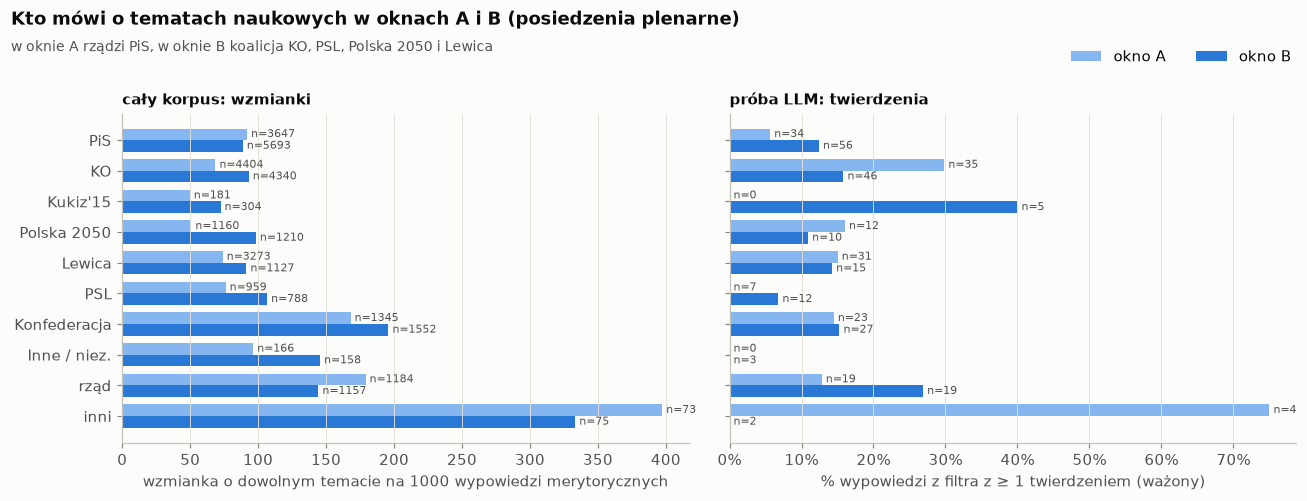

A                                        B  \
             merytoryczne wzmianka na 1000 klimat ≥ 1 merytoryczne   
PiS                  3647             91.9         53         5693   
KO                   4404             68.6         40         4340   
Kukiz'15              181             49.7          2          304   
Polska 2050          1160             50.9         12         1210   
Lewica               3273             73.9         39         1127   
PSL                   959             76.1         12          788   
Konfederacja         1345            168.0         49         1552   
Inne / niez.          166             96.4          0          158   
rząd                 1184            179.1         35         1157   
inni                   73            397.3          2           75   

                                          
             wzmianka na 1000 klimat ≥ 1  
PiS                      88.7        193  
KO                       93.1         84  
Kukiz'15                 72.4         12  
Polska 2050              98.3         35  
Lewica                   91.4         27  
PSL                     106.6         35  
Konfederacja            195.9        164  
Inne / niez.            145.6         13  
rząd                    144.3         51  
inni                    333.3          3

A                            B                   
             n (próba) z twierdzeniem [%] n (próba) z twierdzeniem [%]
kto                                                                   
PiS               34.0                5.6        56               12.4
KO                35.0               29.8        46               15.8
Kukiz'15           NaN                NaN         5               40.0
Polska 2050       12.0               16.0        10               10.9
Lewica            31.0               15.0        15               14.3
PSL                7.0                0.0        12                6.8
Konfederacja      23.0               14.5        27               15.3
Inne / niez.       NaN                NaN         3                0.0
rząd              19.0               12.8        19               26.9
inni               4.0               75.0         2                0.0

In [31]:
grp = who(wm)
GROUPS_W = [b for b in BLOKI if b in set(grp)] + ["rząd", "inni"]
any_topic = wm[TOPICS].ge(1).any(axis=1)
bloc_corpus = {}
for k in WINDOWS:
    m = wm["okno"] == k
    bloc_corpus[k] = pd.DataFrame({"merytoryczne": wm[m].groupby(grp[m]).size(),
                                   "wzmianka na 1000": 1000 * any_topic[m].groupby(grp[m]).mean(),
                                   "klimat ≥ 1": wm.loc[m, "klimat"].ge(1).groupby(grp[m]).sum()})
bloc_corpus = pd.concat(bloc_corpus, axis=1).reindex(GROUPS_W).fillna(0)
bloc_llm = pd.concat({k: pd.DataFrame({"n (próba)": dw[dw["okno"] == k].groupby("kto").size(),
                                       "z twierdzeniem [%]": 100 * R.weighted_share(dw[dw["okno"] == k], "kto")})
                      for k in WINDOWS}, axis=1).reindex(GROUPS_W)

yy, h = np.arange(len(GROUPS_W)), 0.38
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for j, k in enumerate(WINDOWS):
    for ax, v, n in [(axes[0], bloc_corpus[(k, "wzmianka na 1000")], bloc_corpus[(k, "merytoryczne")]),
                     (axes[1], bloc_llm[(k, "z twierdzeniem [%]")].fillna(0) / 100, bloc_llm[(k, "n (próba)")].fillna(0))]:
        ax.barh(yy + (j - 0.5) * h, v, height=h, color=WIN_KOLOR[k], label=f"okno {k}")
        for yi, (val, nn) in enumerate(zip(v, n)):
            ax.text(val, yi + (j - 0.5) * h, f" n={int(nn)}", va="center", fontsize=7, color=INK2)
axes[0].set_yticks(yy, GROUPS_W); axes[0].invert_yaxis()
axes[0].set_xlabel("wzmianka o dowolnym temacie na 1000 wypowiedzi merytorycznych")
axes[0].set_title("cały korpus: wzmianki", fontsize=10, pad=6)
axes[1].set_xlabel("% wypowiedzi z filtra z ≥ 1 twierdzeniem (ważony)"); axes[1].xaxis.set_major_formatter(PCT)
axes[1].set_title("próba LLM: twierdzenia", fontsize=10, pad=6)
for ax in axes:
    ax.grid(axis="y", visible=False)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, bbox_to_anchor=(0.99, 0.93))
fig.suptitle("Kto mówi o tematach naukowych w oknach A i B (posiedzenia plenarne)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.9, "w oknie A rządzi PiS, w oknie B koalicja KO, PSL, Polska 2050 i Lewica", fontsize=9, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.92))
save(fig, "llm_p_12_okna_bloki"); plt.show()
display(bloc_corpus.astype({c: int for c in bloc_corpus.columns if c[1] != "wzmianka na 1000"}).round(1))
bloc_llm.round(1)

* Cały korpus: Konfederacja w obu oknach najczęściej wspomina tematy ze słowników (168 i 196 na 1000 wypowiedzi), pozostałe kluby
  50–107 (poza nielicznymi posłami niezrzeszonymi). Wzmianki o klimacie rosną najbardziej u PiS (53 → 193) i Konfederacji (49 → 164).
* Próba LLM: u posłów PiS twierdzenie ma 6% wypowiedzi z filtra w A (rządzący, n = 34) i 12% w B (opozycja, n = 56); u KO 30% (n = 35)
  i 16% (n = 46); u Konfederacji 15% w obu oknach (n = 23 i 27). Przy takich licznościach różnice między oknami w obrębie bloku
  nie są rozstrzygające, ale pokazują, że zmiana roli (rząd / opozycja) może działać na blok inaczej niż na ogół posłów.
* W B wypowiedzi członków rządu (z KO i koalicji) liczymy jako rolę „rząd”, nie jako blok; twierdzenie ma 27% wypowiedzi rządu
  w B wobec 13% w A (n = 19 w obu oknach).

### 5.7 Język podważający naukę (marker `sceptycyzm`)

Najpierw liczby z całego korpusu w oknach. Potem: co LLM znajduje
w wypowiedziach z markerem w całej próbie 2015–2026, czyli czy język podważający naukę idzie w parze z twierdzeniami naukowymi.

In [32]:
sk_c = pd.DataFrame({k: {"wypowiedzi merytoryczne": int((wm["okno"] == k).sum()),
                         "z markerem sceptycyzm": int(((wm["okno"] == k) & wm["sceptycyzm"].ge(1)).sum()),
                         "w tym ze wzmianką o klimacie": int(((wm["okno"] == k) & wm["sceptycyzm"].ge(1) & wm["klimat"].ge(1)).sum()),
                         "w tym Konfederacja": int(((wm["okno"] == k) & wm["sceptycyzm"].ge(1) & grp.eq("Konfederacja")).sum())}
                     for k in WINDOWS})
display(Markdown("**Cały korpus (plenarne): wypowiedzi z markerem w oknach**"), sk_c)

df["marker_sceptycyzm"] = np.where(df["sceptycyzm"] >= 1, "z markerem", "bez markera")
sk = df[df["sceptycyzm"] >= 1]
sk_cand = cand[cand["wypowiedz_id"].isin(sk["wypowiedz_id"])]
display(Markdown(f"**Próba LLM (2015–2026): {len(sk)} wypowiedzi z markerem**"),
        pd.DataFrame({"n": df.groupby("marker_sceptycyzm").size(),
                      "z twierdzeniem [%] (bez wag)": 100 * df.groupby("marker_sceptycyzm")["y"].mean(),
                      "twierdzenia / 100 (bez wag)": 100 * df.groupby("marker_sceptycyzm")["n_twierdzen"].mean()}).round(1),
        Markdown("**Rodzaje kandydatów w wypowiedziach z markerem (% kandydatów)**"),
        (sk_cand["rodzaj"].value_counts(normalize=True) * 100).round(1).to_frame("%").T)
sk_claims = cl[cl["wypowiedz_id"].isin(sk["wypowiedz_id"])].assign(kto=lambda x: who(x))
sk_claims[["data", "kto", "temat", "atrybucja", "twierdzenie"]].assign(data=lambda x: x["data"].dt.strftime("%Y-%m-%d"))

**Cały korpus (plenarne): wypowiedzi z markerem w oknach**

,A,B
wypowiedzi merytoryczne,16392,16404
z markerem sceptycyzm,30,61
w tym ze wzmianką o klimacie,2,37
w tym Konfederacja,22,46


**Próba LLM (2015–2026): 25 wypowiedzi z markerem**

,n,z twierdzeniem [%] (bez wag),twierdzenia / 100 (bez wag)
marker_sceptycyzm,,,
bez markera,1448,20.5,41.4
z markerem,25,32.0,60.0


**Rodzaje kandydatów w wypowiedziach z markerem (% kandydatów)**

rodzaj,naukowe,opinia,statystyka,polityka,prawo,budzet
%,61.5,21.8,9.0,3.8,2.6,1.3


,data,kto,temat,atrybucja,twierdzenie
102,2018-10-04,inni,szczepienia,wlasne,Szczepionka zawiera dwa razy więcej aluminium niż dopuszczalna norma producenta.
103,2018-10-04,inni,szczepienia,wlasne,W Polsce szczepi się dzieci pomimo przeciwwskazań medycznych.
104,2018-10-04,inni,szczepienia,wlasne,Brak danych potwierdzających bezpieczeństwo systemu szczepień w Polsce.
186,2018-10-03,inni,szczepienia,wlasne,"Obowiązek szczepień jest szkodliwy i istnieją naukowe dowody na to, że zmniejsza zaufanie do szczepień."
187,2018-10-03,inni,szczepienia,cytat_zgoda,"Eksperci wakcynologii potwierdzają, że system rejestracji niepożądanych odczynów poszczepiennych jest niewiarygodny."
188,2018-10-03,inni,szczepienia,wlasne,"Wzrost liczby chorób u dzieci, takich jak alergie, autyzm i niepełnosprawności, jest zauważalny i wymaga wyjaśnienia."
194,2025-10-08,Polska 2050,energia_jadrowa,wlasne,Farmy wiatrowe na morzu są bardziej efektywne i mniej uciążliwe dla środowiska oraz mieszkańców w porównaniu do farm na lądzie.
195,2025-10-08,Polska 2050,klimat,wlasne,"Ograniczenie emisji gazów cieplarnianych, zwłaszcza CO2, jest kluczowe dla powstrzymania negatywnych skutków zmian klimatycznych."
201,2022-11-16,Konfederacja,covid,wlasne,"Zgony nadmiarowe podczas pandemii COVID-19 nie były spowodowane przez wirusa, lecz przez inne czynniki, takie jak niewydolność systemu opieki zdrowotnej."
296,2025-04-02,Konfederacja,smog,wlasne,Likwidacja miejsc parkingowych wydłuża czas emisji spalin przez samochody.


* W korpusie marker jest rzadki: 30 i 61 wypowiedzi w oknach, w B głównie o klimacie (37) i głównie Konfederacji (46 z 61).
* W całej próbie 2015–2026 marker ma 25 wypowiedzi (11 w oknach). Twierdzenie naukowe zawiera 32% z nich, wobec 20% pozostałych,
  a 62% ich kandydatów to zdania „naukowe” (wobec 41% w całej próbie). Marker wskazuje więc wypowiedzi, w których częściej pada
  twierdzenie o faktach.
* Przykłady to głównie debata nad obywatelskim projektem znoszącym obowiązek szczepień (październik 2018 r.): przedstawicielka
  komitetu inicjatywy i popierający projekt poseł twierdzą m.in., że szczepionka zawiera dwa razy więcej aluminium niż norma,
  a skuteczność i bezpieczeństwo szczepień u dzieci nie są zbadane. To kandydaci
  na twierdzenia sprzeczne z konsensusem.

### 5.8 ChatGPT: przed i po 30.11.2022

Porównanie całej próby przed i po premierze ChatGPT, potem to samo wewnątrz okna A, które premiera dzieli prawie dokładnie na pół.

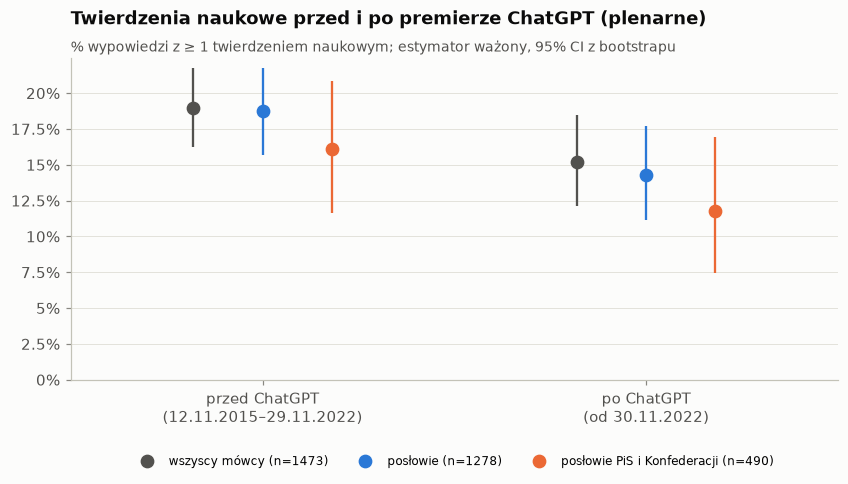

mówcy,wszyscy mówcy,posłowie,posłowie PiS i Konfederacji
n: przed ChatGPT,943,813,280
n: po ChatGPT,530,465,210
z twierdzeniem [%]: przed ChatGPT,18.9 [16.2; 21.7],18.7 [15.7; 21.7],16.1 [11.6; 20.8]
z twierdzeniem [%]: po ChatGPT,15.2 [12.1; 18.5],14.3 [11.2; 17.7],11.8 [7.5; 16.9]
różnica [pp],-3.7 [-8.0; +0.6],-4.4 [-8.8; +0.1],-4.3 [-10.8; +2.1]
twierdzenia / 100: przed ChatGPT,34.6 [28.9; 40.4],33.1 [27.1; 39.3],26.7 [19.6; 34.1]
twierdzenia / 100: po ChatGPT,33.8 [25.0; 43.0],29.4 [21.3; 38.6],18.7 [11.3; 27.3]
różnica (twierdzenia / 100),-0.8 [-11.1; +9.8],-3.8 [-13.5; +7.6],-8.0 [-18.7; +2.8]


,dni posiedzeń,wypowiedzi merytoryczne,"wzmianka, dowolny temat (na 1000)","wzmianka, klimat (na 1000)",próba LLM: n,próba LLM: z twierdzeniem [%]
1. połowa A (przed ChatGPT),32,8192,106.4,18.1,80,16.2 [8.6; 24.7]
2. połowa A (po ChatGPT),32,8200,77.0,11.7,85,16.7 [9.3; 25.5]


In [33]:
tab_c, pts_c = compare(df, "chatgpt", "przed", "po", CHATGPT_LABEL)
compare_plot(pts_c, ["przed", "po"], ["przed ChatGPT\n(12.11.2015–29.11.2022)", "po ChatGPT\n(od 30.11.2022)"],
             "Twierdzenia naukowe przed i po premierze ChatGPT (plenarne)", "llm_p_13_chatgpt")
display(tab_c)

wa = mer[mer["okno"] == "A"]
half = np.where(wa["data"] < CHATGPT, "1. połowa A (przed ChatGPT)", "2. połowa A (po ChatGPT)")
da = df[df["okno"] == "A"].copy()
da["h"] = np.where(da["data"] < CHATGPT, "1. połowa A (przed ChatGPT)", "2. połowa A (po ChatGPT)")
bh = R.bootstrap(da, "h")
pd.DataFrame({
    "dni posiedzeń": wa.groupby(half)["data"].nunique(),
    "wypowiedzi merytoryczne": wa.groupby(half).size(),
    "wzmianka, dowolny temat (na 1000)": 1000 * wa[TOPICS].ge(1).any(axis=1).groupby(half).mean(),
    "wzmianka, klimat (na 1000)": 1000 * wa["klimat"].ge(1).groupby(half).mean(),
    "próba LLM: n": bh["n"],
    "próba LLM: z twierdzeniem [%]": fmt_ci(bh),
}).round(1)

* Udział wypowiedzi z twierdzeniem spada z 18,9% do 15,2% (−3,7 pp [−8,0; +0,6]); u posłów −4,4 pp [−8,8; +0,1], u posłów PiS
  i Konfederacji −4,3 pp [−10,8; +2,1]. Liczba twierdzeń na 100 wypowiedzi się nie zmienia (35 i 34).
* „Przed ChatGPT” łączy okres przed COVID (wysoki udział) i okres COVID (niski), więc to porównanie miesza kilka zmian.
* W oknie A, które premiera ChatGPT dzieli na pół, udział jest taki sam przed i po (16,2% i 16,7%, n = 80 i 85), choć wzmianek
  o tematach jest w drugiej połowie mniej (106 → 77 na 1000 wypowiedzi).

### 5.9 Okresy H1 (COVID)

Porównanie trzech okresów pierwotnej hipotezy H1 (późniejszy minus wcześniejszy) dla obu miar i trzech grup mówców. To nie jest
test H1: mierzymy twierdzenia naukowe, a nie twierdzenia sprzeczne z konsensusem.

In [34]:
PAIRS = [("przed_covid", "covid"), ("przed_covid", "po_chatgpt"), ("covid", "po_chatgpt")]
subs = subsets_of(df)
rows = []
for unit, col in [("wypowiedzi z twierdzeniem [pp]", "y"), ("twierdzenia na 100 wypowiedzi", "n_twierdzen")]:
    for a, b in PAIRS:
        row = {"miara": unit, "porównanie": f"{PERIOD_LABEL[b]} − {PERIOD_LABEL[a]}"}
        for name, d in subs.items():
            row[f"{name} (n={len(d)})"] = fmt_diff(R.bootstrap_diff(d, "okres", a, b, y=col))
        rows.append(row)
pd.DataFrame(rows).set_index(["miara", "porównanie"])

wszyscy mówcy (n=1473)  \
miara                          porównanie                                        
wypowiedzi z twierdzeniem [pp] COVID − przed COVID        -15.9 [-21.4; -10.5]   
                               po ChatGPT − przed COVID   -15.1 [-19.9; -10.1]   
                               po ChatGPT − COVID            +0.8 [-4.2; +5.7]   
twierdzenia na 100 wypowiedzi  COVID − przed COVID        -39.2 [-52.2; -25.9]   
                               po ChatGPT − przed COVID   -28.8 [-42.5; -15.2]   
                               po ChatGPT − COVID          +10.3 [-1.0; +21.7]   

                                                            posłowie (n=1278)  \
miara                          porównanie                                       
wypowiedzi z twierdzeniem [pp] COVID − przed COVID       -16.3 [-22.0; -10.6]   
                               po ChatGPT − przed COVID  -16.1 [-21.3; -10.5]   
                               po ChatGPT − COVID           +0.2 [-4.7; +5.3]   
twierdzenia na 100 wypowiedzi  COVID − przed COVID       -36.4 [-49.5; -23.5]   
                               po ChatGPT − przed COVID  -29.8 [-43.5; -14.8]   
                               po ChatGPT − COVID          +6.6 [-4.0; +18.8]   

                                                        posłowie PiS i Konfederacji (n=490)  
miara                          porównanie                                                    
wypowiedzi z twierdzeniem [pp] COVID − przed COVID                      -15.6 [-25.2; -6.7]  
                               po ChatGPT − przed COVID                 -15.3 [-24.2; -7.0]  
                               po ChatGPT − COVID                         +0.3 [-7.4; +7.6]  
twierdzenia na 100 wypowiedzi  COVID − przed COVID                     -41.4 [-59.9; -23.4]  
                               po ChatGPT − przed COVID                -37.1 [-56.1; -19.1]  
                               po ChatGPT − COVID                        +4.3 [-6.7; +15.8]

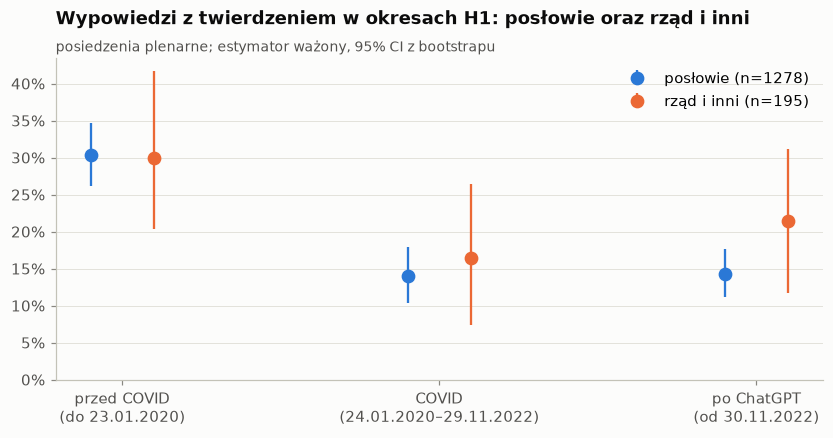

,posłowie (n=1278),rząd i inni (n=195)
przed COVID,30.4 [26.1; 34.7],30.0 [20.3; 41.8]
COVID,14.1 [10.3; 17.9],16.5 [7.3; 26.4]
po ChatGPT,14.3 [11.2; 17.7],21.4 [11.7; 31.1]


In [35]:
ROLE_SETS = {"posłowie": (df[df["rola"] == "poseł"], ACCENT), "rząd i inni": (df[df["rola"] != "poseł"], SECOND)}
fig, ax = plt.subplots(figsize=(9, 3.8))
src_tab = {}
for k, (name, (d, color)) in enumerate(ROLE_SETS.items()):
    b = R.bootstrap(d, "okres").loc[PERIODS]
    src_tab[f"{name} (n={len(d)})"] = fmt_ci(b)
    x = np.arange(len(PERIODS)) + (k - 0.5) * 0.2
    ax.errorbar(x, b["p"], yerr=[b["p"] - b["lo"], b["hi"] - b["p"]], fmt="o", color=color, ecolor=color,
                elinewidth=1.5, capsize=0, ms=8, label=f"{name} (n={len(d)})")
ax.set_xticks(range(len(PERIODS)), [PERIOD_TICK[p] for p in PERIODS])
ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax.set_title("Wypowiedzi z twierdzeniem w okresach H1: posłowie oraz rząd i inni")
subtitle(ax, "posiedzenia plenarne; estymator ważony, 95% CI z bootstrapu")
save(fig, "llm_p_14_okresy_role"); plt.show()
pd.DataFrame(src_tab, index=[PERIOD_LABEL[p] for p in PERIODS])

* Na całym filtrze spadek po 2020 r. jest wyraźny i taki sam we wszystkich grupach mówców: COVID − przed COVID ok. −16 pp,
  po ChatGPT − przed COVID ok. −15 pp, liczba twierdzeń na 100 wypowiedzi −29 do −41; żaden przedział nie obejmuje zera.
  Między okresem COVID a okresem po ChatGPT różnicy nie ma (+0,8 pp).
* Posłowie oraz rząd i inni zachowują się podobnie (30% przed COVID, 14–21% później), więc spadek nie wynika ze zmiany roli
  mówców.
* Ale sekcja 5.2 pokazuje, że spadek w okresie COVID to głównie efekt mianownika (słownik COVID). Po jego usunięciu zostaje
  spadek po ChatGPT (−11 pp). To nie jest test H1: mierzymy twierdzenia naukowe, nie sprzeczne z konsensusem.

### 5.10 Okresy przedwyborcze

Podgląd dla H2: wypowiedzi z 90 dni przed wyborami do Sejmu, Parlamentu Europejskiego i na prezydenta (pierwsza tura) w zakresie
danych. Służy ocenie, ile materiału przypada na okna kampanii, nie testowaniu H2.

In [36]:
camp = pd.Series(False, index=df.index)
for _, d in ELECTIONS:
    d = pd.Timestamp(d)
    camp |= df["data"].between(d - pd.Timedelta(days=90), d - pd.Timedelta(days=1))
df["kampania"] = np.where(camp, "90 dni przed wyborami", "pozostały czas")
b1, b2 = R.bootstrap(df, "kampania"), R.bootstrap(df, "kampania", y="n_twierdzen")
est, lo, hi = R.bootstrap_diff(df, "kampania", "pozostały czas", "90 dni przed wyborami")
print(f"różnica (kampania − pozostały czas): {100 * est:+.1f} pp [{100 * lo:+.1f}; {100 * hi:+.1f}]")
fb = filt[filt["okno"] == "B"]
for name, d in [("samorządowymi 7.04.2024", "2024-04-07"), ("do PE 9.06.2024", "2024-06-09")]:
    d = pd.Timestamp(d)
    print(f"okno B: {fb['data'].between(d - pd.Timedelta(days=90), d - pd.Timedelta(days=1)).mean():.0%} wypowiedzi z filtra "
          f"przypada na 90 dni przed wyborami {name}")
pd.DataFrame({"n (próba)": b1["n"], "z twierdzeniem [%]": fmt_ci(b1), "twierdzenia / 100 wyp.": fmt_ci(b2),
              "szac. twierdzenia w populacji": R.weighted_total(df, "kampania", y="n_twierdzen").round().astype(int)})

różnica (kampania − pozostały czas): -0.3 pp [-7.6; +7.4]
okno B: 18% wypowiedzi z filtra przypada na 90 dni przed wyborami samorządowymi 7.04.2024
okno B: 17% wypowiedzi z filtra przypada na 90 dni przed wyborami do PE 9.06.2024


,n (próba),z twierdzeniem [%],twierdzenia / 100 wyp.,szac. twierdzenia w populacji
kampania,,,,
90 dni przed wyborami,141,17.3 [10.7; 24.9],31.2 [18.3; 47.5],405
pozostały czas,1332,17.5 [15.4; 19.8],34.6 [29.3; 40.2],3826


* Na okna 90 dni przed wyborami przypada 141 wypowiedzi z próby (10%) i szacunkowo ok. 400 twierdzeń w populacji. Udział
  wypowiedzi z twierdzeniem jest taki sam jak w pozostałym czasie (17,3% i 17,5%, różnica −0,3 pp [−7,6; +7,4]).
* W oknie B 18% wypowiedzi z filtra przypada na 90 dni przed wyborami samorządowymi (7.04.2024), a 17% przed wyborami do PE
  (9.06.2024); okresy częściowo się pokrywają.

## 6. Kto mówi

### 6.1 Rola mówcy i kadencja

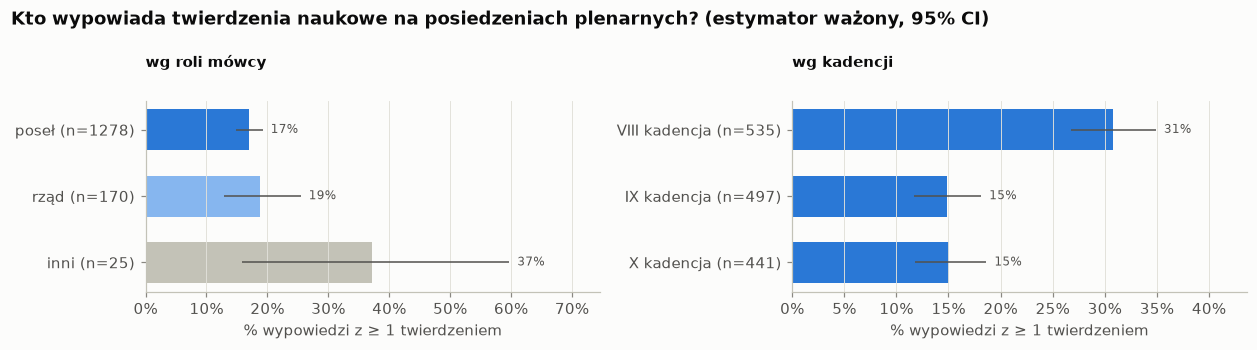

,% wypowiedzi w próbie,% twierdzeń,z twierdzeniem [%]
rola,,,
poseł,86.8,80.9,17.0 [14.8; 19.2]
rząd,11.5,14.3,18.7 [12.9; 25.5]
inni,1.7,4.7,37.1 [15.8; 59.7]


In [37]:
b_rola = R.bootstrap(df, "rola").reindex(["poseł", "rząd", "inni"])
b_kad = R.bootstrap(df, "kadencja").reindex([8, 9, 10])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.2))
hbar_ci(a1, b_rola, [ROLE_KOLOR[r] for r in b_rola.index], [f"{r} (n={n})" for r, n in zip(b_rola.index, b_rola["n"])])
hbar_ci(a2, b_kad, ACCENT, [f"{k} kadencja (n={n})" for k, n in zip(["VIII", "IX", "X"], b_kad["n"])])
a1.set_title("wg roli mówcy", fontsize=10); a2.set_title("wg kadencji", fontsize=10)
for ax in (a1, a2):
    ax.set_xlabel("% wypowiedzi z ≥ 1 twierdzeniem")
fig.suptitle("Kto wypowiada twierdzenia naukowe na posiedzeniach plenarnych? (estymator ważony, 95% CI)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_p_15_rola_kadencja"); plt.show()
pd.DataFrame({"% wypowiedzi w próbie": df["rola"].value_counts(normalize=True) * 100,
              "% twierdzeń": cl["rola"].value_counts(normalize=True) * 100,
              "z twierdzeniem [%]": fmt_ci(b_rola)}).reindex(["poseł", "rząd", "inni"]).round(1)

Posłowie (17%) i rząd (19%) formułują twierdzenia równie często. Rola „inni” ma 37%, ale to tylko 25 wypowiedzi (2% próby, 5%
twierdzeń). Rola „inni” jest za mała, żeby przesuwać wyniki. Między kadencjami VIII a IX udział
spada z 31% do 15% i w X kadencji zostaje na tym poziomie.

### 6.2 Bloki polityczne (tylko posłowie)

Kolor oznacza zawsze ten sam blok (paleta z `01`).

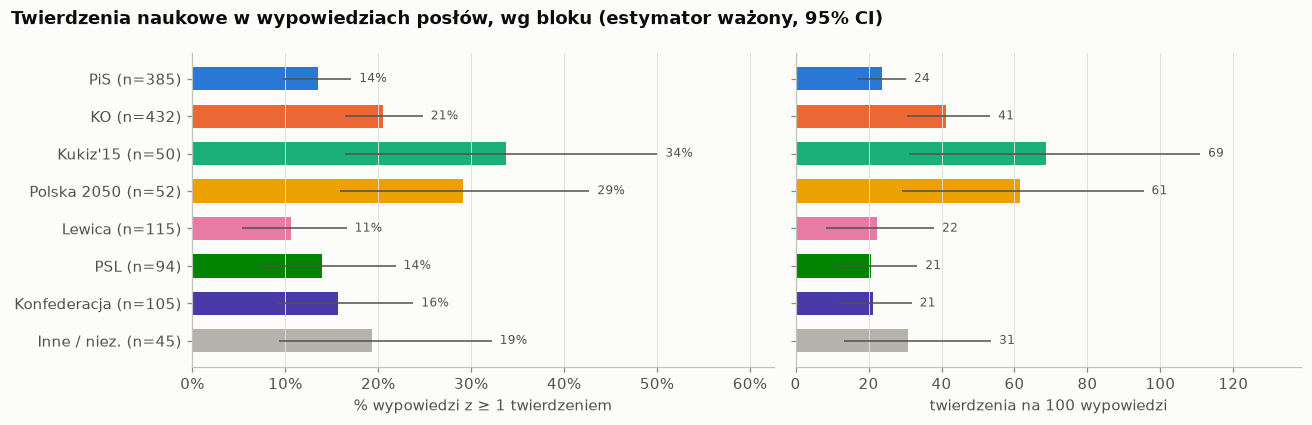

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
blok,,,
PiS,385,13.5 [9.8; 17.1],23.7 [17.1; 30.3]
KO,432,20.6 [16.4; 24.8],41.3 [30.4; 53.3]
Kukiz'15,50,33.8 [16.5; 50.1],68.6 [31.1; 110.9]
Polska 2050,52,29.1 [15.9; 42.7],61.5 [29.2; 95.4]
Lewica,115,10.7 [5.4; 16.6],22.4 [8.4; 38.0]
PSL,94,14.0 [7.4; 21.9],20.7 [10.6; 33.4]
Konfederacja,105,15.7 [9.0; 23.8],21.2 [11.9; 31.8]
Inne / niez.,45,19.4 [9.3; 32.2],30.8 [13.3; 53.6]


In [38]:
pos = df[df["rola"] == "poseł"]
blocs = [b for b in BLOKI if b in set(pos["blok"])]
b1 = R.bootstrap(pos, "blok").reindex(blocs)
b2 = R.bootstrap(pos, "blok", y="n_twierdzen").reindex(blocs)
colors = [BLOK_KOLOR[b] for b in blocs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.15, 1]})
hbar_ci(a1, b1, colors, [f"{b} (n={n})" for b, n in zip(blocs, b1["n"])])
hbar_ci(a2, b2, colors, pct=False)
a1.set_xlabel("% wypowiedzi z ≥ 1 twierdzeniem"); a2.set_xlabel("twierdzenia na 100 wypowiedzi")
fig.suptitle("Twierdzenia naukowe w wypowiedziach posłów, wg bloku (estymator ważony, 95% CI)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_p_16_bloki"); plt.show()
pd.DataFrame({"n": b1["n"], "z twierdzeniem [%]": fmt_ci(b1), "twierdzenia / 100 wyp.": fmt_ci(b2)})

Wśród posłów największe kluby różnią się: KO 21% [16; 25], PiS 14% [10; 17], Konfederacja 16%, Lewica 11%, PSL 14%. Mniejsze
kluby (Kukiz'15, Polska 2050) mają ok. 30%, ale przy n ≈ 50. Te porównania mieszają jednak blok z czasem: Konfederacja i Lewica
mają przed COVID tylko 3 i 6 wypowiedzi w próbie (ich kluby działają od IX kadencji), więc ich wypowiedzi pochodzą prawie
wyłącznie z lat z niskim udziałem. Tabela niżej pokazuje bloki w okresach.

In [39]:
cp = cl[cl["rola"] == "poseł"]
big = ["PiS", "KO", "Konfederacja", "Lewica", "PSL"]
bp = pos[pos["blok"].isin(big)]
pd.concat({
    "n": pd.crosstab(bp["blok"], bp["okres"]).reindex(index=big, columns=PERIODS),
    "z twierdzeniem [%]": bp.groupby(["blok", "okres"]).apply(lambda g: 100 * np.average(g["y"], weights=g["waga"]),
                                                              include_groups=False).unstack().reindex(index=big, columns=PERIODS),
}, axis=1).rename(columns=PERIOD_LABEL).round(1)

n                  z twierdzeniem [%]                 
okres        przed COVID COVID po ChatGPT        przed COVID COVID po ChatGPT
blok                                                                         
PiS                  171    78        136               26.5   9.1       10.7
KO                   210   103        119               33.2  16.3       17.0
Konfederacja           3    28         74               66.7  18.2       13.6
Lewica                 6    63         46               69.8   7.7       13.1
PSL                   39    29         26               30.6   9.9       11.4

W obrębie okresu bloki są bliżej siebie: po ChatGPT 11–17% (PiS 11%, KO 17%, Konfederacja 14%, Lewica 13%, PSL 11%), w okresie
COVID 8–18%. Przed COVID wszystkie duże bloki z sensowną liczbą wypowiedzi mają 27–33%. Różnice między blokami w całej próbie są
więc w dużej części różnicami czasu. Porównanie bloków (np. prawica w rządzie i w opozycji) trzeba robić w tym samym okresie
albo z kontrolą okresu.

Te same dane na wykresie: odsetek wypowiedzi z twierdzeniem dla pięciu największych bloków w okresach H1 i w oknach A i B
(punkt pominięty, gdy w komórce jest mniej niż 10 wypowiedzi), a niżej szacowana liczba twierdzeń posłów w populacji filtra
rok po roku, z podziałem na bloki.

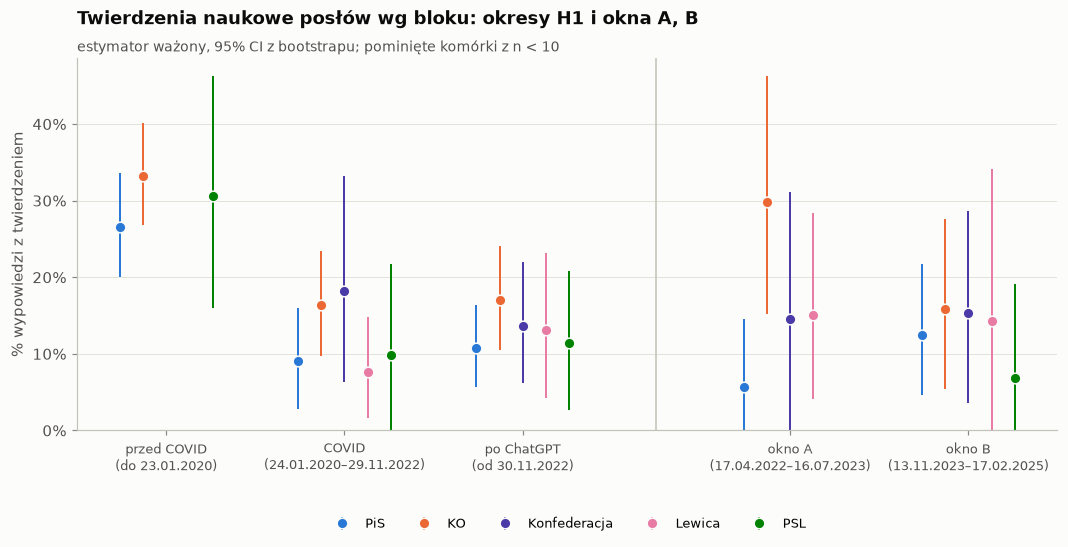

,przed COVID (do 23.01.2020),COVID (24.01.2020–29.11.2022),po ChatGPT (od 30.11.2022),okno A (17.04.2022–16.07.2023),okno B (13.11.2023–17.02.2025)
PiS,26.5 (n=171),9.1 (n=78),10.7 (n=136),5.6 (n=34),12.4 (n=56)
KO,33.2 (n=210),16.3 (n=103),17.0 (n=119),29.8 (n=35),15.8 (n=46)
Konfederacja,66.7 (n=3),18.2 (n=28),13.6 (n=74),14.5 (n=23),15.3 (n=27)
Lewica,69.8 (n=6),7.7 (n=63),13.1 (n=46),15.0 (n=31),14.3 (n=15)
PSL,30.6 (n=39),9.9 (n=29),11.4 (n=26),0.0 (n=7),6.8 (n=12)


In [40]:
MIN_N = 10
XCOLS = [("okres", p, PERIOD_TICK[p]) for p in PERIODS] + [("okno", k, WINDOW_TICK[k]) for k in WINDOWS]
XPOS = [0, 1, 2, 3.5, 4.5]
cells = {}
for b in big:
    d = bp[bp["blok"] == b]
    for by in ("okres", "okno"):
        bb = R.bootstrap(d[d[by].notna()], by)
        for v, r in bb.iterrows():
            cells[(b, by, v)] = r
fig, ax = plt.subplots(figsize=(11.5, 4.4))
for j, b in enumerate(big):
    pts = [(XPOS[i] + (j - 2) * 0.13, cells[(b, by, v)]) for i, (by, v, _) in enumerate(XCOLS)
           if (b, by, v) in cells and cells[(b, by, v)]["n"] >= MIN_N]
    xs_b = [x for x, _ in pts]
    p = np.array([r["p"] for _, r in pts]); lo = np.array([r["lo"] for _, r in pts]); hi = np.array([r["hi"] for _, r in pts])
    ax.errorbar(xs_b, p, yerr=[p - lo, hi - p], fmt="o", color=BLOK_KOLOR[b], ecolor=BLOK_KOLOR[b], elinewidth=1.3,
                capsize=0, ms=7, mec=SURF, mew=1, label=b)
ax.axvline(2.75, color=AXIS, lw=1)
ax.set_xticks(XPOS, [t for _, _, t in XCOLS], fontsize=8.5); ax.set_xlim(-0.5, 5)
ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, None); ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=5, fontsize=8.5)
ax.set_ylabel("% wypowiedzi z twierdzeniem")
ax.set_title("Twierdzenia naukowe posłów wg bloku: okresy H1 i okna A, B")
subtitle(ax, f"estymator ważony, 95% CI z bootstrapu; pominięte komórki z n < {MIN_N}")
save(fig, "llm_p_25_bloki_okresy"); plt.show()
pd.DataFrame({lab.replace("\n", " "): {b: (f"{100 * cells[(b, by, v)]['p']:.1f} (n={int(cells[(b, by, v)]['n'])})"
                                       if (b, by, v) in cells else "–") for b in big} for by, v, lab in XCOLS})

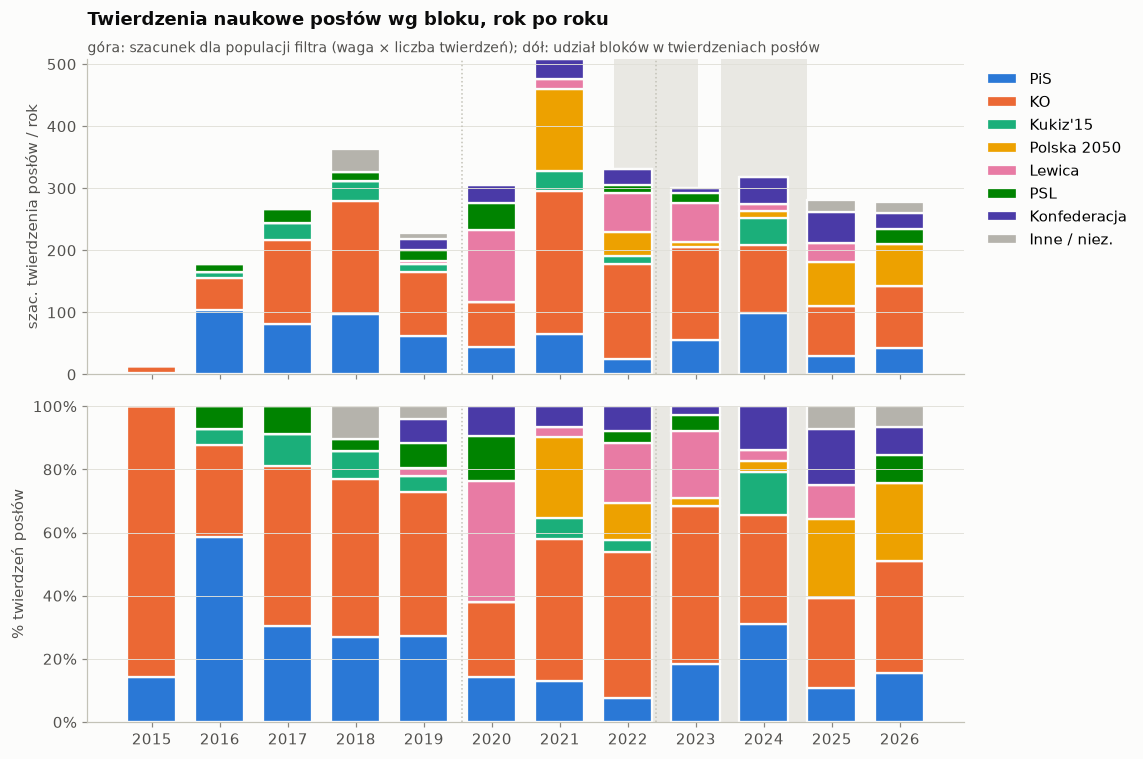

**Twierdzenia posłów w próbie wg roku i bloku**

rok,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
blok,,,,,,,,,,,,
PiS,2,24,21,21,21,3,4,2,7,9,3,7
KO,12,12,35,39,35,5,14,12,19,10,8,16
Kukiz'15,0,2,7,7,4,0,2,1,0,4,0,0
Polska 2050,0,0,0,0,0,0,8,3,1,1,7,11
Lewica,0,0,0,0,2,8,1,5,8,1,3,0
PSL,0,3,6,3,6,3,0,1,2,0,0,4
Konfederacja,0,0,0,0,6,2,2,2,1,4,5,4
Inne / niez.,0,0,0,8,3,0,0,0,0,0,2,3


In [41]:
est_b = (pos.assign(w_tw=pos["waga"] * pos["n_twierdzen"])
         .pivot_table(index="rok", columns="blok", values="w_tw", aggfunc="sum", fill_value=0)
         .reindex(index=YEARS, columns=blocs, fill_value=0))
share_b = est_b.div(est_b.sum(axis=1), axis=0).fillna(0)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)
for ax, data in [(a1, est_b), (a2, share_b)]:
    bottom = np.zeros(len(data))
    for b in blocs:
        ax.bar(data.index, data[b], bottom=bottom, color=BLOK_KOLOR[b], width=0.72, edgecolor=SURF, linewidth=1.5, label=b)
        bottom += data[b].to_numpy()
    ax.grid(axis="x", visible=False)
    period_lines(ax, label=False)
a1.set_ylabel("szac. twierdzenia posłów / rok"); a2.set_ylabel("% twierdzeń posłów")
a2.yaxis.set_major_formatter(PCT); a2.set_ylim(0, 1); a2.set_xticks(YEARS)
a1.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
a1.set_title("Twierdzenia naukowe posłów wg bloku, rok po roku")
subtitle(a1, "góra: szacunek dla populacji filtra (waga × liczba twierdzeń); dół: udział bloków w twierdzeniach posłów")
fig.tight_layout()
save(fig, "llm_p_26_bloki_rok"); plt.show()
display(Markdown("**Twierdzenia posłów w próbie wg roku i bloku**"),
        pd.crosstab(cp["rok"], cp["blok"]).reindex(index=YEARS, columns=blocs, fill_value=0).T)

* **Okresy H1.** We wszystkich blokach udział spada po 2020 r.: PiS 26,5% → 9,1% → 10,7%, KO 33,2% → 16,3% → 17,0%,
  PSL 30,6% → 9,9% → 11,4%. Wewnątrz okresu przedziały bloków się nakładają. Spadek jest więc wspólny dla całego Sejmu,
  a nie cechą jednego klubu (5.2 pokazuje, że w okresie COVID to głównie efekt mianownika).
* **Okna.** PiS: 5,6% w A (n = 34, partia rządząca) i 12,4% w B (n = 56, opozycja). KO odwrotnie: 29,8% → 15,8%, przy czym
  wynik KO w A to głównie wypowiedź o kryzysie wodnym. Konfederacja (14,5% i 15,3%) i Lewica (15,0% i 14,3%) bez zmian.
  Przy kilkudziesięciu wypowiedziach przedziały mają po ±10–15 pp i wszystkie się nakładają, więc zmiany roli rząd / opozycja
  nie da się tu potwierdzić. PSL ma w oknie A tylko 7 wypowiedzi (pominięty).
* **Liczby bezwzględne.** KO daje największą część twierdzeń posłów niemal w każdym roku (ok. 25–50%), PiS ok. 27–30%
  w latach 2017–2019, 8–14% w latach 2020–2022, 31% w 2024 r. i 11–15% później. Konfederacja to najwyżej ok. 14–18% twierdzeń
  posłów rocznie (2024–2025). Udział bloku zależy od liczby jego posłów i od tego, kto zabiera głos, a ministrów z partii
  rządzącej liczymy jako „rząd”, więc partia rządząca ma w tych wykresach mniej wypowiedzi.
* W pojedynczym roku blok to w próbie zwykle kilka–kilkanaście twierdzeń (tabela wyżej), a pojedyncza wypowiedź potrafi
  przesunąć udział o kilkanaście punktów (np. Lewica w 2020 r.). Roczne słupki pokazują skalę, a nie trend.

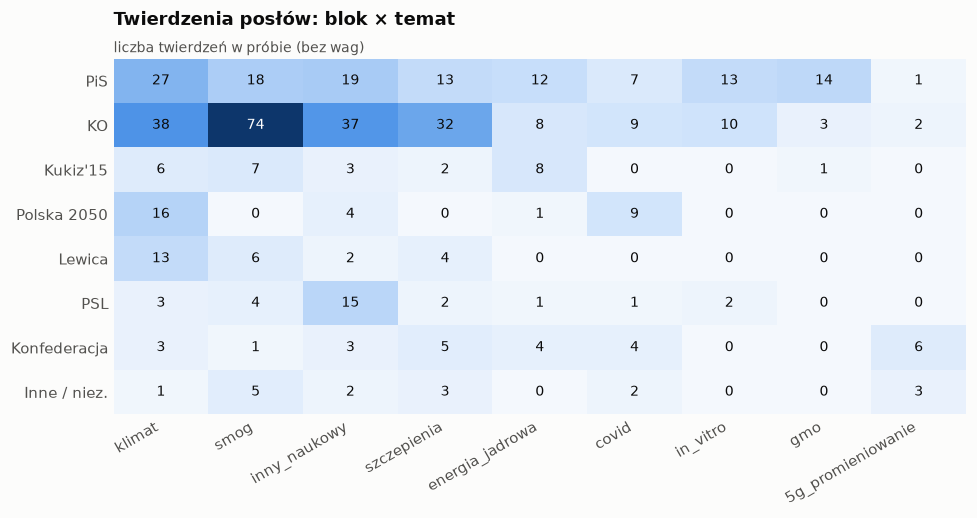

In [42]:
bt = pd.crosstab(cp["blok"], cp["temat"]).reindex(index=blocs, columns=[t for t in topics_tab.index], fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.imshow(bt.values, cmap=SEQ, aspect="auto", vmin=0)
ax.set_xticks(range(bt.shape[1]), bt.columns, rotation=30, ha="right"); ax.set_yticks(range(bt.shape[0]), bt.index)
ax.grid(False); ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(bt.shape[0]):
    for j in range(bt.shape[1]):
        v = bt.values[i, j]
        ax.text(j, i, f"{v}", ha="center", va="center", fontsize=9, color="white" if v > bt.values.max() * 0.55 else INK)
ax.set_title("Twierdzenia posłów: blok × temat")
subtitle(ax, "liczba twierdzeń w próbie (bez wag)")
save(fig, "llm_p_17_bloki_tematy"); plt.show()

### 6.3 Mówcy z największą liczbą twierdzeń w próbie

In [43]:
spk = (df.groupby("mowca").agg(kto=("kto", "first"), wypowiedzi=("y", "size"), z_twierdzeniem=("y", "sum"),
                               twierdzenia=("n_twierdzen", "sum"))
       .sort_values("twierdzenia", ascending=False))
print(f"mówcy w próbie: {len(spk)}; 10 mówców z największą liczbą twierdzeń ma {spk['twierdzenia'].head(10).sum()} "
      f"z {int(spk['twierdzenia'].sum())} twierdzeń ({spk['twierdzenia'].head(10).sum() / spk['twierdzenia'].sum():.0%})")
top = spk.head(12)
top.index = top.index.str.slice(0, 90)
top

mówcy w próbie: 572; 10 mówców z największą liczbą twierdzeń ma 143 z 614 twierdzeń (23%)


,kto,wypowiedzi,z_twierdzeniem,twierdzenia
mowca,,,,
Ewa Lieder,KO,16,12,26
Alicja Chybicka,KO,9,6,24
Jan Krzysztof Ardanowski,PiS,8,5,15
Katarzyna Maria Piekarska,KO,3,1,14
Józefa Szczurek-Żelazko,PiS,13,5,13
Jan Szyszko,PiS,3,3,12
Jarosław Pinkas,inni,2,2,11
Mirosław Suchoń,KO,17,7,10
Robert Majka,Konfederacja,5,3,9


Twierdzenia są skupione w mówcach:
10 z 572 mówców daje 23% twierdzeń. Jedna rozbudowana wypowiedź daje do kilkunastu twierdzeń, więc testy muszą uwzględniać
skupienie w mówcach.

## 7. Słowniki a LLM

Czy trafienia słowników przewidują obecność twierdzeń naukowych? Odsetki bez wag.

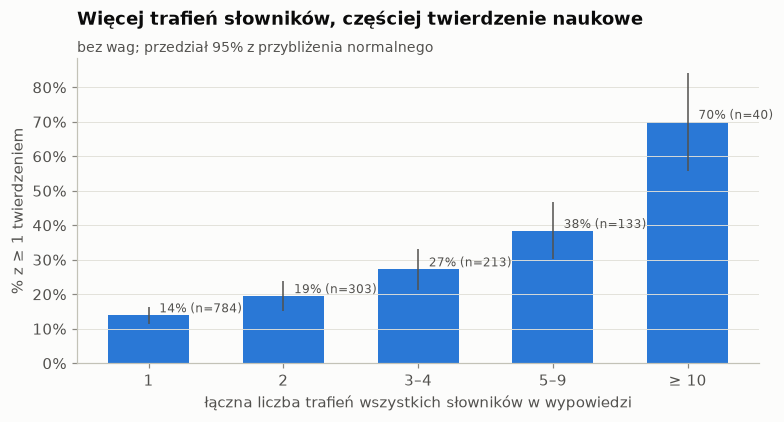

,n,z twierdzeniem [%],twierdzenia / 100 wyp.
trafienie słownika tematu (≥ 1),1173.0,20.8,43.6
wypowiedź tematyczna z 01 (≥ 3 trafienia tematu),300.0,39.3,93.0
"tylko marker nauka / sceptycyzm, bez tematu",300.0,20.3,34.0
marker nauka > 0,357.0,26.6,53.2
marker nauka = 0,1116.0,18.8,38.0
marker sceptycyzm > 0,25.0,32.0,60.0


In [44]:
df["trafienia"] = pd.cut(df[sampling.HIT_COLS].sum(axis=1), [1, 2, 3, 5, 10, np.inf],
                         labels=["1", "2", "3–4", "5–9", "≥ 10"], right=False)
hits = df.groupby("trafienia", observed=True).agg(n=("y", "size"), p=("y", "mean"))
se = np.sqrt(hits["p"] * (1 - hits["p"]) / hits["n"])
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(hits))
ax.bar(x, hits["p"], color=ACCENT, width=0.6)
ax.errorbar(x, hits["p"], yerr=1.96 * se, fmt="none", ecolor=INK2, elinewidth=1, capsize=0)
for xi, (p, n) in enumerate(zip(hits["p"], hits["n"])):
    ax.text(xi + 0.08, p, f"{p:.0%} (n={n})", fontsize=8, color=INK2, va="bottom")
ax.set_xticks(x, hits.index); ax.yaxis.set_major_formatter(PCT); ax.grid(axis="x", visible=False)
ax.set_xlabel("łączna liczba trafień wszystkich słowników w wypowiedzi"); ax.set_ylabel("% z ≥ 1 twierdzeniem")
ax.set_title("Więcej trafień słowników, częściej twierdzenie naukowe")
subtitle(ax, "bez wag; przedział 95% z przybliżenia normalnego")
save(fig, "llm_p_18_regex_vs_llm"); plt.show()

topic_hit = df[TOPICS].gt(0).any(axis=1)
groups = {
    "trafienie słownika tematu (≥ 1)": topic_hit,
    "wypowiedź tematyczna z 01 (≥ 3 trafienia tematu)": df[TOPICS].ge(T.PROG).any(axis=1),
    "tylko marker nauka / sceptycyzm, bez tematu": ~topic_hit,
    "marker nauka > 0": df["nauka"].gt(0),
    "marker nauka = 0": df["nauka"].eq(0),
    "marker sceptycyzm > 0": df["sceptycyzm"].gt(0),
}
pd.DataFrame({k: {"n": int(m.sum()), "z twierdzeniem [%]": 100 * df.loc[m, "y"].mean(),
                  "twierdzenia / 100 wyp.": 100 * df.loc[m, "n_twierdzen"].mean()} for k, m in groups.items()}).T.round(1)

* Liczba trafień przewiduje twierdzenie: przy jednym trafieniu twierdzenie ma 14% wypowiedzi, przy 3–4 trafieniach 27%, przy co
  najmniej dziesięciu 70%. „Wypowiedź tematyczna” z `01` (≥ 3 trafienia tematu) zawiera twierdzenie w 39% przypadków.
* Marker `nauka` podnosi odsetek z 19% do 27%. Wypowiedzi, które przeszły filtr wyłącznie dzięki markerom, mają twierdzenie
  równie często jak te ze słownikiem tematu (20% i 21%).
* Słowniki mierzą temat rozmowy. Jako filtr wstępny przepuszczają dużo wypowiedzi bez twierdzeń (79%), a ich czułości
  (ile twierdzeń jest poza filtrem) nadal nie znamy.

## 8. Atrybucja (cytaty)

Czy mówca twierdzi sam, czy przytacza cudze twierdzenie (z aprobatą lub w polemice).

In [45]:
display(cl["atrybucja"].value_counts().to_frame("twierdzenia"))
cl.loc[cl["atrybucja"] != "wlasne", ["rok", "atrybucja", "cytat", "twierdzenie"]]

,twierdzenia
atrybucja,
wlasne,584
cytat_zgoda,27
cytat_polemika,3


,rok,atrybucja,cytat,twierdzenie
12,2015,cytat_zgoda,Poinformowano mnie o zmianach refundacyjnych utrudniających dostęp dzieci po transplantacjach do leku - i tu jego nazwa. To niepokojące i z medycznego punktu widzenia w najlepiej pojętym interesie...,Zmiany w refundacji leków transplantologicznych mogą zagrażać zdrowiu pacjentów po przeszczepach.
13,2015,cytat_zgoda,"Podanie, co wymusi sytuacja finansowa, niebadanego nigdy w tej grupie wiekowej kolejnego leku odtwórczego dzieciom po transplantacji, utrzymywanym długotrwale bez steroidów - uwaga, cytat - jest o...",Stosowanie nieprzebadanych leków u dzieci po przeszczepach może prowadzić do odrzucenia przeszczepu.
44,2018,cytat_zgoda,"Rzecznik Głównego Inspektoratu Sanitarnego mówi, że statystyki są bezwzględne i jeśli liczba nieszczepionych osób będzie rosła, to kwestią czasu pozostanie to, kiedy pojawi się zgon polskiego dzie...",Wzrost liczby nieszczepionych osób może prowadzić do zgonów dzieci z powodu odry.
45,2018,cytat_zgoda,"Ten sam rzecznik informuje, że w Polsce jest kilkukrotny wzrost zachorowań na odrę i dotyczy to osób bez szczepień, które przyjechały do nas z różnych krajów.","W Polsce obserwuje się wzrost zachorowań na odrę wśród osób nieszczepionych, które przyjechały z innych krajów."
46,2018,cytat_zgoda,"Mówi też, że tam, gdzie odchodzi się od szczepień, trzeba liczyć się ze zgonami.",Rezygnacja ze szczepień może prowadzić do zgonów z powodu chorób zakaźnych.
87,2019,cytat_zgoda,"Nie mogę z zadowoleniem powitać takiej technologii, jeśli standardy promieniowania, które muszą chronić obywatela, nie są przestrzegane.","Technologia 5G może stanowić zagrożenie dla zdrowia, jeśli nie są przestrzegane standardy promieniowania."
89,2020,cytat_polemika,"Nie ma epidemii? Jest epidemia, panie pośle.",Istnieje epidemia koronawirusa.
144,2019,cytat_zgoda,"uwzględniając opinie naukowców, że alkoholizm jest także uzależniony od dostępności ekonomicznej",Alkoholizm jest uzależniony od dostępności ekonomicznej alkoholu.
158,2019,cytat_zgoda,"argumentując, iż nie zapewnią one realizacji celu, jakiemu mają służyć. Wręcz przeciwnie, piszą naukowcy, zarówno wytyczne Europejskiego Urzędu ds. Bezpieczeństwa Żywności, jak i krajowa praktyka ...","Masowe odstrzały dzików przyczyniają się do roznoszenia wirusa, co potwierdzają wytyczne Europejskiego Urzędu ds. Bezpieczeństwa Żywności i krajowa praktyka."
187,2018,cytat_zgoda,"Prof. Mirosław Wysocki, prof. Jacek Wysocki, dr Hanna Czajka, prof. Andrzej Zieliński oraz dr Paweł Grzesiowski, wszyscy oni mówią, że system niepożądanych odczynów poszczepiennych jest niewiarygo...","Eksperci wakcynologii potwierdzają, że system rejestracji niepożądanych odczynów poszczepiennych jest niewiarygodny."


584 z 614 twierdzeń to twierdzenia własne mówcy, 27 to cytaty z aprobatą, 3 to polemika. Polemika jest rozpoznawana rzadko:
oprócz trzech przypadków powyżej co najmniej jedna polemika (mówca nazywa przytoczoną tezę o CO2 „mitologią”, 5.5) jest zapisana
jako `wlasne`. Wśród cytatów z aprobatą są odwołania do instytucji i ekspertów (rzecznik GIS, WHO, prof. Jassem), ale też twierdzenia,
które etap B mógłby uznać za sprzeczne z konsensusem: o „silnych dowodach”, że pole elektromagnetyczne powoduje nowotwory, Alzheimera
i bezpłodność (2019), o wadach wrodzonych dzieci z in vitro (2016) i o niewiarygodności systemu zgłaszania odczynów poszczepiennych
(2018). Atrybucja `cytat_zgoda` przypisuje je mówcy, co jest poprawne.

## 9. Źródła błędu i problemy

Bez ręcznej anotacji nie zmierzymy precyzji ani czułości, ale część problemów widać w samych danych. Najważniejsze
pytanie dla porównań w czasie brzmi: czy błąd jest **taki sam w porównywanych okresach**. Ustawienia przebiegu (kontekst 16 384
tokeny, limit 16 kandydatów, krok 2 z fragmentem wypowiedzi) dobraliśmy tak, żeby wypowiedź mieściła się w kontekście modelu;
9.1 sprawdza, czy tak jest.

### 9.1 Kontrola przebiegu: kontekst i czas

prompt bazowy ≈ 4711 tokenów + 2.96 tokenu na słowo; najwięcej: wejście 12,602, wejście + odpowiedź 14,972 (kontekst 16,384)
czas ≈ 8.1 s + 11.3 s na 1000 słów; wypowiedzi bez kandydatów średnio 3.1 s, z twierdzeniem 26.8 s


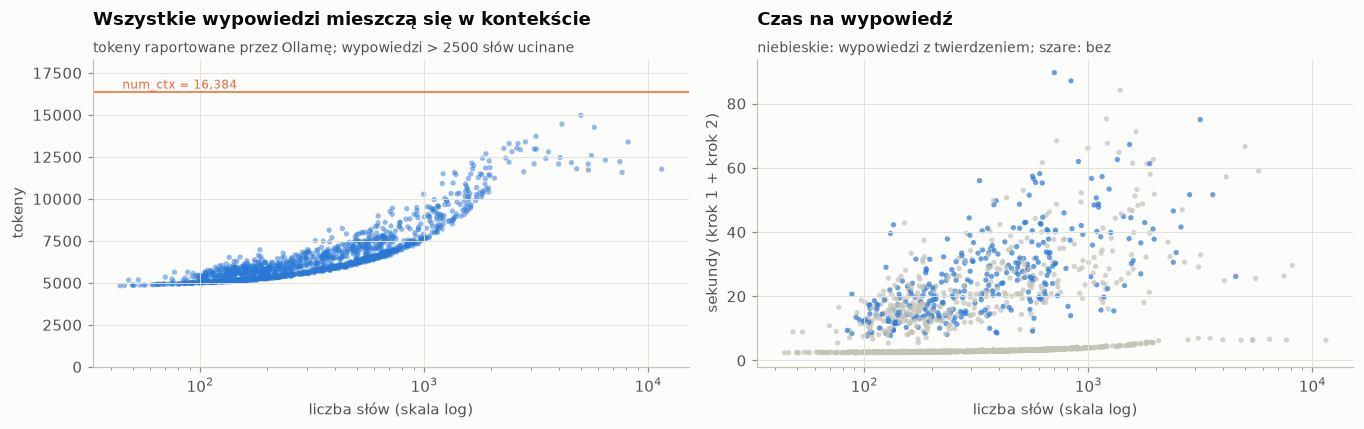

ucięte do 2500 słów: 26 wypowiedzi (2,592–11,502 słów), z twierdzeniem 19%; pełny limit 16 kandydatów: 9 wypowiedzi


In [46]:
df["tokeny_razem"] = df["tokeny_we"] + df["tokeny_wy"]
slope, intercept = np.polyfit(df["liczba_slow"].clip(upper=llm.MAX_WORDS), df["tokeny_we"], 1)
s_slope, s_icpt = np.polyfit(df["liczba_slow"].clip(upper=llm.MAX_WORDS), df["sekundy"], 1)
print(f"prompt bazowy ≈ {intercept:.0f} tokenów + {slope:.2f} tokenu na słowo; najwięcej: wejście {df['tokeny_we'].max():,}, "
      f"wejście + odpowiedź {df['tokeny_razem'].max():,} (kontekst {llm.NUM_CTX:,})")
print(f"czas ≈ {s_icpt:.1f} s + {1000 * s_slope:.1f} s na 1000 słów; wypowiedzi bez kandydatów średnio "
      f"{df.loc[df['n_kandydatow'] == 0, 'sekundy'].mean():.1f} s, z twierdzeniem {df.loc[df['y'] == 1, 'sekundy'].mean():.1f} s")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4))
a1.scatter(df["liczba_slow"], df["tokeny_razem"], s=12, color=ACCENT, alpha=0.5, edgecolor="none", label="wejście + odpowiedź")
a1.axhline(llm.NUM_CTX, color=SECOND, lw=1)
a1.text(45, llm.NUM_CTX, f"num_ctx = {llm.NUM_CTX:,}", fontsize=8, color=SECOND, va="bottom")
a1.set_xscale("log"); a1.set_ylim(0, llm.NUM_CTX * 1.12)
a1.set_xlabel("liczba słów (skala log)"); a1.set_ylabel("tokeny")
a1.set_title("Wszystkie wypowiedzi mieszczą się w kontekście")
subtitle(a1, "tokeny raportowane przez Ollamę; wypowiedzi > 2500 słów ucinane")
a2.scatter(df["liczba_slow"], df["sekundy"], s=12, c=np.where(df["y"] == 1, ACCENT, AXIS), alpha=0.7, edgecolor="none")
a2.set_xscale("log"); a2.set_xlabel("liczba słów (skala log)"); a2.set_ylabel("sekundy (krok 1 + krok 2)")
a2.set_title("Czas na wypowiedź")
subtitle(a2, "niebieskie: wypowiedzi z twierdzeniem; szare: bez")
fig.tight_layout()
save(fig, "llm_p_19_tokeny_czas"); plt.show()
cut = df[df["obciete"]]
print(f"ucięte do {llm.MAX_WORDS} słów: {len(cut)} wypowiedzi ({cut['liczba_slow'].min():,}–{cut['liczba_slow'].max():,} słów), "
      f"z twierdzeniem {cut['y'].mean():.0%}; pełny limit {llm.MAX_CANDIDATES} kandydatów: "
      f"{int(df['pelny_limit'].sum())} wypowiedzi")

* Prompt kroku 1 to ok. 4,7 tys. tokenów, a każde słowo wypowiedzi dodaje ok. 3 tokeny. Najdłuższe wejście miało 12,6 tys.
  tokenów, a wejście z odpowiedzią 15,0 tys., czyli mniej niż kontekst 16 384. Przepełnień nie ma.
* Czas zależy głównie od tego, czy model coś znalazł: wypowiedzi bez kandydatów trwają średnio 3 s, z twierdzeniem 27 s
  (odpowiedź jest dłuższa, a krok 2 uruchamia się dla każdego kandydata). Długość wypowiedzi dodaje ok. 11 s na 1000 słów.
* 26 wypowiedzi (2 592–11 502 słów) ucięliśmy do 2500 słów; twierdzenie ma 19% z nich. Dalsza część tych wypowiedzi jest poza
  pomiarem.

### 9.2 Limit kandydatów

In [47]:
late = cand[cand["nr"] >= 8]
print(f"kandydaci na pozycjach 9–16: {len(late)} w {late['wypowiedz_id'].nunique()} wypowiedziach; "
      f"z nich twierdzenia: {int(late['weryfikacja'].eq(True).sum())} (w {late.loc[late['weryfikacja'].eq(True), 'wypowiedz_id'].nunique()} wyp.)")
df["n_kandydatow"].value_counts().sort_index().rename("wypowiedzi").to_frame().T

kandydaci na pozycjach 9–16: 251 w 74 wypowiedziach; z nich twierdzenia: 19 (w 13 wyp.)


n_kandydatow,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
wypowiedzi,773,28,97,124,116,107,73,45,36,15,24,9,7,2,5,3,9


Limit 16 zapełnia 9 wypowiedzi. Kandydaci na pozycjach 9–16 (251 w 74 wypowiedziach) dali 19 twierdzeń, czyli 3% wszystkich.
Przy limicie 8 te twierdzenia by przepadły; przy 16 gubimy prawdopodobnie tylko pojedyncze.

### 9.3 Krok 2: odsetek potwierdzeń

Odsetek potwierdzeń w kroku 2 wg okresu, okna, roli i tematu nadanego w kroku 1, dla wszystkich kandydatów „naukowe”, oraz losowe
przykłady odrzuconych i potwierdzonych.

In [48]:
nauk = cand[cand["rodzaj"] == "naukowe"].assign(weryfikacja=lambda x: x["weryfikacja"].astype(bool),
                                                kto=lambda x: who(x))
pd.concat({
    "okres": nauk.groupby("okres")["weryfikacja"].agg(["size", "mean"]).loc[PERIODS].rename(index=PERIOD_LABEL),
    "okno": nauk.groupby("okno")["weryfikacja"].agg(["size", "mean"]).loc[list(WINDOWS)],
    "rola": nauk.groupby("rola")["weryfikacja"].agg(["size", "mean"]),
    "temat": nauk.groupby("temat")["weryfikacja"].agg(["size", "mean"]).sort_values("size", ascending=False),
}).rename(columns={"size": "kandydaci naukowe", "mean": "potwierdzone"}).round(2)

kandydaci naukowe  potwierdzone
okres przed COVID                      762          0.45
      COVID                            224          0.39
      po ChatGPT                       453          0.40
okno  A                                133          0.45
      B                                146          0.40
rola  inni                              63          0.46
      poseł                           1117          0.44
      rząd                             259          0.34
temat inny_naukowy                     278          0.36
      energia_jadrowa                  240          0.21
      klimat                           232          0.60
      smog                             210          0.59
      szczepienia                      166          0.56
      covid                            105          0.39
      brak                              74          0.11
      gmo                               57          0.37
      in_vitro                          52          0.50
      5g_promieniowanie                 25          0.48

In [49]:
cols = ["rok", "kto", "temat", "twierdzenie"]
display(Markdown("**Odrzucone w kroku 2 (losowo 10)**"), nauk.loc[~nauk["weryfikacja"], cols].sample(10, random_state=1))
display(Markdown("**Potwierdzone (losowo 10)**"), nauk.loc[nauk["weryfikacja"], cols].sample(10, random_state=1))

**Odrzucone w kroku 2 (losowo 10)**

,rok,kto,temat,twierdzenie
3395,2026,PiS,energia_jadrowa,Produkcja biometanu może znacząco zmniejszyć import gazu ziemnego.
1377,2024,KO,in_vitro,Program in vitro zostanie przywrócony 1 czerwca.
2871,2023,PiS,energia_jadrowa,Wiatraki i fotowoltaika nie są w pełni odnawialne.
35,2024,Kukiz'15,gmo,Polska jest uzależniona od importu genetycznie modyfikowanej soi.
1902,2022,KO,inny_naukowy,Liczba urodzeń w Polsce jest zatrważająco niska i stanowi poważny problem społeczny.
2798,2017,KO,inny_naukowy,Opłaty licencyjne i od rozmnożeń własnych zapewniają zwrot kosztów hodowli nowych odmian roślin.
2076,2018,PiS,smog,Wydłużenie czasu uzyskiwania zgód na uznanie substancji za produkt uboczny może opóźnić ochronę zdrowia i życia mieszkańców.
3247,2019,PiS,inny_naukowy,Polska kadra medyczna ma duży potencjał badawczy i dobrze rozwiniętą infrastrukturę badawczą.
2600,2017,KO,smog,Walka ze smogiem wymaga znacznych nakładów finansowych.
1774,2019,rząd,brak,Resocjalizacja poprawiła się według wszystkich mierzalnych wskaźników przyjmowanych przez naukowców w Europie w porównaniu do rządów Platformy Obywatelskiej.


**Potwierdzone (losowo 10)**

,rok,kto,temat,twierdzenie
2987,2016,KO,smog,Zanieczyszczenie powietrza powoduje przedwczesną śmierć 44 tys. Polaków rocznie.
3048,2019,PiS,5g_promieniowanie,5G jest krytykowane za potencjalny wpływ pola elektromagnetycznego na zdrowie.
182,2024,rząd,inny_naukowy,PIW w Puławach ocenił ryzyko wystąpienia choroby niebieskiego języka w Polsce
847,2025,rząd,szczepienia,"WHO zaleca szczepienia przeciw grypie dla określonych grup, w tym kobiet w ciąży, dzieci poniżej 5. roku życia, osób powyżej 65. roku życia oraz osób z przewlekłymi schorzeniami."
636,2015,KO,smog,Zanieczyszczenie powietrza ma negatywny wpływ na zdrowie.
1617,2020,PSL,klimat,"Amoniak nie jest gazem cieplarnianym, ale przyczynia się do zakwaszania deszczów."
2457,2017,rząd,klimat,Przeprowadzana jest analiza emisji dwutlenku węgla w Puszczy Białowieskiej w kontekście konwencji klimatycznej.
2283,2026,Konfederacja,szczepienia,"Prof. Korzybski napisał ponad 130 prac naukowych, stworzył polską terminologię biochemiczną i wykształcił pokolenia następców."
1764,2017,KO,klimat,Zwiększona wycinka drzew w Puszczy Białowieskiej w celu zwalczania kornika drukarza jest krytykowana przez organizacje ekologiczne i naukowców z wielu instytucji.
94,2025,Lewica,klimat,"Wycinka lasów amazońskich pogłębia kryzys klimatyczny, który zagraża polskiemu rolnictwu."


* Krok 2 potwierdza 43% kandydatów „naukowe”: 45% przed COVID, 39–40% później, 45% w oknie A i 40% w B.
* Najmniej potwierdzeń dostaje `energia_jadrowa` (21%) i `brak` (11%), najwięcej klimat, smog i szczepienia (56–60%). Wypowiedzi
  rządu mają mniej potwierdzeń (34%) niż posłów (44%).
* Odrzucenia są w większości trafne (plany, koszty, terminy: „program in vitro zostanie przywrócony 1 czerwca”), ale nie
  wszystkie: „wiatraki i fotowoltaika nie są w pełni odnawialne” to twierdzenie o faktach, które etap B powinien ocenić.
* Wśród potwierdzonych są zdania, które nie są twierdzeniami naukowymi: biografia profesora („napisał ponad 130 prac”), opis
  procedury („PIW w Puławach ocenił ryzyko”) i twierdzenie o debacie („5G jest krytykowane za…”). Krok 2 myli się więc w obie
  strony; jak często, pokazałaby dopiero ręczna anotacja.

### 9.4 Powtarzalność

W tym przebiegu nie robiliśmy testu–retestu (powtórzenia tych samych wypowiedzi). Temperatura 0 nie gwarantuje identycznych
odpowiedzi, więc zmienność między uruchomieniami pozostaje niezmierzona.

### 9.5 Granica „naukowe / statystyka / prawo”

Losowi kandydaci oznaczeni jako statystyka i prawo.

In [50]:
cand.loc[cand["rodzaj"].isin(["statystyka", "prawo"]), ["rok", "rodzaj", "twierdzenie"]].sample(10, random_state=4).sort_values("rodzaj")

,rok,rodzaj,twierdzenie
616,2020,prawo,Pytanie o zakres i podmioty modernizujące sieci energetyczne.
3015,2024,prawo,Zerowa stawka opłaty mocowej została przedłużona dla odbiorców końcowych pobierających energię elektryczną o napięciu nie wyższym niż 1 kV.
381,2022,prawo,Izolacja i kwarantanna dla chorych na COVID-19 są dobrowolne.
497,2022,prawo,Rząd zaniechał lub zakazał samorządom realizacji programów profilaktyki raka piersi.
2494,2016,prawo,Rząd nie poparł zakazu rejestracji i obrotu nasionami GMO.
2436,2021,statystyka,Ceny nawozów wzrosły dwu- lub trzykrotnie w ostatnim czasie.
3177,2026,statystyka,Pacjenci z zaburzeniami alkoholowymi stanowią ponad 40% osób leczonych w psychiatrii.
1484,2018,statystyka,"33 polskie miasta są na unijnej liście najbardziej zanieczyszczonych miast, w tym 7 w pierwszej dziesiątce."
3023,2025,statystyka,Realne PKB w Polsce przekroczyło o 15% poziom sprzed pandemii.
2602,2018,statystyka,"Program 500+ nierówno wpływa na sytuację rodzin zagrożonych ubóstwem, co potwierdzają dane GUS."


Większość „statystyk” i „prawa” to poprawne wykluczenia (PKB, ceny nawozów, opłata mocowa, zasady kwarantanny). Część to jednak
dane o zjawiskach z tłem naukowym: udział pacjentów z zaburzeniami alkoholowymi w psychiatrii albo liczba polskich miast na liście
najbardziej zanieczyszczonych. Granica między statystyką a twierdzeniem naukowym nadal nie jest ustalona.

### 9.6 Wierność cytatów i przeciek przykładów z promptu

Czy `cytat` podany przez LLM występuje w tekście wypowiedzi (1 = dosłownie)? Dodatkowo sprawdzamy automatycznie,
czy cytat, którego nie ma w wypowiedzi, pochodzi z promptu kroku 1 (model przepisał przykład).

In [51]:
text = df.set_index("wypowiedz_id")["tekst"]
prompt_text = llm.load_prompt("etap_a_v2")
cand["zgodnosc_cytatu"] = [quote_match(q, text[i]) for q, i in zip(cand["cytat"], cand["wypowiedz_id"])]
cand["cytat_doslowny"] = cand["zgodnosc_cytatu"].eq(1)
cand["z_promptu"] = [quote_match(q, prompt_text) for q in cand["cytat"]]
agg = dict(dosłowny=lambda s: s.eq(1).mean(), ponad_80=lambda s: s.ge(0.8).mean(), ponizej_50=lambda s: s.lt(0.5).mean())
display(pd.concat({"wszyscy kandydaci": cand["zgodnosc_cytatu"].agg(**agg).to_frame().T,
                   "wg rodzaju": cand.groupby("rodzaj")["zgodnosc_cytatu"].agg(**agg)}).round(3))
print(f"twierdzenia z cytatem dosłownym: {cand.loc[cand['weryfikacja'].eq(True), 'cytat_doslowny'].mean():.1%}")
leak = cand[(cand["zgodnosc_cytatu"] < 0.5) & (cand["z_promptu"] >= 0.9)]
print(f"cytaty, których nie ma w wypowiedzi, a są w prompcie (przeciek przykładu): {len(leak)}")
display(leak[["wypowiedz_id", "rodzaj", "weryfikacja", "cytat"]])
cand.loc[cand["zgodnosc_cytatu"] < 0.5, ["wypowiedz_id", "rodzaj", "cytat", "zgodnosc_cytatu"]].sample(8, random_state=0).round(2)

dosłowny  ponad_80  ponizej_50
wszyscy kandydaci zgodnosc_cytatu     0.930     0.959       0.012
wg rodzaju        budzet              0.925     0.959       0.000
                  inne                0.941     0.966       0.012
                  naukowe             0.922     0.953       0.013
                  opinia              0.947     0.975       0.013
                  polityka            0.968     0.986       0.002
                  prawo               0.924     0.962       0.027
                  statystyka          0.883     0.923       0.021

twierdzenia z cytatem dosłownym: 93.0%
cytaty, których nie ma w wypowiedzi, a są w prompcie (przeciek przykładu): 1


,wypowiedz_id,rodzaj,weryfikacja,cytat
3375,8_29_2016-11-03_113,naukowe,True,"Spalanie węgla zwiększa stężenie CO2 w atmosferze, co ociepla klimat."


,wypowiedz_id,rodzaj,cytat,zgodnosc_cytatu
3061,10_17_2024-09-12_24,prawo,Ogłosiliśmy przetargi na przebudowę falochronu i wejścia do portu w Darłowie.,0.41
3224,10_56_2026-04-30_36,opinia,Zaufanie do systemu musimy odbudować w polskim pacjencie.,0.36
3012,10_22_2024-11-27_115,opinia,Wynika to z wieloletnich zaniedbań w inwestycjach w transformację polskiego systemu energetyki.,0.48
1057,8_82_2019-06-12_109,naukowe,"Śruta rzepakowa i śruta z innych roślin oleistych jako ważny komponent zastępujący modyfikowaną soję amerykańską, śrutę poekstrakcyjną.",0.38
1435,9_19_2020-10-21_75,statystyka,W roku 2019 poziom zajętości łóżek wynosił 66%.,0.40
2733,8_66_2018-07-03_250,naukowe,Wprowadzamy osobny strumień finansowania dla uczelni regionalnych w ramach ˝Regionalnej inicjatywy doskonałości˝.,0.33
3059,10_17_2024-09-12_24,prawo,"2 tygodnie temu została podpisana umowa na projekt pirsu, który będzie służył wyładowywaniu najważniejszych elementów do budowy pierwszej w Polsce elektrowni jądrowej.",0.35
1819,10_56_2026-04-30_3,naukowe,Polska straciła 5 mld zł przez niekompetencję Hennig-Kloski w 2024 r. z powodu źle przeprowadzonej aukcji na gazówki.,0.14


* 93% cytatów występuje w tekście dosłownie, 96% w ponad 80%; dla twierdzeń 93%. Rozbieżności to głównie streszczenia zamiast
  cytatu.
* **Przeciek przykładu z promptu.** W wypowiedzi `8_29_2016-11-03_113` model podał jako cytat zdanie z przykładu
  w prompcie („Spalanie węgla zwiększa stężenie CO2 w atmosferze, co ociepla klimat.”), którego w wypowiedzi nie ma, a krok 2
  potwierdził je jako twierdzenie. To 1 na 3 477 kandydatów. Automatyczny test z tej komórki
  wystarcza, żeby takie przypadki odrzucać.

### 9.7 Czy działanie instrumentu i skład próby są takie same w okresach i oknach?

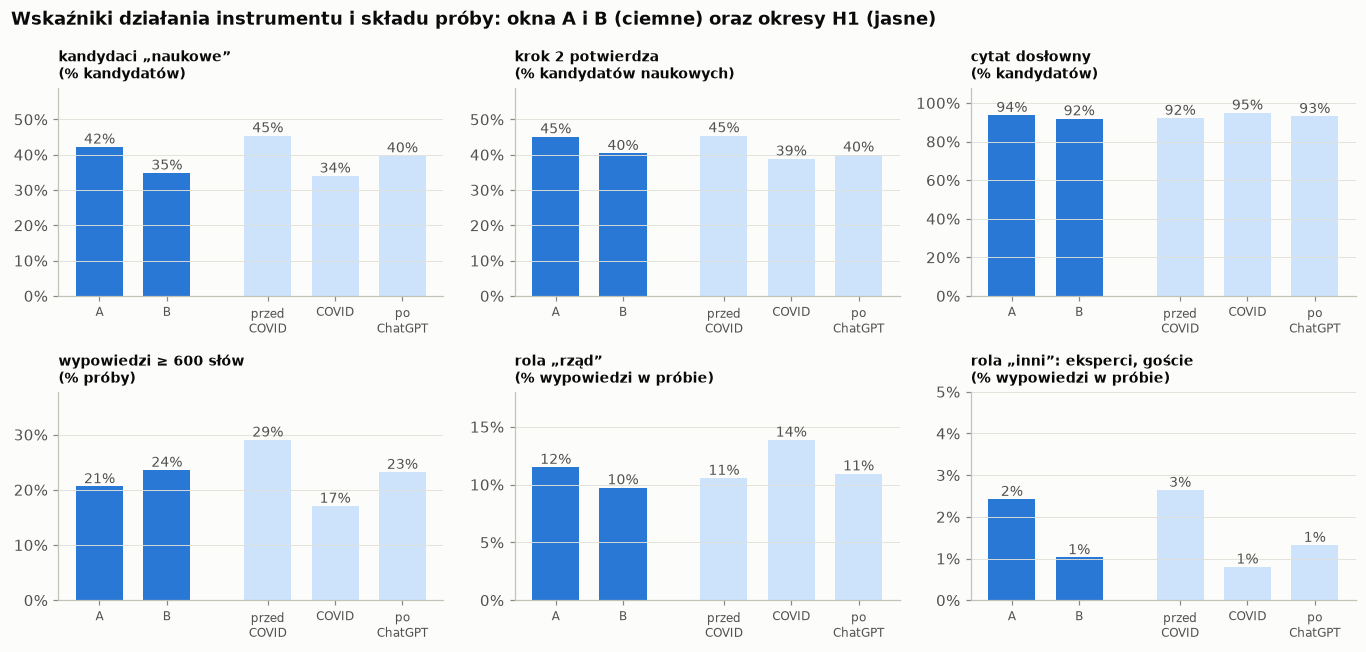

,okno A,okno B,przed COVID,COVID,po ChatGPT
kandydaci „naukowe”\n(% kandydatów),42.2,34.8,45.4,34.0,39.7
krok 2 potwierdza\n(% kandydatów naukowych),45.1,40.4,45.4,38.8,40.0
cytat dosłowny\n(% kandydatów),93.7,91.9,92.1,94.8,93.1
wypowiedzi ≥ 600 słów\n(% próby),20.6,23.6,29.0,17.1,23.2
rola „rząd”\n(% wypowiedzi w próbie),11.5,9.7,10.6,13.9,10.9
"rola „inni”: eksperci, goście\n(% wypowiedzi w próbie)",2.4,1.0,2.6,0.8,1.3


In [52]:
df["dluga"] = df["liczba_slow"] >= 600


def indicators(by, order):
    return pd.DataFrame({
        "kandydaci „naukowe”\n(% kandydatów)": cand["rodzaj"].eq("naukowe").groupby(cand[by]).mean(),
        "krok 2 potwierdza\n(% kandydatów naukowych)": nauk.groupby(by)["weryfikacja"].mean(),
        "cytat dosłowny\n(% kandydatów)": cand.groupby(by)["cytat_doslowny"].mean(),
        "wypowiedzi ≥ 600 słów\n(% próby)": df.groupby(by)["dluga"].mean(),
        "rola „rząd”\n(% wypowiedzi w próbie)": df["rola"].eq("rząd").groupby(df[by]).mean(),
        "rola „inni”: eksperci, goście\n(% wypowiedzi w próbie)": df["rola"].eq("inni").groupby(df[by]).mean(),
    }).loc[order]


ind = pd.concat([indicators("okno", list(WINDOWS)).rename(index=lambda k: f"okno {k}"),
                 indicators("okres", PERIODS).rename(index=PERIOD_LABEL)])
xs = [0, 1, 2.5, 3.5, 4.5]
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6))
for ax, col in zip(axes.flat, ind.columns):
    v = ind[col]
    ax.bar(xs, v, color=[ACCENT, ACCENT] + [ACCENT_LIGHT] * 3, width=0.7)
    for x, val in zip(xs, v):
        ax.text(x, val, f"{val:.0%}", ha="center", va="bottom", fontsize=9, color=INK2)
    ax.set_xticks(xs, ["A", "B", "przed\nCOVID", "COVID", "po\nChatGPT"], fontsize=8)
    ax.set_ylim(0, min(max(v.max() * 1.3, 0.05), 1.08)); ax.yaxis.set_major_formatter(PCT)
    ax.set_title(col, fontsize=9, loc="left", pad=6, fontweight="bold")
    ax.grid(axis="x", visible=False)
fig.suptitle("Wskaźniki działania instrumentu i składu próby: okna A i B (ciemne) oraz okresy H1 (jasne)", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "llm_p_20_bledy_okresy"); plt.show()
ind.mul(100).round(1).T

* Wskaźniki instrumentu różnią się między okresami o kilka punktów: odsetek kandydatów „naukowe” 45% / 34% / 40% (okna 42% i 35%),
  potwierdzenia w kroku 2 45% / 39% / 40% (okna 45% i 40%). Wierność cytatów jest wszędzie podobna (92–95%).
* Skład próby jest stabilny: rząd 10–14%, „inni” 1–3%. Zmienia się udział długich wypowiedzi (≥ 600 słów): 29% przed COVID, 17%
  w okresie COVID, 21–24% w oknach.
* Różnice instrumentu między oknami nie są zerowe. Niższy odsetek kandydatów „naukowe” w B może oznaczać
  inny charakter wypowiedzi albo inne działanie modelu; bez ręcznej anotacji tego nie rozstrzygniemy.

### 9.8 Podsumowanie źródeł błędu

| # | problem | dowód (ten notatnik) | kierunek | różny w okresach i oknach? | stan |
|---|---|---|---|---|---|
| 1 | przepełnienie kontekstu | 0 przypadków; maks. 15,0 tys. z 16 384 tokenów | – | – | kontrolowane automatycznie (`llm.overflow`) |
| 2 | ucięcie wypowiedzi > 2500 słów | 26 wyp. (1,8%) | zaniża w najdłuższych | nieznany | otwarte (np. dzielenie na fragmenty) |
| 3 | limit 16 kandydatów | 9 wyp. z pełnym limitem; 3% twierdzeń z pozycji 9–16 | lekko zaniża | nie | zaakceptowane |
| 4 | krok 1: rodzaj „naukowe” | 41% kandydatów; 45% / 34% / 40% w okresach | oba kierunki | **tak**: okna 42% / 35% | otwarte: ręczna anotacja |
| 5 | krok 2 myli się w obie strony | 57% kandydatów „naukowe” odrzuconych; trafne i błędne odrzucenia (9.3) | oba kierunki | tak: 45% / 39% / 40%; okna 45% / 40% | otwarte: ręczna anotacja |
| 6 | granica naukowe / statystyka / prawo | 9.5 | oba kierunki | nieznany | otwarte |
| 7 | etykieta tematu | `energia_jadrowa`: 12% o atomie; klimat dla chorób krążenia i ASF; odra jako COVID | analiza per temat | tak (zależy od debat) | otwarte |
| 8 | atrybucja: polemika jako twierdzenie własne | 3 polemiki na 614; „mitologia” CO2 jako `wlasne` (5.5) | odwraca stanowisko mówcy w etapie B | nieznany | otwarte |
| 9 | przeciek przykładu z promptu | 1 na 3 477 kandydatów | zawyża | nie | otwarte: odrzucać cytaty nieobecne w tekście |
| 10 | zmienność przebiegu (uruchomienie, karta) | niezmierzona w tym przebiegu (9.4) | szum | nieznany | otwarte: test–retest |
| 11 | **populacja = filtr regex** | słownik COVID wnosi 61% populacji okresu COVID; bez tych wypowiedzi spadek COVID znika (5.2) | zmienia wnioski o czasie | **tak** | otwarte: definicja populacji |
| 12 | skupienie w mówcach i debatach | 10 mówców = 23% twierdzeń; jedna wypowiedź = 14 z 60 twierdzeń okna A | zaniża błędy standardowe | tak | otwarte: klastrowanie po mówcy lub dniu |
| 13 | blok a czas | Konfederacja i Lewica prawie bez wypowiedzi przed COVID (6.2) | przesuwa porównania bloków | tak | otwarte: porównania w tym samym okresie |
| 14 | wielkość próby | 130 / rok; w oknach 165 i 195 wyp., przedział różnicy ok. ±8 pp | szum | nie | częściowo poprawione |
| 15 | brak danych odniesienia; jeden model i prompt | – | nieznany | nieznany | ręczna anotacja (rozważana) |

Dla porównań w czasie najważniejsze są błędy różnicowe (4, 5, 11, 12): mogą same wytworzyć różnicę między okresami albo ją ukryć.
Największy wpływ ma tu definicja populacji (11), a nie sam model.

## 10. Dalszy plan

### 10.1 Co z tej próby wynika dla pomiaru

* **Okna A i B nie różnią się** udziałem wypowiedzi z twierdzeniem naukowym (−1,2 pp [−9,3; +6,4]); przedział różnicy ma ok. ±8 pp. Ewentualna różnica w sprzeczności z konsensusem nie będzie więc wynikać z tego, że w jednym
  oknie w ogóle pada więcej twierdzeń naukowych.
* **Zmiana w czasie jest w 2020 r.**, ale jej część to efekt mianownika (słownik COVID). Spadek po ChatGPT względem okresu przed
  COVID zostaje po usunięciu tego efektu (5.2).
* **Skład ról** na posiedzeniach plenarnych jest stabilny (rząd 10–14%, „inni” 1–3% w okresach). Blok posła jest za to
  powiązany z czasem (6.2).
* Nowe problemy do rozważenia: atrybucja polemiki (8, 5.5) i przeciek przykładów z promptu (9.6).

### 10.2 Model i czas

Bielik 11B na RTX 5060 Ti potrzebuje średnio 13,4 s na wypowiedź plenarną, ok. dwa razy mniej niż na RTX 3060. Pełny przebieg
na całej populacji filtra w oknach (plenarne) to ok. 14 h, czyli jedna noc pracy karty. Wtedy porównanie okien nie miałoby błędu
losowania (zostaje błąd instrumentu). Cały filtr plenarny 2015–2026 to ok. 46 h.

### 10.3 Jak mierzymy zjawisko

Schemat: populacja → etap A → etap B (werdykt względem źródeł, bez polegania na wiedzy LLM-a) → agregacja
twierdzenie → wypowiedź → okno, z uwzględnieniem błędu klasyfikatora. Z tej próby wynikają dodatkowe punkty do rozważenia:

* **Mianownik.** Populacja zdefiniowana filtrem regex zmienia się w czasie razem z tematami dnia (COVID). Do rozważenia: populacja
  bez słownika COVID, osobne mianowniki dla tematów albo wszystkie wypowiedzi merytoryczne.
* **Skupienie.** Twierdzenia skupiają się w mówcach i debatach (9.8, pkt 12), więc testy wymagają klastrowania.
* **Bloki.** Porównania bloków (np. prawica w rządzie i w opozycji) trzeba robić w tym samym okresie albo z kontrolą okresu.
* **Atrybucja.** Etap B musi wiedzieć, czy mówca twierdzi, czy polemizuje; obecny krok 1 polemikę rozpoznaje rzadko.
* **Istotność:** z uwzględnieniem niepewności klasyfikatora (np. korekta Rogana–Gladena z bootstrapem albo prediction-powered
  inference, Angelopoulos i in., 2023). Obie metody wymagają ręcznie oznaczonej próby.

### 10.4 Ręczna anotacja (rozważana)

Rozważamy ręczne oznaczenie części wypowiedzi, żeby oszacować błąd instrumentu, osobno w oknach. Z tej próby
dochodzą do sprawdzenia atrybucja polemiki i etykiety tematów.

### 10.5 Wykonalność

In [53]:
sec = df["sekundy"].mean()
komisje = corpus.load("komisje")
n_kom = int((komisje["merytoryczna"] & sampling.prefilter(komisje)).sum())
display(pd.Series({
    "średni czas Bielika w tym przebiegu [s / wypowiedź]": round(sec, 1),
    f"okna A i B, filtr regex, plenarne ({len(wf):,} wyp.) [h]": round(len(wf) * sec / 3600, 1),
    f"cały filtr regex, plenarne ({len(filt):,} wyp.) [h]": round(len(filt) * sec / 3600, 1),
    f"filtr regex, komisje ({n_kom:,} wyp.; wypowiedzi dłuższe, czas zaniżony) [h]": round(n_kom * sec / 3600, 1),
    f"wszystkie merytoryczne plenarne ({len(mer):,} wyp.; krótsze, czas zawyżony) [h]": round(len(mer) * sec / 3600),
}).to_frame("wartość"))
est_claims = pd.concat([totals(dw, "okno", "n_twierdzen").loc[list(WINDOWS)].rename(index=lambda k: f"okno {k}"),
                        totals(df, "okres", "n_twierdzen").loc[PERIODS].rename(index=PERIOD_LABEL)])
est_claims.round().astype(int).to_frame("szac. twierdzenia naukowe w populacji filtra (plenarne)")

,wartość
średni czas Bielika w tym przebiegu [s / wypowiedź],13.4
"okna A i B, filtr regex, plenarne (3,676 wyp.) [h]",13.7
"cały filtr regex, plenarne (12,343 wyp.) [h]",46.0
"filtr regex, komisje (7,074 wyp.; wypowiedzi dłuższe, czas zaniżony) [h]",26.4
"wszystkie merytoryczne plenarne (129,768 wyp.; krótsze, czas zawyżony) [h]",484.0


,szac. twierdzenia naukowe w populacji filtra (plenarne)
okno A,581
okno B,612
przed COVID,1368
COVID,1278
po ChatGPT,1593


In [54]:
z_a, z_b = NormalDist().inv_cdf(0.975), NormalDist().inv_cdf(0.8)


def n_per_group(p0, d):
    p1 = p0 + d
    pb = (p0 + p1) / 2
    return int(np.ceil((z_a * np.sqrt(2 * pb * (1 - pb)) + z_b * np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))) ** 2 / d ** 2))


power = pd.DataFrame({f"wzrost o {d * 100:.0f} pp": [n_per_group(p0, d) for p0 in (0.05, 0.10, 0.20)] for d in (0.03, 0.05, 0.10)},
                     index=pd.Index(["5%", "10%", "20%"], name="odsetek fałszywych w okresie odniesienia"))
display(Markdown("**Liczba twierdzeń ocenionych w etapie B potrzebna w każdym okresie lub oknie** (test dwóch proporcji, α = 0,05, moc 80%, "
                 "bez błędu klasyfikatora i bez skupienia w mówcach)"))
power

**Liczba twierdzeń ocenionych w etapie B potrzebna w każdym okresie lub oknie** (test dwóch proporcji, α = 0,05, moc 80%, bez błędu klasyfikatora i bez skupienia w mówcach)

,wzrost o 3 pp,wzrost o 5 pp,wzrost o 10 pp
odsetek fałszywych w okresie odniesienia,,,
5%,1059,435,141
10%,1774,686,199
20%,2943,1094,294


In [55]:
p_w = R.weighted_share(dw, "okno")
k_list = [30, 50, 100, 200]
gold = pd.DataFrame({f"okno {k}: wypowiedzi do oznaczenia": [int(np.ceil(kk / p_w[k])) for kk in k_list] for k in WINDOWS},
                    index=pd.Index(k_list, name="wypowiedzi z twierdzeniem w oznaczonej próbie"))
gold["± połowa 95% CI dla czułości 0,8 [pp]"] = [round(100 * 1.96 * np.sqrt(0.8 * 0.2 / kk), 1) for kk in k_list]
display(Markdown(f"**Ile wypowiedzi plenarnych z filtra trzeba oznaczyć ręcznie w każdym oknie** (scenariusz: odsetek wypowiedzi "
                 f"z twierdzeniem jak w tej próbie, A {p_w['A']:.0%}, B {p_w['B']:.0%}; losowanie proste w oknie)"))
gold

**Ile wypowiedzi plenarnych z filtra trzeba oznaczyć ręcznie w każdym oknie** (scenariusz: odsetek wypowiedzi z twierdzeniem jak w tej próbie, A 16%, B 15%; losowanie proste w oknie)

,okno A: wypowiedzi do oznaczenia,okno B: wypowiedzi do oznaczenia,"± połowa 95% CI dla czułości 0,8 [pp]"
wypowiedzi z twierdzeniem w oznaczonej próbie,,,
30,183,197,14.3
50,305,329,11.1
100,609,657,7.8
200,1217,1314,5.5


* Przy 13,4 s na wypowiedź cała populacja filtra w oknach (plenarne, 3 676 wypowiedzi) to ok. 14 h, cały filtr plenarny ok. 46 h.
  Komisje i wszystkie wypowiedzi merytoryczne to szacunki z dużą niepewnością, bo długość wypowiedzi jest tam inna.
* W populacji filtra jest szacunkowo ok. 580 twierdzeń naukowych w oknie A i 610 w B. Jeśli w okresie odniesienia 10% twierdzeń
  jest fałszywych, wykrycie wzrostu o 5 pp wymaga ok. 690 ocenionych twierdzeń w każdym oknie, czyli prawie wszystkich twierdzeń
  z populacji; dla jednego tematu (np. klimatu, ok. 100 wypowiedzi w B) dużo za mało. Błąd klasyfikatora i skupienie w mówcach
  zwiększą te liczby.
* Ręczna anotacja: przy udziale jak w tej próbie (16% w A, 15% w B) zebranie 100 wypowiedzi z twierdzeniem wymaga przejrzenia
  ok. 610 wypowiedzi z A i 660 z B. Losowanie z nadreprezentacją wypowiedzi wskazanych przez model zmniejszy te liczby.

## 11. Podsumowanie

**Co wiemy po tej próbie (posiedzenia plenarne, 1 473 wypowiedzi, 130 na rok)**

1. **Okna A i B.** Twierdzenie naukowe ma 16,4% wypowiedzi z filtra w A i 15,2% w B (różnica −1,2 pp [−9,3; +6,4]), w populacji
   filtra to szacunkowo ok. 280 i 300 wypowiedzi z twierdzeniem i ok. 580 i 610 twierdzeń. U posłów PiS i Konfederacji udział rośnie
   z 9% do 13%, ale przedział różnicy obejmuje zero. Klimat w B to rząd 90–100 wypowiedzi z twierdzeniem w populacji.
2. **Czas.** Udział spada z ok. 30% przed 2020 r. do 14–15% później, ale w okresie COVID to głównie efekt mianownika: 61% populacji
   filtra wchodzi do niej tylko przez słownik COVID, a bez tych wypowiedzi spadku prawie nie ma. Spadek po ChatGPT względem okresu
   przed COVID zostaje (−11 pp). Liczba twierdzeń w populacji po 2020 r. nie spada.
3. **ChatGPT.** Przed i po 30.11.2022 udział różni się o −3,7 pp [−8,0; +0,6]; wewnątrz okna A różnicy nie ma.
4. **Kto mówi.** Posłowie i rząd formułują twierdzenia równie często. Różnice między blokami w dużej części wynikają z tego,
   w których latach dany klub był w Sejmie.
5. **Tematy.** Najwięcej twierdzeń dotyczy klimatu i smogu. Wzmianka to nie twierdzenie: tylko 5% wzmianek o COVID zawiera
   twierdzenie o COVID. Etykiety `energia_jadrowa` i `klimat` są używane szerzej niż nazwa tematu.
6. **Instrument.** Przebieg bez błędów i przepełnień. Problemy:
   krok 2 myli się w obie strony, polemika bywa zapisana jako twierdzenie własne, zdarza się przeciek przykładu z promptu.
7. To pomiar etapu A. O sprzeczności wypowiedzi z konsensusem ten notatnik nic nie mówi; widać tylko pojedyncze twierdzenia, które
   etap B mógłby tak ocenić.

**Ograniczenia**

* Brak ręcznie oznaczonych danych odniesienia: precyzja i czułość instrumentu są nieznane i mogą się różnić między okresami
  i oknami.
* Tylko posiedzenia plenarne (bez komisji).
* Populacja ograniczona do wypowiedzi z trafieniem słowników; jej skład zależy od tematów dnia (COVID), a twierdzenia poza filtrem
  są poza pomiarem.
* Próba była losowana po latach, nie po oknach; w oknach jest 165 i 195 wypowiedzi.
* Jeden model i jeden prompt kroku 1, strojony na 20 wypowiedziach (część przykładów w prompcie pochodzi z nich).
* Parafrazę twierdzenia generuje LLM i może ona przesunąć sens wypowiedzi; cytat źródłowy jest zachowany do kontroli.
* Rok 2026 obejmuje dane do dnia pobrania korpusu; okresy H1 mają różną długość.